## Данные

Используются изображения:

    /content/train_images
    /content/test_images

Разметка загружается из файла:

    /content/drive/MyDrive/YAN/train_solution.csv

Train/validation split:

    test_size = 0.2
    stratify = labels
    random_state = 42

Финальный submission сохраняется в формате:

    id,target_feature

---

## Используемые модели

В ноутбуке подключаются несколько разных архитектур.

### 1. ConvNeXt-Tiny-подобная модель

Кастомная сверточная модель с ConvNeXt-блоками.

Схема:

    Input [B, 3, 224, 224]
            |
            v
    Conv Stem
    Conv2d kernel=4 stride=4
            |
            v
    Stage 1: ConvNeXt Block x 3, dim=96
            |
            v
    Stage 2: ConvNeXt Block x 3, dim=192
            |
            v
    Stage 3: ConvNeXt Block x 9, dim=384
            |
            v
    Stage 4: ConvNeXt Block x 3, dim=768
            |
            v
    Global Average Pooling
            |
            v
    LayerNorm
            |
            v
    Linear 768 -> 256
    GELU
    Dropout
    Linear 256 -> 1
            |
            v
    Output logit

---

### 2. EfficientNet-B3-подобная модель

Используется ручная EfficientNet-B3-подобная архитектура.

Основные блоки:

    MBConv
    Depthwise convolution
    Squeeze-and-Excitation
    BatchNorm
    SiLU
    Stochastic depth
    Linear head

Модель возвращает один logit.  
Вероятность класса `fake` считается через `sigmoid`.

В ноутбуке используется обычный checkpoint и EMA-checkpoint.

---

### 3. DualStreamNetV2 / IMBA

Двухпоточная модель:

    RGB stream
    FFT stream

Схема:

    RGB image
        |
        v
    Spatial CNN branch

    FFT image
        |
        v
    Frequency CNN branch

    Spatial features + Frequency features
        |
        v
    CrossFusion blocks
        |
        v
    CBAM attention
        |
        v
    AdaptiveAvgPool2d
        |
        v
    Concatenation
        |
        v
    MLP classifier
        |
        v
    Output logit

FFT-признаки считаются через:

    torch.fft.fft2
    torch.fft.fftshift
    log1p(abs(fft))

---

### 4. DeepFakeDetector / TTA-модель

Модель состоит из двух веток:

    RGB branch
    FFT branch

RGB branch обрабатывает исходное изображение.  
FFT branch обрабатывает частотное представление изображения.

После этого признаки объединяются и проходят через классификатор:

    RGB features + FFT features
            |
            v
    Linear
    ReLU
    Dropout
    Linear
            |
            v
    Output logit

---

### 5. RegNet-Y-16GF-подобная модель

Сверточная модель с bottleneck-блоками.

Основные элементы:

    Conv stem
    ResBottleneckBlock
    Grouped convolution
    Squeeze-and-Excitation
    AdaptiveAvgPool2d
    Linear classifier

В отличие от большинства остальных моделей, RegNet возвращает два logits:

    [real_logit, fake_logit]

Вероятность класса `fake` считается через softmax.

---

### 6. IR-CFA-CCNet v4

Forensic-модель для анализа локальных следов изображения.

Основные элементы:

    CFA/residual признаки
    ConvGNAct blocks
    DSConvGNAct blocks
    ImpulseGate
    ForensicBlock
    SignedGeM pooling
    Linear head

Модель работает с изображениями размером `256x256`.

---

### 7. RobustSRMTopKMILNetV2

Модель совмещает глобальный RGB-анализ и локальный анализ патчей через SRM-фильтры.

Схема:

    Input image [B, 3, 256, 256]
            |
            v
    Global RGB branch
            |
            v
    global feature

    Input image [B, 3, 256, 256]
            |
            v
    SRM filters
            |
            v
    Local patch branch
            |
            v
    Top-K MIL pooling
            |
            v
    local feature

    global feature + local feature
            |
            v
    Final classifier
            |
            v
    Output logit

Используется checkpoint `RobustSRMTopKMILNetV2_EMA_BEST.pth`.

---

## Аугментации и обработка

Для разных моделей используются свои transforms.

### ConvNeXt

Train:

    RandomResizedCrop 224x224
    HorizontalFlip
    ShiftScaleRotate
    MedianBlur или ImageCompression
    RandomBrightnessContrast
    HueSaturationValue
    Normalize ImageNet mean/std
    ToTensorV2

Validation/Test:

    Resize 224x224
    Normalize ImageNet mean/std
    ToTensorV2

---

### EfficientNet-B3

Train:

    RandomResizedCrop 256x256
    HorizontalFlip
    ShiftScaleRotate
    Downscale или ImageCompression
    GaussianBlur или MedianBlur
    RandomBrightnessContrast
    RandomGamma
    CLAHE
    ToGray
    ISONoise или MultiplicativeNoise
    CoarseDropout
    Normalize ImageNet mean/std
    ToTensorV2

Validation/Test:

    Resize 288x288
    CenterCrop 256x256
    Normalize ImageNet mean/std
    ToTensorV2

---

### DualStreamNetV2 / IMBA

Обработка RGB:

    ToTensor
    Normalize mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]

Дополнительно строится FFT-представление изображения:

    fft2
    fftshift
    abs
    log1p
    normalization by saved fft mean/std

---

### DeepFakeDetector / TTA

Обработка:

    Resize 256x256
    ToTensor
    Normalize mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]

---

### RegNet

Validation/Test:

    Resize 224x224
    Normalize ImageNet mean/std
    ToTensorV2

---

### RobustSRMTopKMILNetV2

Train:

    Resize 256x256
    RandomHorizontalFlip
    RandomApply ColorJitter
    ToTensor
    Normalize mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]

Validation/Test:

    Resize 256x256
    ToTensor
    Normalize mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]

---

## Схема ансамбля

Для каждой модели собираются prediction probabilities на validation и test.

Общая схема:

    model_1 -> validation probabilities
    model_2 -> validation probabilities
    model_3 -> validation probabilities
    ...
            |
            v
    common validation ids
            |
            v
    подбор весов ансамбля и threshold по F1
            |
            v
    model_1 -> test probabilities
    model_2 -> test probabilities
    model_3 -> test probabilities
    ...
            |
            v
    weighted logit blending
            |
            v
    sigmoid
            |
            v
    threshold
            |
            v
    submission.csv

---

## Формула ансамбля

Сначала вероятности каждой модели переводятся в logits:

    logit_i = log(p_i / (1 - p_i))

Затем logits усредняются с весами:

    final_logit = w1 * logit_1 + w2 * logit_2 + ... + wn * logit_n

После этого итоговая вероятность считается через sigmoid:

    final_prob = sigmoid(final_logit)

Финальный класс определяется через threshold:

    pred = final_prob > threshold

---

## Подбор весов

В ноутбуке реализованы классы ансамблей:

    TwoModelEnsembler
    ThreeModelEnsembler
    FourModelEnsembler
    FiveModelEnsembler

Для каждого ансамбля:

    1. Собираются validation probabilities выбранных моделей
    2. Берутся только общие id между моделями
    3. Выполняется grid search по весам
    4. Подбирается threshold по максимальному F1
    5. Эти веса и threshold применяются к test probabilities
    6. Сохраняется submission

Для ускорения повторных запусков предсказания отдельных моделей кэшируются в директории:

    /content/drive/MyDrive/YAN/ensemble_prob_cache

---

## Финальные варианты ансамблей

В ноутбуке запускаются разные комбинации моделей:

    efficientnet + robust_v2
    efficientnet + imba
    imba + robust_v2
    regnet + efficientnet
    tta + efficientnet
    tta + convnext

    imba + efficientnet + robust_v2
    tta + efficientnet + robust_v2

    ir_cfa_ccnet_v4 + efficientnet_ema + imba + robust_v2
    regnet + efficientnet + imba + robust_v2
    convnext + efficientnet + imba + regnet

    imba + efficientnet + robust_v2 + tta + ir_cfa_ccnet_v4

Финальный 5-model submission сохраняется как:

    /content/drive/MyDrive/YAN/all5_ensemble.csv

In [ ]:
import glob
import os
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import OrderedDict
from typing import Optional, Sequence
import math
import albumentations as A
from albumentations.pytorch import ToTensorV2
from IPython.display import clear_output
import torch.nn.functional as F
import seaborn as sns

In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

In [ ]:
import warnings

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset

class TrainDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]["id"]
        label = self.df.iloc[idx]["label"]

        img_path = os.path.join(self.root_dir, f"{img_id}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = np.array(image)
            image = self.transform(image=image)["image"]

        return image, label

In [ ]:
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.files = os.listdir(root_dir)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        path = os.path.join(self.root_dir, file_name)

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = np.array(image)
            image = self.transform(image=image)["image"]

        return image, file_name

In [ ]:
!pip install -U albumentations==1.4.1

# Обработка данных

In [ ]:
train_transforms_convnext = A.Compose([
    A.RandomResizedCrop(224, 224, scale=(0.85, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.08,
        rotate_limit=5,
        p=0.3
    ),

    A.OneOf([
        A.MedianBlur(blur_limit=3, p=1.0),
        A.ImageCompression(quality_lower=70, quality_upper=100, p=1.0),
    ], p=0.3),

    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.2),

    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transforms_convnext = A.Compose([
    A.Resize(224, 224, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [ ]:
train_transforms_convnext = A.Compose([
    A.RandomResizedCrop(224, 224, scale=(0.85, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.08,
        rotate_limit=5,
        p=0.3
    ),

    A.OneOf([
        A.MedianBlur(blur_limit=3, p=1.0),
        A.ImageCompression(quality_lower=70, quality_upper=100, p=1.0),
    ], p=0.3),

    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.2),

    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transforms_convnext = A.Compose([
    A.Resize(224, 224, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [ ]:
labels_for_train = pd.read_csv("/content/drive/MyDrive/YAN/train_solution.csv", header=None)
labels_for_train.columns = ["id", "label"]
train_df, val_df = train_test_split(
    labels_for_train,
    test_size=0.2,
    stratify=labels_for_train["label"],
    random_state=42
)

In [ ]:
!unzip -q /content/drive/MyDrive/YAN/train_images.zip -d /content/

In [ ]:
print(os.listdir("/content"))

['.config', 'train_images', 'drive', 'sample_data']


In [ ]:
print(len(os.listdir("/content/train_images")))

50000


In [ ]:
!unzip -q /content/drive/MyDrive/YAN/train_images.zip -d /content/

In [ ]:
train_dataset = TrainDataset(train_df, "/content/train_images", transform=train_transforms_convnext)
val_dataset   = TrainDataset(val_df,   "/content/train_images", transform=val_transforms_convnext)
test_dataset  = TestDataset("/content/test_images", transform=val_transforms_convnext)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)

# Модель ConvNeXt-Tiny

In [ ]:
def drop_path(x, drop_prob: float = 0., training: bool = False):
    if drop_prob == 0. or not training:
        return x
    keep_prob = 1 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()
    output = x.div(keep_prob) * random_tensor
    return output

class DropPath(nn.Module):
    def __init__(self, drop_prob=None):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)

class LayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-6, data_format="channels_last"):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.data_format = data_format
        if self.data_format not in ["channels_last", "channels_first"]:
            raise NotImplementedError
        self.normalized_shape = (normalized_shape, )
    def forward(self, x):
        if self.data_format == "channels_last":
            return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        elif self.data_format == "channels_first":
            u = x.mean(1, keepdim=True)
            s = (x - u).pow(2).mean(1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            x = self.weight[:, None, None] * x + self.bias[:, None, None]
            return x

class Block(nn.Module):
    def __init__(self, dim, drop_path=0., layer_scale_init_value=1e-6):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.norm = LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim)
        self.act = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.gamma = nn.Parameter(layer_scale_init_value * torch.ones((dim)),
                                    requires_grad=True) if layer_scale_init_value > 0 else None
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()

    def forward(self, x):
        input = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        if self.gamma is not None: x = self.gamma * x
        x = x.permute(0, 3, 1, 2)
        x = input + self.drop_path(x)
        return x

class ConvNeXt(nn.Module):
    def __init__(self, in_chans=3, num_classes=1,
                 depths=[3, 3, 9, 3], dims=[96, 192, 384, 768], drop_path_rate=0.15,
                 layer_scale_init_value=1e-5):
        super().__init__()

        self.downsample_layers = nn.ModuleList()
        stem = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=4, stride=4),
            LayerNorm(dims[0], eps=1e-6, data_format="channels_first")
        )
        self.downsample_layers.append(stem)
        for i in range(3):
            downsample_layer = nn.Sequential(
                    LayerNorm(dims[i], eps=1e-6, data_format="channels_first"),
                    nn.Conv2d(dims[i], dims[i+1], kernel_size=2, stride=2),
            )
            self.downsample_layers.append(downsample_layer)

        self.stages = nn.ModuleList()
        dp_rates=[x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]
        cur = 0
        for i in range(4):
            stage = nn.Sequential(
                *[Block(dim=dims[i], drop_path=dp_rates[cur + j],
                layer_scale_init_value=layer_scale_init_value) for j in range(depths[i])]
            )
            self.stages.append(stage)
            cur += depths[i]

        self.final_norm = nn.LayerNorm(dims[-1], eps=1e-6)

        self.head = nn.Sequential(
            nn.Linear(dims[-1], 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            nn.init.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Conv2d) and m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward_features(self, x):
        for i in range(4):
            x = self.downsample_layers[i](x)
            x = self.stages[i](x)
        x = x.mean([-2, -1])
        x = self.final_norm(x)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x.squeeze(-1)

def convnext_tiny_ultimate():
    return ConvNeXt(depths=[3, 3, 9, 3], dims=[96, 192, 384, 768], num_classes=1)

# Загрузка модели

In [ ]:
model = convnext_tiny_ultimate()
model.to(device)

num_epochs = 100  # как потолок, но лучше останавливать по val F1

# -------------------------
# LOSS
# -------------------------
n_pos = train_df["label"].sum()
n_neg = len(train_df) - n_pos

pos_weight = torch.tensor([n_neg / n_pos], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# -------------------------
# OPTIMIZER
# -------------------------
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=5e-2
)

# -------------------------
# SCHEDULER
# -------------------------
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-4,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=25.0,
    final_div_factor=1000.0
)



# Обучение модели

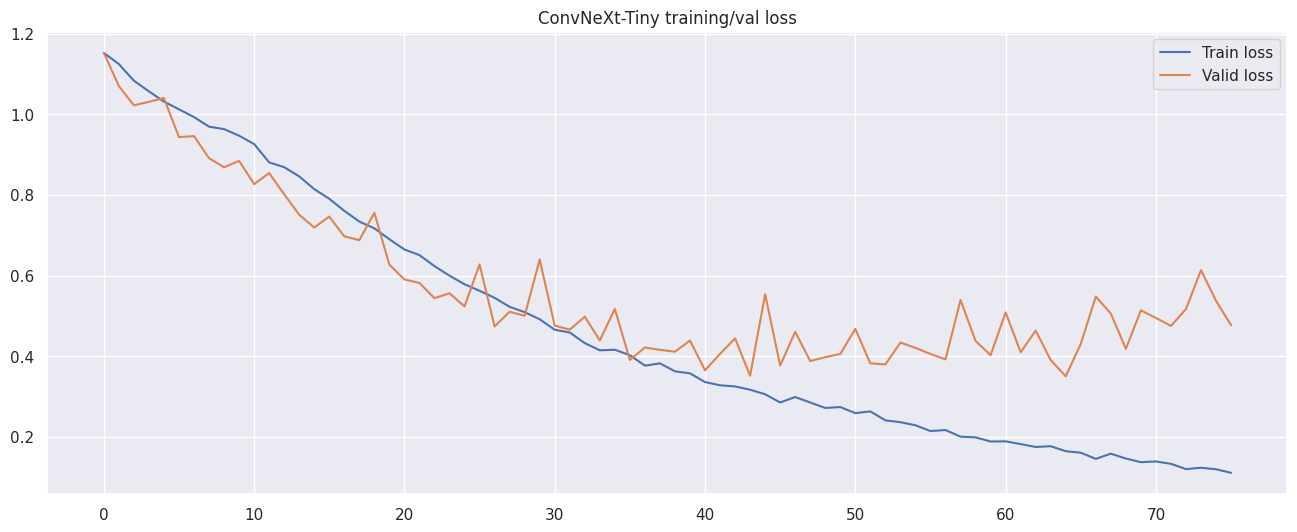

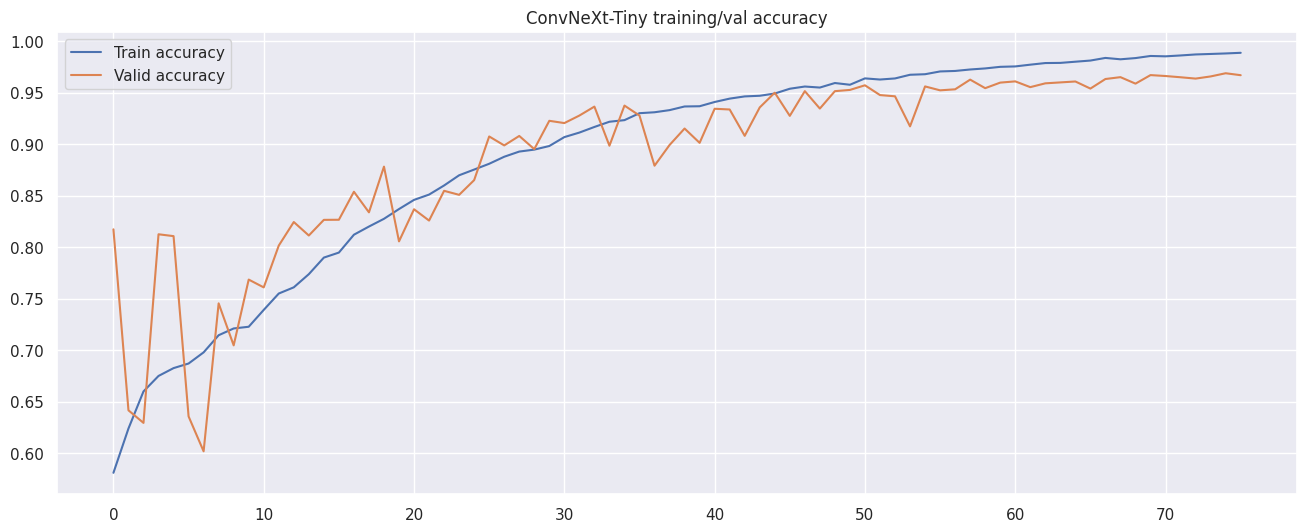

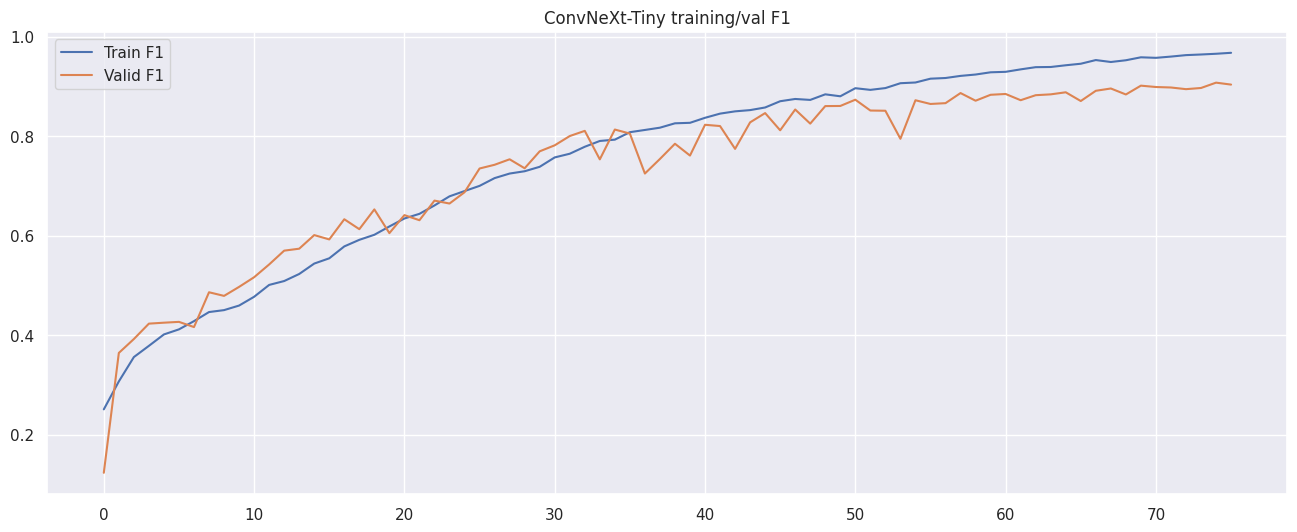

Epoch 76/100
Train loss: 0.1105 | Val loss: 0.4768
Train acc:  0.9889 | Val acc:  0.9671
Train F1:   0.9673 | Val F1:   0.9034
Best Val F1 so far: 0.9074


  0%|          | 0/1250 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
fit(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    scheduler,
    num_epochs,
    title="ConvNeXt-Tiny training/val"
)

# Дообучение

In [ ]:
train_transforms_phase2 = A.Compose([
    A.RandomResizedCrop(224, 224, scale=(0.9, 1.0), p=1.0),

    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.02,
        scale_limit=0.05,
        rotate_limit=3,
        p=0.2
    ),
    A.OneOf([
        A.MedianBlur(blur_limit=3, p=1.0),
        A.ImageCompression(quality_lower=85, quality_upper=100, p=1.0),
    ], p=0.1),

    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.2),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.1),

    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transforms_convnext = A.Compose([
    A.Resize(224, 224, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_dataset_phase2 = TrainDataset(train_df, "/content/train_images", transform=train_transforms_phase2)
val_dataset_phase2   = TrainDataset(val_df,   "/content/train_images", transform=val_transforms_convnext)

train_loader_phase2 = DataLoader(train_dataset_phase2, batch_size=32, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
val_loader_phase2   = DataLoader(val_dataset_phase2, batch_size=32, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)

from copy import deepcopy

model_ConvNeXt_Tiny_epoch_64 = convnext_tiny_ultimate().to(device)
model_ConvNeXt_Tiny_epoch_64.load_state_dict(
    torch.load("/content/drive/MyDrive/YAN/64_0.8838.pth", map_location=device)
)

ema_model = deepcopy(model_ConvNeXt_Tiny_epoch_64).to(device)
ema_model.eval()

def update_ema(model, ema_model, decay=0.999):
    with torch.no_grad():
        for ema_param, param in zip(ema_model.parameters(), model.parameters()):
            ema_param.data.mul_(decay).add_(param.data, alpha=1 - decay)

In [ ]:
def train(model: nn.Module, data_loader: DataLoader, optimizer, loss_fn, threshold=0.5, ema_model=None):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_true = []

    for x, y in tqdm(data_loader):
        x = x.to(device)
        y = y.float().to(device)

        optimizer.zero_grad()

        output = model(x).view(-1)
        loss = loss_fn(output, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        if ema_model is not None:
            update_ema(model, ema_model)

        probs = torch.sigmoid(output)
        preds = (probs >= threshold).long()

        total_loss += loss.item()
        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(y.long().detach().cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='binary', zero_division=0)
    rec = recall_score(all_true, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_true, all_preds, average='binary', zero_division=0)

    return total_loss / len(data_loader), acc, prec, rec, f1

    @torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, threshold=0.5):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_true = []

    for x, y in tqdm(data_loader):
        x = x.to(device)
        y = y.float().to(device)

        output = model(x).view(-1)
        loss = loss_fn(output, y)

        probs = torch.sigmoid(output)
        preds = (probs >= threshold).long()

        total_loss += loss.item()
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y.long().cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='binary', zero_division=0)
    rec = recall_score(all_true, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_true, all_preds, average='binary', zero_division=0)

    return total_loss / len(data_loader), acc, prec, rec, f1


from IPython.display import clear_output
import os
import torch


from IPython.display import clear_output
import os
import torch

def fit(model, ema_model, train_loader, valid_loader, optimizer, loss_fn, scheduler, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []
    train_f1_history, valid_f1_history = [], []

    best_valid_f1 = float('-inf')

    save_dir = "/content/drive/MyDrive/YAN"
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(num_epochs):
        train_loss, train_accuracy, train_prec, train_rec, train_f1 = train(
            model, train_loader, optimizer, loss_fn, ema_model=ema_model
        )

        valid_loss, valid_accuracy, valid_prec, valid_rec, valid_f1 = evaluate(
            ema_model, valid_loader, loss_fn
        )

        scheduler.step(valid_f1)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)
        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)
        train_f1_history.append(train_f1)
        valid_f1_history.append(valid_f1)

        save_path = os.path.join(save_dir, f"{epoch+1}_f1_{valid_f1:.4f}_val_{valid_loss:.4f}.pth")
        torch.save(ema_model.state_dict(), save_path)

        if valid_f1 > best_valid_f1:
            best_valid_f1 = valid_f1

        clear_output()
        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            train_f1_history, valid_f1_history,
            title
        )

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train loss: {train_loss:.4f} | Val loss: {valid_loss:.4f}")
        print(f"Train acc:  {train_accuracy:.4f} | Val acc:  {valid_accuracy:.4f}")
        print(f"Train F1:   {train_f1:.4f} | Val F1:   {valid_f1:.4f}")
        print(f"Best Val F1 so far: {best_valid_f1:.4f}")






num_epochs = 15

n_pos = train_df["label"].sum()
n_neg = len(train_df) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model_ConvNeXt_Tiny_epoch_64.parameters(),
    lr=1e-5,
    weight_decay=5e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


# EMA

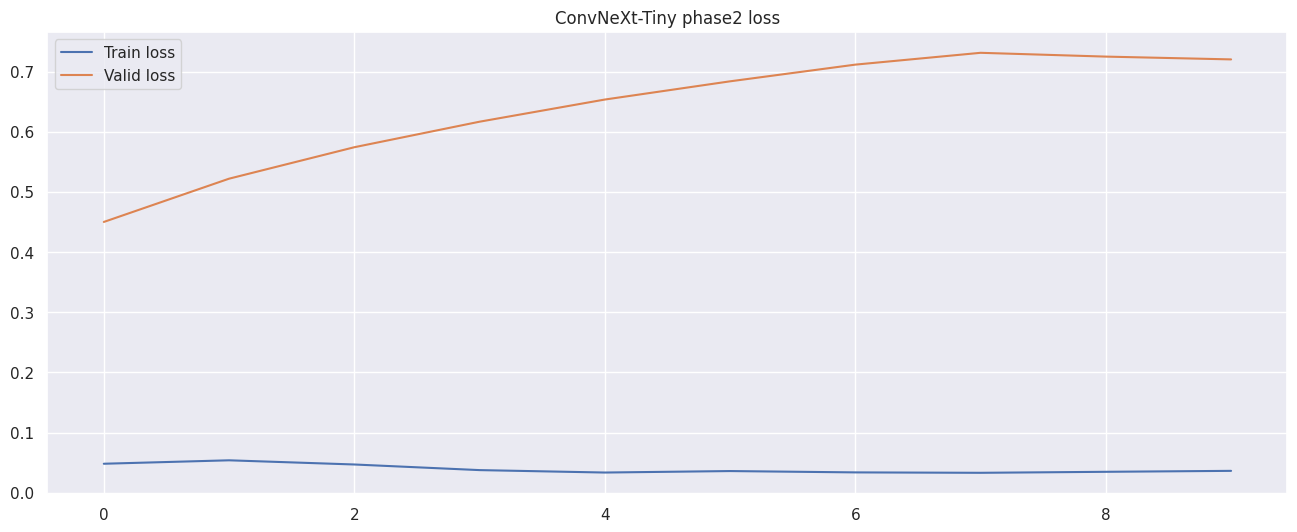

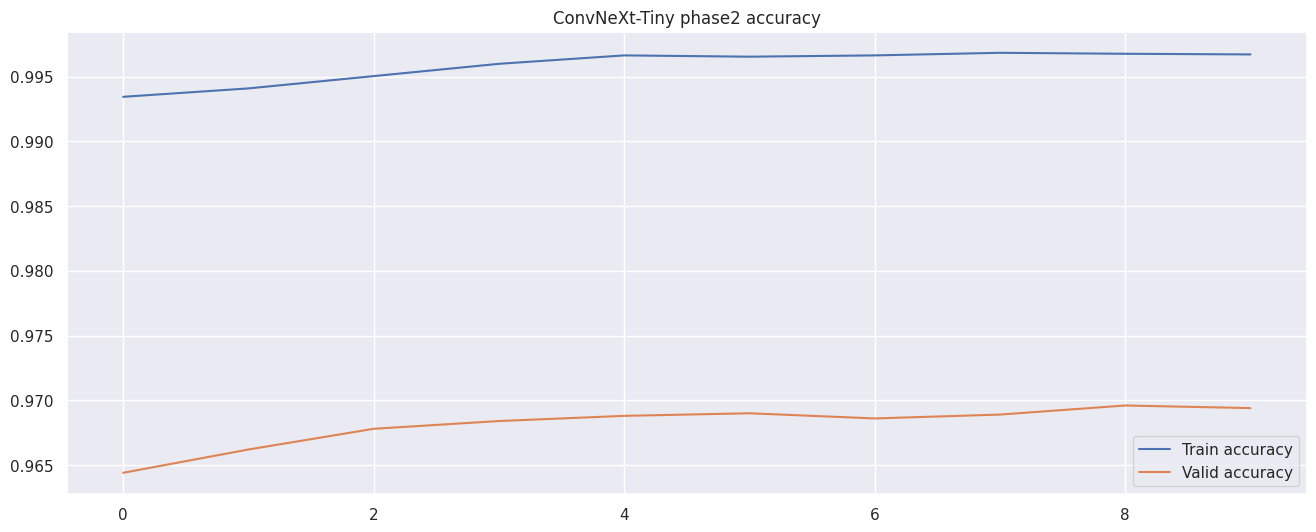

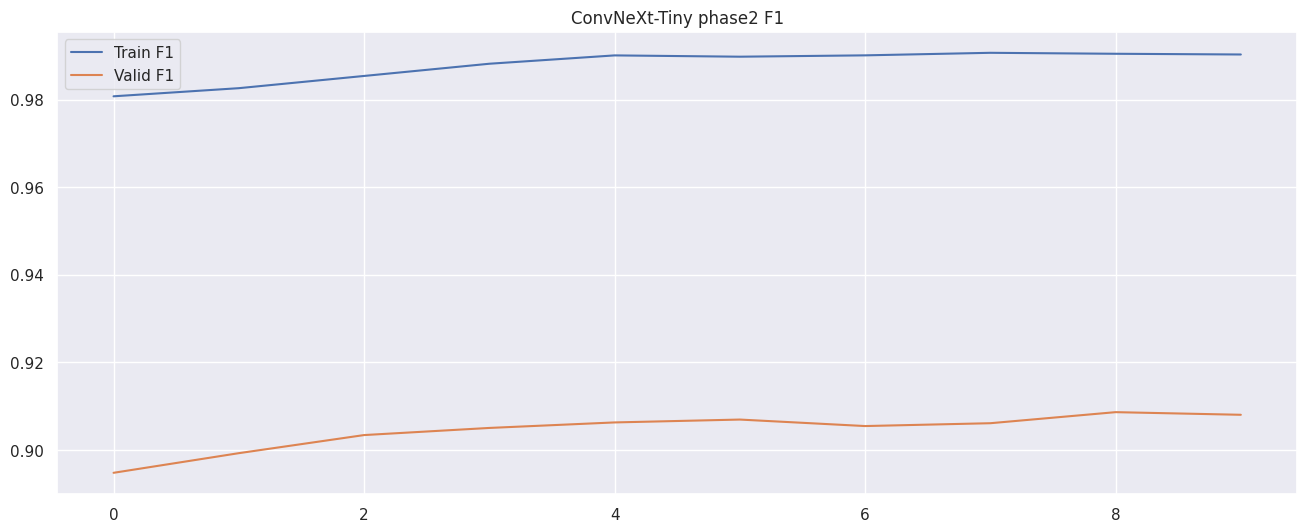

Epoch 10/15
Train loss: 0.0365 | Val loss: 0.7202
Train acc:  0.9967 | Val acc:  0.9694
Train F1:   0.9904 | Val F1:   0.9081
Best Val F1 so far: 0.9087


  0%|          | 0/1250 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
fit(
    model_ConvNeXt_Tiny_epoch_64,
    ema_model,
    train_loader_phase2,
    val_loader_phase2,
    optimizer,
    criterion,
    scheduler,
    num_epochs,
    title="ConvNeXt-Tiny phase2"
)

# Предикт 1

In [ ]:
model_ConvNeXt_predict = convnext_tiny_ultimate().to(device)
model_ConvNeXt_predict.load_state_dict(
    torch.load("/content/drive/MyDrive/YAN/6_f1_0.9070_val_0.6838.pth", map_location=device)
)

<All keys matched successfully>

# Добавление для класса ансамбля EfficientNetB3

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transforms_effb3 = A.Compose([
    A.RandomResizedCrop(
        height=256,
        width=256,
        scale=(0.70, 1.0),
        ratio=(0.90, 1.10),
        p=1.0
    ),

    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.04,
        scale_limit=0.12,
        rotate_limit=8,
        border_mode=0,
        p=0.30
    ),

    A.OneOf([
        A.Downscale(scale_min=0.65, scale_max=0.95, interpolation=0, p=1.0),
        A.Downscale(scale_min=0.65, scale_max=0.95, interpolation=3, p=1.0),
        A.Downscale(scale_min=0.65, scale_max=0.95, interpolation=1, p=1.0),
        A.ImageCompression(quality_lower=40, quality_upper=85, p=1.0),
    ], p=0.50),

    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.20),

    A.RandomBrightnessContrast(p=0.30),
    A.RandomGamma(gamma_limit=(80, 120), p=0.25),
    A.CLAHE(clip_limit=2.0, p=0.15),

    A.ToGray(p=0.03),

    A.OneOf([
        A.ISONoise(p=1.0),
        A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
    ], p=0.20),

    A.CoarseDropout(
        max_holes=8,
        max_height=24,
        max_width=24,
        min_holes=1,
        min_height=8,
        min_width=8,
        fill_value=(124, 116, 104),
        p=0.20
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2(),
])

val_transforms_effb3 = A.Compose([
    A.Resize(288, 288),
    A.CenterCrop(256, 256),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])


In [ ]:
train_dataset_EfficientNet = TrainDataset(train_df, "/content/train_images", transform=train_transforms_effb3)
val_dataset_EfficientNet   = TrainDataset(val_df,   "/content/train_images", transform=val_transforms_effb3)
test_dataset_EfficientNet  = TestDataset("/content/test_images", transform=val_transforms_effb3)


train_loader_EfficientNet = DataLoader(train_dataset_EfficientNet, batch_size=32, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
val_loader_EfficientNet   = DataLoader(val_dataset_EfficientNet, batch_size=32, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
test_loader_EfficientNet  = DataLoader(test_dataset_EfficientNet, batch_size=32, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)

In [ ]:
import math
from dataclasses import dataclass
from functools import partial
from typing import Callable, List, Optional

import torch
import torch.nn as nn


def _make_divisible(v: float, divisor: int = 8, min_value: Optional[int] = None) -> int:
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v


def stochastic_depth(x: torch.Tensor, p: float, training: bool) -> torch.Tensor:
    if p == 0.0 or not training:
        return x
    keep_prob = 1.0 - p
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()
    return x.div(keep_prob) * random_tensor


class Conv2dNormActivation(nn.Sequential):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 1,
        groups: int = 1,
        norm_layer: Callable[..., nn.Module] = nn.BatchNorm2d,
        activation_layer: Optional[Callable[..., nn.Module]] = nn.SiLU,
    ) -> None:
        padding = (kernel_size - 1) // 2
        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                groups=groups,
                bias=False,
            ),
            norm_layer(out_channels),
        ]
        if activation_layer is not None:
            layers.append(activation_layer(inplace=True))
        super().__init__(*layers)


class SqueezeExcitation(nn.Module):
    def __init__(self, input_channels: int, squeeze_channels: int) -> None:
        super().__init__()
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(input_channels, squeeze_channels, kernel_size=1)
        self.act1 = nn.SiLU(inplace=True)
        self.fc2 = nn.Conv2d(squeeze_channels, input_channels, kernel_size=1)
        self.act2 = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        scale = self.avgpool(x)
        scale = self.fc1(scale)
        scale = self.act1(scale)
        scale = self.fc2(scale)
        scale = self.act2(scale)
        return x * scale


@dataclass
class MBConvConfig:
    expand_ratio: float
    kernel: int
    stride: int
    input_channels: int
    out_channels: int
    num_layers: int
    width_mult: float
    depth_mult: float

    def __post_init__(self) -> None:
        self.input_channels = self.adjust_channels(self.input_channels, self.width_mult)
        self.out_channels = self.adjust_channels(self.out_channels, self.width_mult)
        self.num_layers = self.adjust_depth(self.num_layers, self.depth_mult)

    @staticmethod
    def adjust_channels(channels: int, width_mult: float) -> int:
        return _make_divisible(channels * width_mult, 8)

    @staticmethod
    def adjust_depth(num_layers: int, depth_mult: float) -> int:
        return int(math.ceil(num_layers * depth_mult))


class MBConv(nn.Module):
    def __init__(
        self,
        cnf: MBConvConfig,
        stochastic_depth_prob: float,
        norm_layer: Callable[..., nn.Module],
        se_layer: Callable[..., nn.Module] = SqueezeExcitation,
    ) -> None:
        super().__init__()

        if cnf.stride not in (1, 2):
            raise ValueError(f"Illegal stride value: {cnf.stride}")

        self.use_res_connect = (cnf.stride == 1 and cnf.input_channels == cnf.out_channels)
        activation_layer = nn.SiLU
        expanded_channels = _make_divisible(cnf.input_channels * cnf.expand_ratio, 8)

        layers: List[nn.Module] = []

        if expanded_channels != cnf.input_channels:
            layers.append(
                Conv2dNormActivation(
                    in_channels=cnf.input_channels,
                    out_channels=expanded_channels,
                    kernel_size=1,
                    norm_layer=norm_layer,
                    activation_layer=activation_layer,
                )
            )

        layers.append(
            Conv2dNormActivation(
                in_channels=expanded_channels,
                out_channels=expanded_channels,
                kernel_size=cnf.kernel,
                stride=cnf.stride,
                groups=expanded_channels,
                norm_layer=norm_layer,
                activation_layer=activation_layer,
            )
        )

        squeeze_channels = max(1, _make_divisible(cnf.input_channels // 4, 8))
        layers.append(se_layer(expanded_channels, squeeze_channels))

        layers.append(
            Conv2dNormActivation(
                in_channels=expanded_channels,
                out_channels=cnf.out_channels,
                kernel_size=1,
                norm_layer=norm_layer,
                activation_layer=None,
            )
        )

        self.block = nn.Sequential(*layers)
        self.stochastic_depth_prob = stochastic_depth_prob

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.block(x)
        if self.use_res_connect:
            out = stochastic_depth(out, self.stochastic_depth_prob, self.training)
            out = out + x
        return out


class EfficientNet(nn.Module):
    def __init__(
        self,
        inverted_residual_setting: List[MBConvConfig],
        dropout: float,
        stochastic_depth_prob: float = 0.2,
        num_classes: int = 1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
        last_channel: Optional[int] = None,
    ) -> None:
        super().__init__()

        if not inverted_residual_setting:
            raise ValueError("inverted_residual_setting should not be empty")
        if not isinstance(inverted_residual_setting, list) or not all(
            isinstance(s, MBConvConfig) for s in inverted_residual_setting
        ):
            raise TypeError("inverted_residual_setting should be List[MBConvConfig]")

        if norm_layer is None:
            norm_layer = partial(nn.BatchNorm2d, eps=1e-3, momentum=0.1)

        layers: List[nn.Module] = []

        firstconv_output_channels = inverted_residual_setting[0].input_channels
        layers.append(
            Conv2dNormActivation(
                in_channels=3,
                out_channels=firstconv_output_channels,
                kernel_size=3,
                stride=2,
                norm_layer=norm_layer,
                activation_layer=nn.SiLU,
            )
        )

        total_stage_blocks = sum(cnf.num_layers for cnf in inverted_residual_setting)
        stage_block_id = 0

        for cnf in inverted_residual_setting:
            stage: List[nn.Module] = []
            for layer_id in range(cnf.num_layers):
                block_cnf = MBConvConfig(
                    expand_ratio=cnf.expand_ratio,
                    kernel=cnf.kernel,
                    stride=cnf.stride if layer_id == 0 else 1,
                    input_channels=cnf.input_channels if layer_id == 0 else cnf.out_channels,
                    out_channels=cnf.out_channels,
                    num_layers=1,
                    width_mult=1.0,
                    depth_mult=1.0,
                )
                sd_prob = stochastic_depth_prob * float(stage_block_id) / total_stage_blocks
                stage.append(MBConv(block_cnf, sd_prob, norm_layer))
                stage_block_id += 1
            layers.append(nn.Sequential(*stage))

        lastconv_input_channels = inverted_residual_setting[-1].out_channels
        lastconv_output_channels = last_channel if last_channel is not None else 1280

        layers.append(
            Conv2dNormActivation(
                in_channels=lastconv_input_channels,
                out_channels=lastconv_output_channels,
                kernel_size=1,
                norm_layer=norm_layer,
                activation_layer=nn.SiLU,
            )
        )

        self.features = nn.Sequential(*layers)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(lastconv_output_channels, num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                if m.weight is not None:
                    nn.init.ones_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                bound = 1.0 / math.sqrt(m.in_features)
                nn.init.uniform_(m.weight, -bound, bound)
                if m.bias is not None:
                  nn.init.zeros_(m.bias)

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        return self.features(x)

    def forward_head(self, x: torch.Tensor) -> torch.Tensor:
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.forward_features(x)
        x = self.forward_head(x)
        return x


def efficientnet_b3(num_classes: int = 1, stochastic_depth_prob: float = 0.2) -> EfficientNet:
    width_mult = 1.2
    depth_mult = 1.4

    inverted_residual_setting = [
        MBConvConfig(1, 3, 1, 32, 16, 1, width_mult, depth_mult),
        MBConvConfig(6, 3, 2, 16, 24, 2, width_mult, depth_mult),
        MBConvConfig(6, 5, 2, 24, 40, 2, width_mult, depth_mult),
        MBConvConfig(6, 3, 2, 40, 80, 3, width_mult, depth_mult),
        MBConvConfig(6, 5, 1, 80, 112, 3, width_mult, depth_mult),
        MBConvConfig(6, 5, 2, 112, 192, 4, width_mult, depth_mult),
        MBConvConfig(6, 3, 1, 192, 320, 1, width_mult, depth_mult),
    ]

    last_channel = _make_divisible(1280 * width_mult, 8)  # 1536 для B3

    return EfficientNet(
        inverted_residual_setting=inverted_residual_setting,
        dropout=0.3,
        stochastic_depth_prob=stochastic_depth_prob,
        num_classes=num_classes,
        norm_layer=partial(nn.BatchNorm2d, eps=1e-3, momentum=0.1),
        last_channel=last_channel,
    )



In [ ]:
best_model_efficientnet = efficientnet_b3(num_classes=1)
best_model_efficientnet.to(device)
best_model_efficientnet.load_state_dict(
    torch.load("/content/drive/MyDrive/YAN/Effic66_0.9658_loss0.1044.pth", map_location=device)
)

<All keys matched successfully>

In [ ]:
best_model_efficientnet_ema = efficientnet_b3(num_classes=1).to(device)

ckpt = torch.load("/content/drive/MyDrive/YAN/EfficB3_EMA_v2_best.pth", map_location=device)

if "ema_state_dict" in ckpt and ckpt["ema_state_dict"] is not None:
    best_model_efficientnet_ema.load_state_dict(ckpt["ema_state_dict"])
    print("Loaded EMA weights")
elif "model_state_dict" in ckpt:
    best_model_efficientnet_ema.load_state_dict(ckpt["model_state_dict"])
    print("Loaded raw model weights")
else:
    best_model_efficientnet_ema.load_state_dict(ckpt)
    print("Loaded plain state_dict")

best_model_efficientnet_ema.eval()

Loaded EMA weights


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 16, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (fc2): Conv2d(16, 40, kernel_size=(1, 1), stride=(1, 1))
            (act2): Sigmoid()
          )
          (2): Conv2dNormActivation(
           

In [ ]:
val_ids_1 = val_df["id"].tolist()      # для твоей модели
val_y_1   = val_df["label"].tolist()

val_ids_2 = val_df["id"].tolist()
val_y_2 = val_df["label"].tolist()

# Добавление модели для ансамбля DualStreamNetV2

In [ ]:


def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

class LabelSmoothingBCE(nn.Module):
    def __init__(self, s=0.05):
        super().__init__(); self.s = s
    def forward(self, logits, targets):
        return F.binary_cross_entropy_with_logits(logits, targets*(1-self.s) + (1-targets)*self.s)

class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.001):
        self.patience, self.min_delta, self.counter, self.best = patience, min_delta, 0, None
    def __call__(self, score):
        if self.best is None: self.best = score; return False
        if score < self.best + self.min_delta: self.counter += 1; return self.counter >= self.patience
        self.best, self.counter = score, 0; return False

def compute_fft_mag_batch(batch, mean=None, std=None):
    """[B,3,H,W] GPU tensor -> [B,3,H,W] FFT magnitude, all on GPU."""
    lm = torch.log1p(torch.abs(torch.fft.fftshift(torch.fft.fft2(batch), dim=(-2,-1))))
    if mean is not None and std is not None:
        return (lm - mean.unsqueeze(0)) / (std.clamp(min=0.01).unsqueeze(0) + 1e-8)
    return lm / 12.

def compute_fft_phase_batch(batch, mean=None, std=None):
    """[B,3,H,W] GPU tensor -> [B,6,H,W] FFT mag+phase, all on GPU."""
    fft = torch.fft.fftshift(torch.fft.fft2(batch), dim=(-2,-1))
    lm = torch.log1p(torch.abs(fft)); ph = torch.angle(fft) / torch.pi
    if mean is not None and std is not None:
        lm = (lm - mean.unsqueeze(0)) / (std.clamp(min=0.01).unsqueeze(0) + 1e-8)
    else:
        lm = lm / 12.
    return torch.cat([lm, ph], dim=1)

FREQ_BATCH = {'fft_mag': compute_fft_mag_batch, 'fft_phase': compute_fft_phase_batch}

def cutmix_data(spatial, freq, targets, alpha=1.0, freq_batch_func=None, fft_mean_gpu=None, fft_std_gpu=None):
    """CutMix on spatial, recompute FFT on GPU in batch (fast)."""
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(spatial.size(0), device=spatial.device)
    _, _, H, W = spatial.shape
    cr = np.sqrt(1.0 - lam)
    cw, ch = max(1,int(W*cr)), max(1,int(H*cr))
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1,y1 = max(0,cx-cw//2), max(0,cy-ch//2)
    x2,y2 = min(W,cx+cw//2), min(H,cy+ch//2)

    spatial = spatial.clone()
    spatial[:,:,y1:y2,x1:x2] = spatial[idx,:,y1:y2,x1:x2]

    if freq_batch_func is not None:
        freq = freq_batch_func(spatial, fft_mean_gpu, fft_std_gpu)
    else:
        freq = freq.clone()
        freq[:,:,y1:y2,x1:x2] = freq[idx,:,y1:y2,x1:x2]

    lam = 1 - ((x2-x1)*(y2-y1)/(W*H))
    return spatial, freq, lam*targets + (1-lam)*targets[idx]

def calibrate_temperature(logits, labels):
    best_nll, best_t = float('inf'), 1.0
    for t in np.arange(0.5, 3.0, 0.05):
        p = 1./(1.+np.exp(-logits/t))
        nll = -np.mean(labels*np.log(p+1e-8) + (1-labels)*np.log(1-p+1e-8))
        if nll < best_nll: best_nll, best_t = nll, t
    return best_t

def find_best_threshold(probs, labels, step=0.005, lo=0.15, hi=0.85):
    best_f1, best_t = 0., 0.5
    for t in np.arange(lo, hi, step):
        f = f1_score(labels, (probs>t).astype(int), zero_division=0)
        if f > best_f1: best_f1, best_t = f, t
    return best_t, best_f1

@torch.no_grad()
def update_bn_dual(loader, model, device):
    momenta = {}
    for module in model.modules():
        if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
            module.running_mean = torch.zeros_like(module.running_mean)
            module.running_var = torch.ones_like(module.running_var)
            momenta[module] = module.momentum
            module.momentum = None
            module.num_batches_tracked.zero_()
    model.train()
    for images, freq, labels in loader:
        model(images.to(device), freq.to(device))
    for module, mom in momenta.items():
        module.momentum = mom

print("Utils OK — GPU batch FFT, bf16 ready")

Utils OK — GPU batch FFT, bf16 ready


In [ ]:


class ChannelAttention(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        mid = max(ch//r, 8)
        self.fc = nn.Sequential(nn.Linear(ch, mid, bias=False), nn.ReLU(True), nn.Linear(mid, ch, bias=False))
    def forward(self, x):
        b, c = x.shape[:2]
        a = self.fc(F.adaptive_avg_pool2d(x,1).view(b,c))
        m = self.fc(F.adaptive_max_pool2d(x,1).view(b,c))
        return x * torch.sigmoid(a+m).view(b,c,1,1)

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
    def forward(self, x):
        return x * torch.sigmoid(self.conv(torch.cat([x.mean(1,keepdim=True), x.max(1,keepdim=True)[0]], 1)))

class CBAM(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.ca, self.sa = ChannelAttention(ch, r), SpatialAttention()
    def forward(self, x): return self.sa(self.ca(x))

class ConvBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.c1 = nn.Conv2d(ic,oc,3,padding=1,bias=False); self.b1 = nn.BatchNorm2d(oc)
        self.c2 = nn.Conv2d(oc,oc,3,padding=1,bias=False); self.b2 = nn.BatchNorm2d(oc)
    def forward(self, x):
        return F.relu(self.b2(self.c2(F.relu(self.b1(self.c1(x)),True))),True)

class ResBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.conv = ConvBlock(ic, oc)
        self.skip = nn.Identity() if ic==oc else nn.Sequential(nn.Conv2d(ic,oc,1,bias=False), nn.BatchNorm2d(oc))
    def forward(self, x): return F.relu(self.conv(x) + self.skip(x), True)

class CrossFusion(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.gs = nn.Sequential(nn.Linear(ch*2, ch), nn.Sigmoid())
        self.gf = nn.Sequential(nn.Linear(ch*2, ch), nn.Sigmoid())
    def forward(self, s, f):
        sp, fp = F.adaptive_avg_pool2d(s,1).flatten(1), F.adaptive_avg_pool2d(f,1).flatten(1)
        c = torch.cat([sp,fp],1)
        gs, gf = self.gs(c).unsqueeze(-1).unsqueeze(-1), self.gf(c).unsqueeze(-1).unsqueeze(-1)
        return s*gs + f*(1-gs), f*gf + s*(1-gf)

def _make_stage_blocks(ic, oc, double=False):
    blocks = [ResBlock(ic, oc)]
    if double:
        blocks.append(ResBlock(oc, oc))  # second ResBlock (same channels)
    blocks.append(CBAM(oc))
    return nn.Sequential(*blocks), nn.MaxPool2d(2)

class DualStreamNetV2(nn.Module):
    def __init__(self, spatial_in=3, freq_in=3, channels=None, dropout=0.3, double_blocks=False):
        super().__init__()
        ch = channels or [64,128,256,384,512]
        db = double_blocks

        # Spatial stream
        self.ss = nn.Sequential(nn.Conv2d(spatial_in,ch[0],7,padding=3,bias=False), nn.BatchNorm2d(ch[0]), nn.ReLU(True))
        s1_blocks = [ResBlock(ch[0],ch[0])];
        if db: s1_blocks.append(ResBlock(ch[0],ch[0]))
        s1_blocks += [CBAM(ch[0]), nn.MaxPool2d(2)]
        self.ss1 = nn.Sequential(*s1_blocks)
        self.ss2b, self.ss2p = _make_stage_blocks(ch[0],ch[1],db)
        self.ss3b, self.ss3p = _make_stage_blocks(ch[1],ch[2],db)
        self.ss4b, self.ss4p = _make_stage_blocks(ch[2],ch[3],db)
        s5_blocks = [ResBlock(ch[3],ch[4])];
        if db: s5_blocks.append(ResBlock(ch[4],ch[4]))
        s5_blocks.append(CBAM(ch[4]))
        self.ss5 = nn.Sequential(*s5_blocks)

        self.fs = nn.Sequential(nn.Conv2d(freq_in,ch[0],7,padding=3,bias=False), nn.BatchNorm2d(ch[0]), nn.ReLU(True))
        f1_blocks = [ResBlock(ch[0],ch[0])];
        if db: f1_blocks.append(ResBlock(ch[0],ch[0]))
        f1_blocks += [CBAM(ch[0]), nn.MaxPool2d(2)]
        self.fs1 = nn.Sequential(*f1_blocks)
        self.fs2b, self.fs2p = _make_stage_blocks(ch[0],ch[1],db)
        self.fs3b, self.fs3p = _make_stage_blocks(ch[1],ch[2],db)
        self.fs4b, self.fs4p = _make_stage_blocks(ch[2],ch[3],db)
        f5_blocks = [ResBlock(ch[3],ch[4])];
        if db: f5_blocks.append(ResBlock(ch[4],ch[4]))
        f5_blocks.append(CBAM(ch[4]))
        self.fs5 = nn.Sequential(*f5_blocks)

        self.cf2, self.cf3, self.cf4 = CrossFusion(ch[1]), CrossFusion(ch[2]), CrossFusion(ch[3])
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.clf = nn.Sequential(
            nn.Linear(ch[4]*2,512), nn.BatchNorm1d(512), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(512,128), nn.BatchNorm1d(128), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(128,1))
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d,nn.BatchNorm1d)): nn.init.constant_(m.weight,1); nn.init.constant_(m.bias,0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias,0)

    def forward(self, si, fi):
        s, f = self.ss1(self.ss(si)), self.fs1(self.fs(fi))
        s, f = self.ss2b(s), self.fs2b(f); s, f = self.cf2(s,f); s, f = self.ss2p(s), self.fs2p(f)
        s, f = self.ss3b(s), self.fs3b(f); s, f = self.cf3(s,f); s, f = self.ss3p(s), self.fs3p(f)
        s, f = self.ss4b(s), self.fs4b(f); s, f = self.cf4(s,f); s, f = self.ss4p(s), self.fs4p(f)
        s, f = self.pool(self.ss5(s)).flatten(1), self.pool(self.fs5(f)).flatten(1)
        return self.clf(torch.cat([s,f],1))


In [ ]:


def compute_fft_mag(t, mean=None, std=None):
    lm = torch.log1p(torch.abs(torch.fft.fftshift(torch.fft.fft2(t), dim=(-2,-1))))
    return (lm-mean)/(std.clamp(min=0.01)+1e-8) if mean is not None else lm/12.

def compute_fft_phase(t, mean=None, std=None):
    fft = torch.fft.fftshift(torch.fft.fft2(t), dim=(-2,-1))
    lm = torch.log1p(torch.abs(fft)); ph = torch.angle(fft)/torch.pi
    lm = (lm-mean)/(std.clamp(min=0.01)+1e-8) if mean is not None else lm/12.
    return torch.cat([lm, ph], 0)

FREQ = {'fft_mag': compute_fft_mag, 'fft_phase': compute_fft_phase}

def precompute_fft_stats(img_dir, csv_path, n=2000):
    df = pd.read_csv(csv_path, header=None, names=["id","label"])
    np.random.seed(Config.SEED)
    ids = np.random.choice(df["id"].values, min(n,len(df)), replace=False)
    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([.5]*3,[.5]*3)])
    acc = []
    for i in tqdm(ids, desc="FFT stats", leave=False):
        try:
            img = tf(Image.open(os.path.join(img_dir, f"{i}.jpg")).convert("RGB"))
            acc.append(torch.log1p(torch.abs(torch.fft.fftshift(torch.fft.fft2(img), dim=(-2,-1)))))
        except Exception:
            pass
    st = torch.stack(acc); return st.mean(0), st.std(0)

class FaceDS(Dataset):
    def __init__(self, ids, labels, img_dir, tf, freq_type, fm, fs):
        self.ids,self.labels,self.dir,self.tf = ids,labels,img_dir,tf
        self.ff,self.fm,self.fs = FREQ[freq_type],fm,fs
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        try:
            img = self.tf(Image.open(os.path.join(self.dir, f"{self.ids[i]}.jpg")).convert("RGB"))
            return img, self.ff(img,self.fm,self.fs), torch.tensor(self.labels[i], dtype=torch.float32)
        except Exception:
            return self.__getitem__(np.random.randint(len(self)))

class TestDS(Dataset):
    def __init__(self, img_dir, tf, freq_type, fm, fs):
        self.dir,self.tf = img_dir,tf
        self.ids = sorted(int(f.split('.')[0]) for f in os.listdir(img_dir) if f.endswith('.jpg'))
        self.ff,self.fm,self.fs = FREQ[freq_type],fm,fs
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        try:
            img = self.tf(Image.open(os.path.join(self.dir, f"{self.ids[i]}.jpg")).convert("RGB"))
            return self.ids[i], img, self.ff(img,self.fm,self.fs)
        except Exception:
            img = self.tf(Image.new("RGB", (256,256), (128,128,128)))
            return self.ids[i], img, self.ff(img,self.fm,self.fs)

def get_tf(aug='default', train=True):
    if not train: return transforms.Compose([transforms.ToTensor(), transforms.Normalize([.5]*3,[.5]*3)])
    b = [transforms.RandomHorizontalFlip(.5)]
    if aug=='heavy':
        b += [transforms.RandomVerticalFlip(.1),transforms.RandomRotation(15),
              transforms.RandomAffine(0,translate=(.08,.08)),transforms.ColorJitter(.3,.3,.2,.08)]
    elif aug=='multiscale':
        b += [transforms.RandomRotation(10),transforms.RandomResizedCrop(256,scale=(.75,1.),ratio=(.9,1.1)),
              transforms.ColorJitter(.2,.2,.15,.05)]
    else:
        b += [transforms.RandomRotation(10),transforms.RandomAffine(0,translate=(.05,.05)),
              transforms.ColorJitter(.2,.2,.15,.05)]
    b += [transforms.ToTensor(),transforms.Normalize([.5]*3,[.5]*3)]
    return transforms.Compose(b)

def make_loaders(freq_type, aug, fm, fs, seed):
    df = pd.read_csv(Config.LABELS_CSV, header=None, names=["id","label"])
    ids,labs = df["id"].values, df["label"].values
    tri,vi,trl,vl = train_test_split(ids,labs,test_size=Config.VAL_SPLIT,stratify=labs,random_state=seed)
    tds = FaceDS(tri,trl,Config.TRAIN_IMG_DIR,get_tf(aug,True),freq_type,fm,fs)
    vds = FaceDS(vi,vl,Config.TRAIN_IMG_DIR,get_tf('default',False),freq_type,fm,fs)
    sw = (1./np.bincount(trl))[trl]
    sampler = WeightedRandomSampler(torch.from_numpy(sw).double(), len(sw), replacement=True)
    tl = DataLoader(tds,Config.BATCH_SIZE,sampler=sampler,num_workers=Config.NUM_WORKERS,pin_memory=True,drop_last=True)
    vl_ = DataLoader(vds,Config.BATCH_SIZE,shuffle=False,num_workers=Config.NUM_WORKERS,pin_memory=True)
    return tl, vl_

print("Data pipeline OK — fftshift consistent everywhere")

Data pipeline OK — fftshift consistent everywhere


In [ ]:
def compute_fft_mag(t, mean=None, std=None):
    lm = torch.log1p(torch.abs(torch.fft.fftshift(torch.fft.fft2(t), dim=(-2, -1))))
    return (lm - mean) / (std.clamp(min=0.01) + 1e-8) if mean is not None else lm / 12.

def compute_fft_phase(t, mean=None, std=None):
    fft = torch.fft.fftshift(torch.fft.fft2(t), dim=(-2, -1))
    lm = torch.log1p(torch.abs(fft))
    ph = torch.angle(fft) / torch.pi
    lm = (lm - mean) / (std.clamp(min=0.01) + 1e-8) if mean is not None else lm / 12.
    return torch.cat([lm, ph], 0)

FREQ = {
    'fft_mag': compute_fft_mag,
    'fft_phase': compute_fft_phase
}

In [ ]:
def precompute_fft_stats(img_dir, csv_path, n=2000):
    df = pd.read_csv(csv_path, header=None, names=["id", "label"])
    np.random.seed(Config.SEED)
    ids = np.random.choice(df["id"].values, min(n, len(df)), replace=False)

    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5] * 3, [0.5] * 3)
    ])

    acc = []
    for i in tqdm(ids, desc="FFT stats", leave=False):
        try:
            img = tf(Image.open(os.path.join(img_dir, f"{i}.jpg")).convert("RGB"))
            fft_mag = torch.log1p(torch.abs(torch.fft.fftshift(torch.fft.fft2(img), dim=(-2, -1))))
            acc.append(fft_mag)
        except Exception:
            pass

    st = torch.stack(acc)
    return st.mean(0), st.std(0)

In [ ]:
class FaceDS(Dataset):
    def __init__(self, ids, labels, img_dir, tf, freq_type, fm, fs):
        self.ids = ids
        self.labels = labels
        self.dir = img_dir
        self.tf = tf
        self.ff = FREQ[freq_type]
        self.fm = fm
        self.fs = fs

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        try:
            img = self.tf(Image.open(os.path.join(self.dir, f"{self.ids[i]}.jpg")).convert("RGB"))
            freq = self.ff(img, self.fm, self.fs)
            label = torch.tensor(self.labels[i], dtype=torch.float32)
            return img, freq, label
        except Exception:
            return self.__getitem__(np.random.randint(len(self)))

In [ ]:
class TestDS(Dataset):
    def __init__(self, img_dir, tf, freq_type, fm, fs):
        self.dir = img_dir
        self.tf = tf
        self.ids = sorted(int(f.split('.')[0]) for f in os.listdir(img_dir) if f.endswith('.jpg'))
        self.ff = FREQ[freq_type]
        self.fm = fm
        self.fs = fs

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        try:
            img = self.tf(Image.open(os.path.join(self.dir, f"{self.ids[i]}.jpg")).convert("RGB"))
            freq = self.ff(img, self.fm, self.fs)
            return self.ids[i], img, freq
        except Exception:
            img = self.tf(Image.new("RGB", (256, 256), (128, 128, 128)))
            freq = self.ff(img, self.fm, self.fs)
            return self.ids[i], img, freq

In [ ]:
def get_tf(aug='default', train=True):
    if not train:
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5] * 3, [0.5] * 3)
        ])

    b = [transforms.RandomHorizontalFlip(0.5)]

    if aug == 'heavy':
        b += [
            transforms.RandomVerticalFlip(0.1),
            transforms.RandomRotation(15),
            transforms.RandomAffine(0, translate=(0.08, 0.08)),
            transforms.ColorJitter(0.3, 0.3, 0.2, 0.08)
        ]
    elif aug == 'multiscale':
        b += [
            transforms.RandomRotation(10),
            transforms.RandomResizedCrop(256, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
            transforms.ColorJitter(0.2, 0.2, 0.15, 0.05)
        ]
    else:
        b += [
            transforms.RandomRotation(10),
            transforms.RandomAffine(0, translate=(0.05, 0.05)),
            transforms.ColorJitter(0.2, 0.2, 0.15, 0.05)
        ]

    b += [
        transforms.ToTensor(),
        transforms.Normalize([0.5] * 3, [0.5] * 3)
    ]
    return transforms.Compose(b)

In [ ]:

import os, sys, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

TEST_DIR = "/content/test_images"
CKPT = "/content/drive/MyDrive/YAN/model_v2_1.pth"
OUT = "/content/drive/MyDrive/YAN/submission_AAAA.csv"

class ChannelAttention(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        mid = max(ch//r, 8)
        self.fc = nn.Sequential(nn.Linear(ch, mid, bias=False), nn.ReLU(True), nn.Linear(mid, ch, bias=False))
    def forward(self, x):
        b, c = x.shape[:2]
        a = self.fc(F.adaptive_avg_pool2d(x,1).view(b,c))
        m = self.fc(F.adaptive_max_pool2d(x,1).view(b,c))
        return x * torch.sigmoid(a+m).view(b,c,1,1)

class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
    def forward(self, x):
        return x * torch.sigmoid(self.conv(torch.cat([x.mean(1,keepdim=True), x.max(1,keepdim=True)[0]], 1)))

class CBAM(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.ca, self.sa = ChannelAttention(ch, r), SpatialAttention()
    def forward(self, x): return self.sa(self.ca(x))

class ConvBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.c1 = nn.Conv2d(ic,oc,3,padding=1,bias=False); self.b1 = nn.BatchNorm2d(oc)
        self.c2 = nn.Conv2d(oc,oc,3,padding=1,bias=False); self.b2 = nn.BatchNorm2d(oc)
    def forward(self, x):
        return F.relu(self.b2(self.c2(F.relu(self.b1(self.c1(x)),True))),True)

class ResBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.conv = ConvBlock(ic, oc)
        self.skip = nn.Identity() if ic==oc else nn.Sequential(nn.Conv2d(ic,oc,1,bias=False), nn.BatchNorm2d(oc))
    def forward(self, x): return F.relu(self.conv(x) + self.skip(x), True)

class CrossFusion(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.gs = nn.Sequential(nn.Linear(ch*2, ch), nn.Sigmoid())
        self.gf = nn.Sequential(nn.Linear(ch*2, ch), nn.Sigmoid())
    def forward(self, s, f):
        sp, fp = F.adaptive_avg_pool2d(s,1).flatten(1), F.adaptive_avg_pool2d(f,1).flatten(1)
        c = torch.cat([sp,fp],1)
        gs, gf = self.gs(c).unsqueeze(-1).unsqueeze(-1), self.gf(c).unsqueeze(-1).unsqueeze(-1)
        return s*gs + f*(1-gs), f*gf + s*(1-gf)

def _make_stage_blocks(ic, oc, double=False):
    blocks = [ResBlock(ic, oc)]
    if double: blocks.append(ResBlock(oc, oc))
    blocks.append(CBAM(oc))
    return nn.Sequential(*blocks), nn.MaxPool2d(2)

class DualStreamNetV2(nn.Module):
    def __init__(self, spatial_in=3, freq_in=3, channels=None, dropout=0.3, double_blocks=False):
        super().__init__()
        ch = channels or [48,96,192,256,384]; db = double_blocks
        self.ss = nn.Sequential(nn.Conv2d(spatial_in,ch[0],7,padding=3,bias=False), nn.BatchNorm2d(ch[0]), nn.ReLU(True))
        s1 = [ResBlock(ch[0],ch[0])];
        if db: s1.append(ResBlock(ch[0],ch[0]))
        s1 += [CBAM(ch[0]), nn.MaxPool2d(2)]; self.ss1 = nn.Sequential(*s1)
        self.ss2b, self.ss2p = _make_stage_blocks(ch[0],ch[1],db)
        self.ss3b, self.ss3p = _make_stage_blocks(ch[1],ch[2],db)
        self.ss4b, self.ss4p = _make_stage_blocks(ch[2],ch[3],db)
        s5 = [ResBlock(ch[3],ch[4])];
        if db: s5.append(ResBlock(ch[4],ch[4]))
        s5.append(CBAM(ch[4])); self.ss5 = nn.Sequential(*s5)
        self.fs = nn.Sequential(nn.Conv2d(freq_in,ch[0],7,padding=3,bias=False), nn.BatchNorm2d(ch[0]), nn.ReLU(True))
        f1 = [ResBlock(ch[0],ch[0])];
        if db: f1.append(ResBlock(ch[0],ch[0]))
        f1 += [CBAM(ch[0]), nn.MaxPool2d(2)]; self.fs1 = nn.Sequential(*f1)
        self.fs2b, self.fs2p = _make_stage_blocks(ch[0],ch[1],db)
        self.fs3b, self.fs3p = _make_stage_blocks(ch[1],ch[2],db)
        self.fs4b, self.fs4p = _make_stage_blocks(ch[2],ch[3],db)
        f5 = [ResBlock(ch[3],ch[4])];
        if db: f5.append(ResBlock(ch[4],ch[4]))
        f5.append(CBAM(ch[4])); self.fs5 = nn.Sequential(*f5)
        self.cf2, self.cf3, self.cf4 = CrossFusion(ch[1]), CrossFusion(ch[2]), CrossFusion(ch[3])
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.clf = nn.Sequential(
            nn.Linear(ch[4]*2,512), nn.BatchNorm1d(512), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(512,128), nn.BatchNorm1d(128), nn.ReLU(True), nn.Dropout(dropout),
            nn.Linear(128,1))
    def forward(self, si, fi):
        s, f = self.ss1(self.ss(si)), self.fs1(self.fs(fi))
        s, f = self.ss2b(s), self.fs2b(f); s, f = self.cf2(s,f); s, f = self.ss2p(s), self.fs2p(f)
        s, f = self.ss3b(s), self.fs3b(f); s, f = self.cf3(s,f); s, f = self.ss3p(s), self.fs3p(f)
        s, f = self.ss4b(s), self.fs4b(f); s, f = self.cf4(s,f); s, f = self.ss4p(s), self.fs4p(f)
        s, f = self.pool(self.ss5(s)).flatten(1), self.pool(self.fs5(f)).flatten(1)
        return self.clf(torch.cat([s,f],1))

def compute_fft(t, mean=None, std=None):
    lm = torch.log1p(torch.abs(torch.fft.fftshift(torch.fft.fft2(t), dim=(-2,-1))))
    if mean is not None: return (lm - mean) / (std.clamp(min=0.01) + 1e-8)
    return lm / 12.

class TestDS(Dataset):
    def __init__(self, img_dir, tf, fm, fs):
        self.dir, self.tf, self.fm, self.fs = img_dir, tf, fm, fs
        self.ids = sorted(int(f.split('.')[0]) for f in os.listdir(img_dir) if f.endswith('.jpg'))
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        try:
            img = self.tf(Image.open(os.path.join(self.dir, f"{self.ids[i]}.jpg")).convert("RGB"))
        except Exception:
            img = self.tf(Image.new("RGB", (256,256), (128,128,128)))
        return self.ids[i], img, compute_fft(img, self.fm, self.fs)

def compute_fft_batch(batch, mean, std):
    lm = torch.log1p(torch.abs(torch.fft.fftshift(torch.fft.fft2(batch), dim=(-2,-1))))
    if mean is not None: return (lm - mean.unsqueeze(0)) / (std.clamp(min=0.01).unsqueeze(0) + 1e-8)
    return lm / 12.

def main():
    dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {dev}")

    ck = torch.load(CKPT, map_location=dev, weights_only=False)
    cfg = ck['cfg']
    thr = ck.get('thr', 0.5)
    temp = ck.get('temp', 1.0)
    fft_m = ck.get('fft_m')
    fft_s = ck.get('fft_s')
    if fft_m is not None: fft_m_cpu, fft_s_cpu = fft_m.cpu(), fft_s.cpu()
    else: fft_m_cpu, fft_s_cpu = None, None

    model_imba = DualStreamNetV2(3, 3, cfg['ch'], 0.3, double_blocks=True).to(dev)
    model_imba.load_state_dict(ck['sd']); model_imba.eval()
    print(f"Model: {sum(p.numel() for p in model_imba.parameters()):,} params, F1={ck['f1']:.4f}, thr={thr:.3f}")

    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([.5]*3, [.5]*3)])
    ds = TestDS(TEST_DIR, tf, fft_m_cpu, fft_s_cpu)
    test_loader_imba = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)

    fft_m_gpu = fft_m.to(dev) if fft_m is not None else None
    fft_s_gpu = fft_s.to(dev) if fft_s is not None else None

    all_ids, all_probs = [], []
    with torch.no_grad():
        for iid, img, frq in tqdm(test_loader_imba, desc="Predicting"):
            img, frq = img.to(dev), frq.to(dev)
            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                probs = torch.sigmoid(model_imba(img, frq).squeeze(1) / temp)
            all_probs.extend(probs.cpu().float().numpy())
            all_ids.extend(iid if isinstance(iid, list) else iid.tolist())

    preds = (np.array(all_probs) > thr).astype(int)

    # Correct format: id, target_feature, sorted by id
    submission = pd.DataFrame({'id': all_ids, 'target_feature': preds})
    submission = submission.sort_values('id').reset_index(drop=True)
    submission.to_csv(OUT, index=False)

    print(f"\nSubmission saved: {OUT}")
    print(f"Format: id, target_feature (sorted by id)")
    print(f"Real: {(preds==0).sum()}, Fake: {(preds==1).sum()}, Total: {len(preds)}")
    print(submission.head(10))

if __name__ == "__main__":
    main()

Device: cuda
Model: 18,575,733 params, F1=0.9385, thr=0.845


Predicting: 100%|██████████| 313/313 [03:28<00:00,  1.50it/s]


Submission saved: /content/drive/MyDrive/YAN/submission_AAAA.csv
Format: id, target_feature (sorted by id)
Real: 8360, Fake: 1640, Total: 10000
   id  target_feature
0   0               1
1   1               1
2   2               1
3   3               0
4   4               0
5   5               1
6   6               1
7   7               0
8   8               1
9   9               1


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

VAL_DIR = "/content/train_images"
CKPT = "/content/drive/MyDrive/YAN/model_v2_1.pth"

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", dev)

class ChannelAttention(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        mid = max(ch // r, 8)
        self.fc = nn.Sequential(
            nn.Linear(ch, mid, bias=False),
            nn.ReLU(True),
            nn.Linear(mid, ch, bias=False)
        )

    def forward(self, x):
        b, c = x.shape[:2]
        a = self.fc(F.adaptive_avg_pool2d(x, 1).view(b, c))
        m = self.fc(F.adaptive_max_pool2d(x, 1).view(b, c))
        return x * torch.sigmoid(a + m).view(b, c, 1, 1)


class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k // 2, bias=False)

    def forward(self, x):
        avg_map = x.mean(1, keepdim=True)
        max_map = x.max(1, keepdim=True)[0]
        attn = torch.cat([avg_map, max_map], dim=1)
        return x * torch.sigmoid(self.conv(attn))


class CBAM(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.ca = ChannelAttention(ch, r)
        self.sa = SpatialAttention()

    def forward(self, x):
        return self.sa(self.ca(x))


class ConvBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.c1 = nn.Conv2d(ic, oc, 3, padding=1, bias=False)
        self.b1 = nn.BatchNorm2d(oc)
        self.c2 = nn.Conv2d(oc, oc, 3, padding=1, bias=False)
        self.b2 = nn.BatchNorm2d(oc)

    def forward(self, x):
        x = F.relu(self.b1(self.c1(x)), True)
        x = F.relu(self.b2(self.c2(x)), True)
        return x


class ResBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.conv = ConvBlock(ic, oc)
        self.skip = (
            nn.Identity()
            if ic == oc
            else nn.Sequential(
                nn.Conv2d(ic, oc, 1, bias=False),
                nn.BatchNorm2d(oc)
            )
        )

    def forward(self, x):
        return F.relu(self.conv(x) + self.skip(x), True)


class CrossFusion(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.gs = nn.Sequential(nn.Linear(ch * 2, ch), nn.Sigmoid())
        self.gf = nn.Sequential(nn.Linear(ch * 2, ch), nn.Sigmoid())

    def forward(self, s, f):
        sp = F.adaptive_avg_pool2d(s, 1).flatten(1)
        fp = F.adaptive_avg_pool2d(f, 1).flatten(1)
        c = torch.cat([sp, fp], 1)

        gs = self.gs(c).unsqueeze(-1).unsqueeze(-1)
        gf = self.gf(c).unsqueeze(-1).unsqueeze(-1)

        return s * gs + f * (1 - gs), f * gf + s * (1 - gf)


def _make_stage_blocks(ic, oc, double=False):
    blocks = [ResBlock(ic, oc)]
    if double:
        blocks.append(ResBlock(oc, oc))
    blocks.append(CBAM(oc))
    return nn.Sequential(*blocks), nn.MaxPool2d(2)


class DualStreamNetV2(nn.Module):
    def __init__(self, spatial_in=3, freq_in=3, channels=None, dropout=0.3, double_blocks=False):
        super().__init__()
        ch = channels or [48, 96, 192, 256, 384]
        db = double_blocks

        self.ss = nn.Sequential(
            nn.Conv2d(spatial_in, ch[0], 7, padding=3, bias=False),
            nn.BatchNorm2d(ch[0]),
            nn.ReLU(True)
        )

        s1 = [ResBlock(ch[0], ch[0])]
        if db:
            s1.append(ResBlock(ch[0], ch[0]))
        s1 += [CBAM(ch[0]), nn.MaxPool2d(2)]
        self.ss1 = nn.Sequential(*s1)

        self.ss2b, self.ss2p = _make_stage_blocks(ch[0], ch[1], db)
        self.ss3b, self.ss3p = _make_stage_blocks(ch[1], ch[2], db)
        self.ss4b, self.ss4p = _make_stage_blocks(ch[2], ch[3], db)

        s5 = [ResBlock(ch[3], ch[4])]
        if db:
            s5.append(ResBlock(ch[4], ch[4]))
        s5.append(CBAM(ch[4]))
        self.ss5 = nn.Sequential(*s5)

        self.fs = nn.Sequential(
            nn.Conv2d(freq_in, ch[0], 7, padding=3, bias=False),
            nn.BatchNorm2d(ch[0]),
            nn.ReLU(True)
        )

        f1 = [ResBlock(ch[0], ch[0])]
        if db:
            f1.append(ResBlock(ch[0], ch[0]))
        f1 += [CBAM(ch[0]), nn.MaxPool2d(2)]
        self.fs1 = nn.Sequential(*f1)

        self.fs2b, self.fs2p = _make_stage_blocks(ch[0], ch[1], db)
        self.fs3b, self.fs3p = _make_stage_blocks(ch[1], ch[2], db)
        self.fs4b, self.fs4p = _make_stage_blocks(ch[2], ch[3], db)

        f5 = [ResBlock(ch[3], ch[4])]
        if db:
            f5.append(ResBlock(ch[4], ch[4]))
        f5.append(CBAM(ch[4]))
        self.fs5 = nn.Sequential(*f5)

        self.cf2 = CrossFusion(ch[1])
        self.cf3 = CrossFusion(ch[2])
        self.cf4 = CrossFusion(ch[3])

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.clf = nn.Sequential(
            nn.Linear(ch[4] * 2, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Dropout(dropout),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(True),
            nn.Dropout(dropout),

            nn.Linear(128, 1)
        )

    def forward(self, si, fi):
        s = self.ss1(self.ss(si))
        f = self.fs1(self.fs(fi))

        s = self.ss2b(s)
        f = self.fs2b(f)
        s, f = self.cf2(s, f)
        s = self.ss2p(s)
        f = self.fs2p(f)

        s = self.ss3b(s)
        f = self.fs3b(f)
        s, f = self.cf3(s, f)
        s = self.ss3p(s)
        f = self.fs3p(f)

        s = self.ss4b(s)
        f = self.fs4b(f)
        s, f = self.cf4(s, f)
        s = self.ss4p(s)
        f = self.fs4p(f)

        s = self.pool(self.ss5(s)).flatten(1)
        f = self.pool(self.fs5(f)).flatten(1)

        return self.clf(torch.cat([s, f], 1))

def compute_fft(t, mean=None, std=None):
    lm = torch.log1p(torch.abs(torch.fft.fftshift(torch.fft.fft2(t), dim=(-2, -1))))
    if mean is not None:
        return (lm - mean) / (std.clamp(min=0.01) + 1e-8)
    return lm / 12.

class ValDS(Dataset):
    def __init__(self, df, img_dir, tf, fm, fs):
        self.df = df.reset_index(drop=True).copy()
        self.dir = img_dir
        self.tf = tf
        self.fm = fm
        self.fs = fs

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img_id = int(row["id"])
        label = int(row["label"])

        path = os.path.join(self.dir, f"{img_id}.jpg")

        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (256, 256), (128, 128, 128))

        img = self.tf(img)
        frq = compute_fft(img, self.fm, self.fs)

        return img_id, img, frq, label

ck = torch.load(CKPT, map_location=dev, weights_only=False)

cfg = ck["cfg"]
thr = ck.get("thr", 0.5)
temp = ck.get("temp", 1.0)
fft_m = ck.get("fft_m")
fft_s = ck.get("fft_s")

if fft_m is not None:
    fft_m_cpu = fft_m.cpu()
    fft_s_cpu = fft_s.cpu()
else:
    fft_m_cpu = None
    fft_s_cpu = None

model_imba = DualStreamNetV2(
    spatial_in=3,
    freq_in=3,
    channels=cfg["ch"],
    dropout=0.3,
    double_blocks=True
).to(dev)

model_imba.load_state_dict(ck["sd"])
model_imba.eval()

print(f"Model params: {sum(p.numel() for p in model_imba.parameters()):,}")
print(f"Checkpoint F1: {ck.get('f1', 'N/A')}")
print(f"thr = {thr}, temp = {temp}")

tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3)
])

ds_imba = ValDS(val_df, VAL_DIR, tf, fft_m_cpu, fft_s_cpu)

val_loader_imba = DataLoader(
    ds_imba,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("val_loader_imba is ready")
print("Validation samples:", len(ds_imba))

Device: cuda
Model params: 18,575,733
Checkpoint F1: 0.9384858044164038
thr = 0.8450000000000006, temp = 0.6500000000000001
val_loader_imba is ready
Validation samples: 10000


# Добавление модели для класса ансамблей получастотная модель TTF

# Загрузка TTF

In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1   = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        return self.sigmoid(avg_out + max_out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv1(x_cat))

class CBAMBlock(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAMBlock, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, use_cbam=True):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

        self.use_cbam = use_cbam
        if use_cbam:
            self.cbam = CBAMBlock(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_cbam:
            out = self.cbam(out)
        out += self.shortcut(x)
        return F.relu(out)

class MinibatchStdDev(nn.Module):
    def forward(self, x):
        b, c, h, w = x.shape
        std = torch.std(x, dim=0, keepdim=True) # (1, C, H, W)
        mean_std = torch.mean(std, dim=(1,2,3), keepdim=True)
        mean_std = mean_std.expand(b, 1, h, w)
        return torch.cat([x, mean_std], dim=1)


class DeepFakeDetector(nn.Module):
    def __init__(self):
        super(DeepFakeDetector, self).__init__()

        self.rgb_branch = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(3, 2, 1),
            ResBlock(64, 128, stride=2),
            ResBlock(128, 256, stride=2),
            ResBlock(256, 512, stride=2),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )

        self.fft_branch = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            ResBlock(64, 128, stride=2, use_cbam=False),
            ResBlock(128, 256, stride=2, use_cbam=False),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )


        self.alpha = nn.Parameter(torch.tensor(1.0))
        self.beta = nn.Parameter(torch.tensor(1.0))

        embed_dim = 128


        self.classifier = nn.Sequential(
            nn.Linear(512 + 256, 128),  # RGB + FFT
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_fft = extract_fft(x)

        f_rgb = self.rgb_branch(x)
        f_fft = self.fft_branch(x_fft)

        # веса
        f_rgb = f_rgb * self.alpha
        f_fft = f_fft * self.beta

        f = torch.cat([f_rgb, f_fft], dim=1)

        logits = self.classifier(f)
        return logits.squeeze(-1)

from torch.utils.data import WeightedRandomSampler
import torchvision.transforms as T
import torch.nn.functional as F

class DeepfakeDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = str(self.df.iloc[idx]['Id']) + '.jpg'
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = float(self.df.iloc[idx]['target_feature'])
        return image, label

train_transforms_TTA = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

val_transforms_TTA = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

def get_sampler(df_train):
    class_counts = df_train['target_feature'].value_counts().to_dict()
    num_samples = len(df_train)
    class_weights = {cls: num_samples / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[label] for label in df_train['target_feature']]

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

In [ ]:
model_TTA = DeepFakeDetector()
model_TTA.to(device)
model_TTA.load_state_dict(torch.load("/content/drive/MyDrive/YAN/best_model_weights.pth"))

<All keys matched successfully>

In [ ]:
def extract_fft(x):
    x_gray = x.mean(dim=1, keepdim=True)

    fft = torch.fft.fft2(x_gray)
    fft_shifted = torch.fft.fftshift(fft)

    magnitude = torch.abs(fft_shifted)
    log_mag = torch.log1p(magnitude)

    log_mag = (log_mag - log_mag.mean()) / (log_mag.std() + 1e-6)

    return log_mag.repeat(1, 3, 1, 1)

def extract_laplacian(x):
    kernel = torch.tensor([[0., 1., 0.],
                           [1., -4., 1.],
                           [0., 1., 0.]], device=x.device).view(1, 1, 3, 3)
    kernel = kernel.repeat(x.size(1), 1, 1, 1)
    return F.conv2d(x, kernel, padding=1, groups=x.size(1))

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduce=True):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduce = reduce

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss) # Вероятность правильного класса
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss

        if self.reduce:
            return torch.mean(F_loss)
        else:
            return F_loss


In [ ]:
train_df_2 = train_df.copy()
train_df_2.columns = ['Id', 'target_feature']

val_df_2 = val_df.copy()
val_df_2.columns = ['Id', 'target_feature']


train_dataset_TTA = DeepfakeDataset(df=train_df_2, img_dir="/content/train_images", transform=val_transforms_TTA)
val_dataset_TTA = DeepfakeDataset(df=val_df_2, img_dir="/content/train_images", transform=val_transforms_TTA)
train_loader_TTA = DataLoader(train_dataset_TTA, batch_size=32, shuffle=True, num_workers=2)
val_loader_TTA = DataLoader(val_dataset_TTA, batch_size=32, shuffle=False, num_workers=2)
TEST_IMG_PATH = "/content/test_images"
test_files = os.listdir(TEST_IMG_PATH)
test_ids = [int(f.split('.')[0]) for f in test_files]
test_df_2 = pd.DataFrame({'Id': test_ids, 'target_feature': 0})

test_dataset_2 = DeepfakeDataset(df=test_df_2, img_dir=TEST_IMG_PATH, transform=val_transforms_TTA)
test_loader_TTA = DataLoader(test_dataset_2, batch_size=32, shuffle=False, num_workers=2)

# Добавление модели в ансамбль regnet_y_16gf

In [ ]:
val_transforms_reg = A.Compose([
    A.Resize(height=224, width=224, p=1.0),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2(),
])

test_transforms_reg = val_transforms_reg

In [ ]:


val_dataset_reg   = TrainDataset(val_df,   "/content/train_images", transform=test_transforms_reg)
test_dataset_reg  = TestDataset("/content/test_images", transform=test_transforms_reg)

val_loader_reg   = DataLoader(val_dataset_reg, batch_size=16, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
test_loader_reg  = DataLoader(test_dataset_reg, batch_size=16, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)

In [ ]:
from collections import OrderedDict
from typing import Optional, Sequence

import torch
from torch import nn


class Conv2dNormActivation(nn.Sequential):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 1,
        padding: Optional[int] = None,
        groups: int = 1,
        bias: bool = False,
        activation_layer: Optional[type[nn.Module]] = nn.ReLU,
    ) -> None:
        if padding is None:
            padding = kernel_size // 2

        layers = [
            ("0", nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                groups=groups,
                bias=bias,
            )),
            ("1", nn.BatchNorm2d(
                out_channels,
                eps=1e-5,
                momentum=0.1,
                affine=True,
                track_running_stats=True,
            )),
        ]
        if activation_layer is not None:
            layers.append(("2", activation_layer(inplace=True)))
        super().__init__(OrderedDict(layers))


class SqueezeExcitation(nn.Module):
    def __init__(self, input_channels: int, squeeze_channels: int) -> None:
        super().__init__()
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=1)
        self.fc1 = nn.Conv2d(input_channels, squeeze_channels, kernel_size=1, stride=1)
        self.fc2 = nn.Conv2d(squeeze_channels, input_channels, kernel_size=1, stride=1)
        self.activation = nn.ReLU()
        self.scale_activation = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        scale = self.avgpool(x)
        scale = self.fc1(scale)
        scale = self.activation(scale)
        scale = self.fc2(scale)
        scale = self.scale_activation(scale)
        return x * scale


class BottleneckTransform(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int,
        groups: int,
        se_squeeze_channels: int,
    ) -> None:
        super().__init__()
        self.a = Conv2dNormActivation(
            in_channels,
            out_channels,
            kernel_size=1,
            stride=1,
            padding=0,
            groups=1,
            bias=False,
            activation_layer=nn.ReLU,
        )
        self.b = Conv2dNormActivation(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            groups=groups,
            bias=False,
            activation_layer=nn.ReLU,
        )
        self.se = SqueezeExcitation(out_channels, se_squeeze_channels)
        self.c = Conv2dNormActivation(
            out_channels,
            out_channels,
            kernel_size=1,
            stride=1,
            padding=0,
            groups=1,
            bias=False,
            activation_layer=None,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.a(x)
        x = self.b(x)
        x = self.se(x)
        x = self.c(x)
        return x


class ResBottleneckBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int,
        groups: int,
        se_squeeze_channels: int,
    ) -> None:
        super().__init__()
        self.proj = None
        if stride != 1 or in_channels != out_channels:
            self.proj = Conv2dNormActivation(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=stride,
                padding=0,
                groups=1,
                bias=False,
                activation_layer=None,
            )
        self.f = BottleneckTransform(
            in_channels=in_channels,
            out_channels=out_channels,
            stride=stride,
            groups=groups,
            se_squeeze_channels=se_squeeze_channels,
        )
        self.activation = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x if self.proj is None else self.proj(x)
        out = self.f(x)
        out = out + identity
        out = self.activation(out)
        return out


class AnyStage(nn.Sequential):
    pass


class SimpleStemIN(nn.Sequential):
    def __init__(self) -> None:
        super().__init__(OrderedDict([
            ("0", nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False)),
            ("1", nn.BatchNorm2d(32, eps=1e-5, momentum=0.1, affine=True, track_running_stats=True)),
            ("2", nn.ReLU(inplace=True)),
        ]))


class RegNet(nn.Module):
    def __init__(
        self,
        depths: Sequence[int] = (2, 5, 12, 1),
        widths: Sequence[int] = (232, 696, 1392, 3712),
        group_width: int = 232,
        num_classes: int = 1000,
    ) -> None:
        super().__init__()
        assert len(depths) == 4 and len(widths) == 4

        self.stem = SimpleStemIN()

        stage_dict = OrderedDict()
        in_channels = 32

        for stage_idx, (depth, out_channels) in enumerate(zip(depths, widths), start=1):
            blocks = OrderedDict()
            for block_idx in range(depth):
                stride = 2 if block_idx == 0 else 1
                block_in = in_channels if block_idx == 0 else out_channels
                groups = out_channels // group_width
                se_squeeze_channels = block_in // 4

                blocks[f"block{stage_idx}-{block_idx}"] = ResBottleneckBlock(
                    in_channels=block_in,
                    out_channels=out_channels,
                    stride=stride,
                    groups=groups,
                    se_squeeze_channels=se_squeeze_channels,
                )

            stage_dict[f"block{stage_idx}"] = AnyStage(blocks)
            in_channels = out_channels

        self.trunk_output = nn.Sequential(stage_dict)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(widths[-1], num_classes, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.trunk_output(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


def regnet_y_16gf(num_classes: int = 1000) -> RegNet:
    return RegNet(
        depths=(2, 5, 12, 1),
        widths=(232, 696, 1392, 3712),
        group_width=232,
        num_classes=num_classes,
    )


In [ ]:
model_reg = regnet_y_16gf(num_classes=2)
model_reg.to(device)
model_reg.load_state_dict(
    torch.load("/content/drive/MyDrive/YAN/17_0.9085.pth", map_location=device)
)


<All keys matched successfully>

# 7 Модель

Добавление модели в ансамбль IR-CFA-CCNet v4

In [ ]:


import os
import gc
import math
import time
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from tqdm.auto import tqdm
from IPython.display import clear_output

warnings.filterwarnings("ignore")


TRAIN_IMG_DIR = "/content/train_images"
TEST_IMG_DIR  = "/content/test_images"
LABELS_CSV    = "/content/drive/MyDrive/YAN/train_solution.csv"
SAVE_DIR      = "/content/drive/MyDrive/YAN"
CACHE_DIR     = os.path.join(SAVE_DIR, "ensemble_prob_cache")

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)


class CFG:
    seed = 42

    image_size = 256
    positive_label = 1


    use_external_core_val_split = True
    core_val_cache_path = os.path.join(CACHE_DIR, "default_val_efficientnet_ema_probs_logits.csv")
    external_val_expected_n = 10000
    allow_random_split_fallback = False
    val_size = 0.20
    split_seed = 42

    ir_cfa_val_cache_path = os.path.join(CACHE_DIR, "default_val_ir_cfa_ccnet_probs_logits.csv")
    ir_cfa_test_cache_path = os.path.join(CACHE_DIR, "default_test_ir_cfa_ccnet_probs_logits.csv")

    batch_size = 16
    num_workers = 0
    pin_memory = True
    persistent_workers = False

    model_name = "ir_cfa_ccnet_coreval_v4"
    cfa_width = 16
    stem_dim = 48
    dims = (48, 96, 160, 256)
    depths = (2, 3, 5, 2)
    cov_dim = 32
    dropout = 0.25
    drop_path_rate = 0.00


    use_imagenet_normalization = False
    detach_cov_from_backbone = True
    gem_trainable_p = False
    feature_clip = 10.0
    cov_clip = 5.0
    logit_tanh_scale = 12.0
    adam_eps = 1e-6
    grad_value_clip = 1.0
    max_bad_grad_batches_per_epoch = 200

    pretrain_cfa_epochs = 3
    pretrain_cfa_lr = 1e-3
    pretrain_cfa_weight_decay = 1e-4
    cfa_pretrain_amp = True
    freeze_cfa_after_pretrain = True
    auto_unfreeze_cfa_if_diag_weak = False
    cfa_diag_min_abs_rel_delta = 0.010


    epochs = 35
    lr = 3e-4
    min_lr = 1e-6
    weight_decay = 4e-2
    warmup_epochs = 3
    grad_clip_norm = 1.0

    # Loss
    use_auto_pos_weight = True
    manual_pos_weight = 4.88
    soft_f1_weight = 0.0
    soft_f1_start_epoch = 12

    use_ema = True
    ema_decay = 0.999

    amp = False

    fixed_threshold = 0.50
    threshold_min = 0.05
    threshold_max = 0.95
    threshold_steps = 181

    tta_modes = ("orig", "hflip")

    save_every_epoch = True
    progress_bar_leave = False
    dashboard_clear_output = True
    save_dashboard_png = True

    early_stopping_patience = 8
    early_stopping_min_delta = 1e-5


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(CFG.amp and torch.cuda.is_available())
CFA_PRETRAIN_AMP_ENABLED = bool(CFG.cfa_pretrain_amp and torch.cuda.is_available())


BEST_F1_CKPT_PATH   = os.path.join(SAVE_DIR, f"{CFG.model_name}_best_f1.pt")
BEST_LOSS_CKPT_PATH = os.path.join(SAVE_DIR, f"{CFG.model_name}_min_valid_loss.pt")
BEST_CKPT_PATH      = BEST_F1_CKPT_PATH  # backward-compatible alias
LAST_CKPT_PATH      = os.path.join(SAVE_DIR, f"{CFG.model_name}_last.pt")
HISTORY_CSV         = os.path.join(SAVE_DIR, f"{CFG.model_name}_history.csv")


VAL_PRED_CSV_BEST_F1   = os.path.join(SAVE_DIR, f"{CFG.model_name}_val_predictions_best_f1.csv")
TEST_PRED_CSV_BEST_F1  = os.path.join(SAVE_DIR, f"{CFG.model_name}_test_predictions_best_f1.csv")
VAL_PRED_CSV_MIN_LOSS  = os.path.join(SAVE_DIR, f"{CFG.model_name}_val_predictions_min_valid_loss.csv")
TEST_PRED_CSV_MIN_LOSS = os.path.join(SAVE_DIR, f"{CFG.model_name}_test_predictions_min_valid_loss.csv")


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


def cfg_to_dict():
    out = {}
    for k, v in CFG.__dict__.items():
        if not k.startswith("__") and not callable(v):
            if isinstance(v, tuple):
                v = list(v)
            out[k] = v
    return out


seed_everything(CFG.seed)

print("DEVICE:", DEVICE)
print("Stage B AMP:", AMP_ENABLED)
print("CFA pretrain AMP:", CFA_PRETRAIN_AMP_ENABLED)
print("SAVE_DIR:", SAVE_DIR)
print("CACHE_DIR:", CACHE_DIR)
print("Core-val cache:", CFG.core_val_cache_path)
print("IR-CFA val cache:", CFG.ir_cfa_val_cache_path)
print("Normalization: [0,1] RGB, no ImageNet normalization for CFA/forensic residuals")




def count_parameters(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def set_requires_grad(module, flag: bool):
    for p in module.parameters():
        p.requires_grad = bool(flag)


def _gn_groups(channels: int):
    for g in [32, 16, 8, 4, 2, 1]:
        if channels % g == 0:
            return g
    return 1


def safe_nan_to_num(x, clip=None):
    x = torch.nan_to_num(x, nan=0.0, posinf=1e4, neginf=-1e4)
    if clip is not None:
        x = x.clamp(-float(clip), float(clip))
    return x


def drop_path(x, drop_prob: float = 0.0, training: bool = False):
    if drop_prob == 0.0 or not training:
        return x
    keep_prob = 1.0 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()
    return x.div(keep_prob) * random_tensor


class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = float(drop_prob)

    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)


class ConvGNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=None, act=True):
        super().__init__()
        if padding is None:
            padding = kernel_size // 2
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride, padding=padding, bias=False)
        self.norm = nn.GroupNorm(_gn_groups(out_ch), out_ch, eps=1e-5)
        self.act = nn.SiLU(inplace=True) if act else nn.Identity()

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))


class DSConvGNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=None, act=True):
        super().__init__()
        if padding is None:
            padding = kernel_size // 2
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size, stride=stride, padding=padding, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        self.norm = nn.GroupNorm(_gn_groups(out_ch), out_ch, eps=1e-5)
        self.act = nn.SiLU(inplace=True) if act else nn.Identity()

    def forward(self, x):
        return self.act(self.norm(self.pw(self.dw(x))))


class ImpulseGate(nn.Module):
    def __init__(self, thr_low=0.03, thr_high=0.97, diff_thr=0.15):
        super().__init__()
        self.thr_low = float(thr_low)
        self.thr_high = float(thr_high)
        self.diff_thr = float(diff_thr)

    @staticmethod
    def median_pool3x3(x):
        b, c, h, w = x.shape
        xp = F.pad(x, (1, 1, 1, 1), mode="reflect")
        patches = F.unfold(xp, kernel_size=3, padding=0)
        patches = patches.view(b, c, 9, h, w)
        return patches.median(dim=2).values

    def forward(self, x):
        x = x.float().clamp(0.0, 1.0)
        med = self.median_pool3x3(x)
        extreme = (x < self.thr_low) | (x > self.thr_high)
        dev = (x - med).abs() > self.diff_thr
        mask_c = (extreme & dev).float()
        mask = mask_c.amax(dim=1, keepdim=True)
        x_clean = torch.where(mask_c.bool(), med, x)
        return x_clean, mask


class TinyCFAPredictor(nn.Module):
    def __init__(self, in_ch=7, width=16):
        super().__init__()
        w = int(width)
        self.stem = nn.Sequential(ConvGNAct(in_ch, w, 3, 1), DSConvGNAct(w, w, 3, 1))
        self.down1 = nn.Sequential(ConvGNAct(w, w * 2, 3, 2), DSConvGNAct(w * 2, w * 2, 3, 1))
        self.down2 = nn.Sequential(ConvGNAct(w * 2, w * 3, 3, 2), DSConvGNAct(w * 3, w * 3, 3, 1))
        self.down3 = nn.Sequential(ConvGNAct(w * 3, w * 4, 3, 2), DSConvGNAct(w * 4, w * 4, 3, 1))
        self.up3 = nn.Sequential(ConvGNAct(w * 4 + w * 3, w * 3, 3, 1), DSConvGNAct(w * 3, w * 3, 3, 1))
        self.up2 = nn.Sequential(ConvGNAct(w * 3 + w * 2, w * 2, 3, 1), DSConvGNAct(w * 2, w * 2, 3, 1))
        self.up1 = nn.Sequential(ConvGNAct(w * 2 + w, w, 3, 1), DSConvGNAct(w, w, 3, 1))
        self.out = nn.Conv2d(w, 3, kernel_size=1)

    def forward(self, x):
        s1 = self.stem(x)
        s2 = self.down1(s1)
        s3 = self.down2(s2)
        s4 = self.down3(s3)
        u3 = F.interpolate(s4, size=s3.shape[-2:], mode="bilinear", align_corners=False)
        u3 = self.up3(torch.cat([u3, s3], dim=1))
        u2 = F.interpolate(u3, size=s2.shape[-2:], mode="bilinear", align_corners=False)
        u2 = self.up2(torch.cat([u2, s2], dim=1))
        u1 = F.interpolate(u2, size=s1.shape[-2:], mode="bilinear", align_corners=False)
        u1 = self.up1(torch.cat([u1, s1], dim=1))
        return self.out(u1)


class ForensicBlock(nn.Module):
    def __init__(self, dim, mlp_ratio=2.0, drop_path_rate=0.0, layer_scale_init=1e-5):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.dw = nn.Conv2d(dim, dim, kernel_size=5, padding=2, groups=dim, bias=True)
        self.norm = nn.GroupNorm(_gn_groups(dim), dim, eps=1e-5)
        self.pw1 = nn.Conv2d(dim, hidden, kernel_size=1)
        self.act = nn.GELU()
        self.pw2 = nn.Conv2d(hidden, dim, kernel_size=1)
        self.gamma = nn.Parameter(layer_scale_init * torch.ones(dim))
        self.drop_path = DropPath(drop_path_rate)

    def forward(self, x):
        y = self.dw(x)
        y = self.norm(y)
        y = self.pw1(y)
        y = self.act(y)
        y = self.pw2(y)
        y = y * self.gamma.view(1, -1, 1, 1)
        y = safe_nan_to_num(y, clip=CFG.feature_clip)
        return x + self.drop_path(y)


class SignedGeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6, trainable=False):
        super().__init__()
        if trainable:
            self.p = nn.Parameter(torch.ones(1) * float(p))
        else:
            self.register_buffer("p", torch.ones(1) * float(p))
        self.eps = float(eps)

    def _gem(self, x):
        p = self.p.float().clamp(1.0, 4.0)
        x = x.float().clamp(min=self.eps, max=CFG.feature_clip).pow(p)
        x = F.adaptive_avg_pool2d(x, 1).pow(1.0 / p)
        return x.flatten(1)

    def forward(self, x):
        with autocast(enabled=False):
            x = safe_nan_to_num(x.float(), clip=CFG.feature_clip)
            pos = self._gem(F.relu(x))
            neg = self._gem(F.relu(-x))
            out = pos - neg
            return safe_nan_to_num(out, clip=CFG.feature_clip)


class IRCFACCNet(nn.Module):
    def __init__(
        self,
        image_size=256,
        cfa_width=16,
        stem_dim=48,
        dims=(48, 96, 160, 256),
        depths=(2, 3, 5, 2),
        cov_dim=32,
        dropout=0.20,
        drop_path_rate=0.00,
        detach_cov_from_backbone=True,
        gem_trainable_p=False,
        feature_clip=10.0,
        cov_clip=5.0,
        logit_tanh_scale=12.0,
    ):
        super().__init__()
        self.arch_config = dict(
            image_size=image_size,
            cfa_width=cfa_width,
            stem_dim=stem_dim,
            dims=tuple(dims),
            depths=tuple(depths),
            cov_dim=cov_dim,
            dropout=dropout,
            drop_path_rate=drop_path_rate,
            detach_cov_from_backbone=detach_cov_from_backbone,
            gem_trainable_p=gem_trainable_p,
            feature_clip=feature_clip,
            cov_clip=cov_clip,
            logit_tanh_scale=logit_tanh_scale,
        )
        self.detach_cov_from_backbone = bool(detach_cov_from_backbone)
        self.feature_clip = float(feature_clip)
        self.cov_clip = float(cov_clip)
        self.logit_tanh_scale = float(logit_tanh_scale)

        self.gate = ImpulseGate()
        self.cfa_predictor = TinyCFAPredictor(in_ch=7, width=cfa_width)

        stem_in_ch = 31  # hp3 + opponent3 + cfa_err24 + impulse_mask1
        self.stem = nn.Sequential(
            ConvGNAct(stem_in_ch, stem_dim, kernel_size=3, stride=2),
            DSConvGNAct(stem_dim, stem_dim, kernel_size=3, stride=1),
        )
        self.phase_proj = nn.Sequential(
            ConvGNAct(96, stem_dim, kernel_size=1, stride=1, padding=0),
            DSConvGNAct(stem_dim, stem_dim, kernel_size=3, stride=1),
        )

        assert dims[0] == stem_dim
        total_blocks = sum(depths)
        dpr = np.linspace(0, drop_path_rate, total_blocks).tolist() if total_blocks > 0 else []
        ptr = 0

        self.stage1 = nn.Sequential(*[ForensicBlock(dims[0], drop_path_rate=dpr[ptr + i]) for i in range(depths[0])])
        ptr += depths[0]
        self.down12 = ConvGNAct(dims[0], dims[1], kernel_size=3, stride=2)

        self.stage2 = nn.Sequential(*[ForensicBlock(dims[1], drop_path_rate=dpr[ptr + i]) for i in range(depths[1])])
        ptr += depths[1]
        self.down23 = ConvGNAct(dims[1], dims[2], kernel_size=3, stride=2)

        self.stage3 = nn.Sequential(*[ForensicBlock(dims[2], drop_path_rate=dpr[ptr + i]) for i in range(depths[2])])
        ptr += depths[2]
        self.down34 = ConvGNAct(dims[2], dims[3], kernel_size=3, stride=2)

        self.stage4 = nn.Sequential(*[ForensicBlock(dims[3], drop_path_rate=dpr[ptr + i]) for i in range(depths[3])])

        self.gem = SignedGeM(p=3.0, trainable=gem_trainable_p)
        self.cov_proj = nn.Sequential(
            nn.Conv2d(dims[-1], cov_dim, kernel_size=1, bias=False),
            nn.GroupNorm(_gn_groups(cov_dim), cov_dim, eps=1e-5),
            nn.SiLU(inplace=True),
        )

        cov_vec_dim = cov_dim * (cov_dim + 1) // 2
        cfa_stats_dim = 36
        head_in = dims[-1] + cov_vec_dim + cfa_stats_dim
        self.head = nn.Sequential(
            nn.Linear(head_in, 256),
            nn.LayerNorm(256, eps=1e-5),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
        )

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    @staticmethod
    def highpass(x):
        xp = F.pad(x, (1, 1, 1, 1), mode="reflect")
        blur = F.avg_pool2d(xp, kernel_size=3, stride=1, padding=0)
        return x - blur

    @staticmethod
    def opponent_hp(hp):
        r = hp[:, 0:1]
        g = hp[:, 1:2]
        b = hp[:, 2:3]
        return torch.cat([r - g, b - g, r + b - 2.0 * g], dim=1)

    @staticmethod
    def _make_bayer_masks(h, w, device, dtype):
        yy = torch.arange(h, device=device).view(h, 1)
        xx = torch.arange(w, device=device).view(1, w)
        patterns = [
            {(0, 0): "R", (0, 1): "G", (1, 0): "G", (1, 1): "B"},
            {(0, 0): "B", (0, 1): "G", (1, 0): "G", (1, 1): "R"},
            {(0, 0): "G", (0, 1): "R", (1, 0): "B", (1, 1): "G"},
            {(0, 0): "G", (0, 1): "B", (1, 0): "R", (1, 1): "G"},
        ]
        ch = {"R": 0, "G": 1, "B": 2}
        masks = []
        for pat in patterns:
            m = torch.zeros(3, h, w, device=device, dtype=dtype)
            for (ry, rx), color in pat.items():
                pos = ((yy % 2) == ry) & ((xx % 2) == rx)
                m[ch[color]][pos] = 1.0
            masks.append(m)
        return torch.stack(masks, dim=0).unsqueeze(0)

    def _compute_cfa_error(self, hp, impulse_mask):
        b, c, h, w = hp.shape
        hp = safe_nan_to_num(hp.float(), clip=1.0)
        impulse_mask = impulse_mask.float().clamp(0.0, 1.0)
        masks = self._make_bayer_masks(h, w, hp.device, hp.dtype).expand(b, -1, -1, -1, -1)
        obs = hp.unsqueeze(1) * masks
        imp = impulse_mask.unsqueeze(1).expand(b, 4, 1, h, w)
        cfa_input = torch.cat([obs, masks, imp], dim=2).reshape(b * 4, 7, h, w)
        pred = self.cfa_predictor(cfa_input).reshape(b, 4, 3, h, w)
        pred = safe_nan_to_num(pred.float(), clip=2.0)
        missing = 1.0 - masks
        valid = missing * (1.0 - imp)
        err = (pred - hp.unsqueeze(1)) * valid
        err = safe_nan_to_num(err, clip=2.0)
        return err, valid, pred

    def _cfa_features_and_stats(self, hp, impulse_mask):
        err, valid, pred = self._compute_cfa_error(hp, impulse_mask)
        b, _, _, h, w = err.shape
        signed = err.reshape(b, 12, h, w)
        absolute = err.abs().reshape(b, 12, h, w)
        err_stack = torch.cat([signed, absolute], dim=1)
        err_stack = safe_nan_to_num(err_stack, clip=2.0)

        den = valid.sum(dim=(-1, -2)).clamp_min(1.0)
        abs_err = err.abs()
        abs_mean = abs_err.sum(dim=(-1, -2)) / den
        signed_mean = err.sum(dim=(-1, -2)) / den
        centered = (abs_err - abs_mean[..., None, None]) * valid
        abs_var = (centered ** 2).sum(dim=(-1, -2)) / den
        abs_std = torch.sqrt(abs_var.clamp_min(0.0) + 1e-6)
        stats = torch.cat([abs_mean.flatten(1), abs_std.flatten(1), signed_mean.flatten(1)], dim=1)
        stats = safe_nan_to_num(stats.float(), clip=1.0)
        return err_stack, stats

    def _cov_pool(self, f):
        with autocast(enabled=False):
            if self.detach_cov_from_backbone:
                f = f.detach()
            f = safe_nan_to_num(f.float(), clip=self.feature_clip)
            r = self.cov_proj(f)
            r = safe_nan_to_num(r.float(), clip=self.feature_clip)
            b, c, h, w = r.shape
            r = r.flatten(2)
            r = r - r.mean(dim=2, keepdim=True)
            r_std = r.std(dim=2, keepdim=True).clamp_min(1e-3)
            r = (r / r_std).clamp(-self.feature_clip, self.feature_clip)
            denom = max(r.shape[-1] - 1, 1)
            cov = torch.bmm(r, r.transpose(1, 2)) / float(denom)
            cov = torch.asinh(cov).clamp(-self.cov_clip, self.cov_clip)
            idx = torch.triu_indices(c, c, device=f.device)
            cov_vec = cov[:, idx[0], idx[1]]
            return safe_nan_to_num(cov_vec, clip=self.cov_clip)

    def forward_features(self, x):
        x = x.float().clamp(0.0, 1.0)
        x_clean, impulse_mask = self.gate(x)
        hp = self.highpass(x_clean)
        hp = safe_nan_to_num(hp, clip=1.0)
        opp = self.opponent_hp(hp)
        opp = safe_nan_to_num(opp, clip=2.0)
        err_stack, cfa_stats = self._cfa_features_and_stats(hp, impulse_mask)

        z = torch.cat([hp, opp, err_stack, impulse_mask.float()], dim=1)
        z = safe_nan_to_num(z, clip=2.0)

        phase = F.pixel_unshuffle(err_stack, downscale_factor=2)
        h = self.stem(z) + self.phase_proj(phase)
        h = safe_nan_to_num(h, clip=self.feature_clip)
        h = self.stage1(h)
        h = self.down12(h)
        h = self.stage2(h)
        h = self.down23(h)
        h = self.stage3(h)
        h = self.down34(h)
        f = self.stage4(h)
        f = safe_nan_to_num(f, clip=self.feature_clip)

        gem = self.gem(f)
        cov = self._cov_pool(f)
        feat = torch.cat([gem.float(), cov.float(), cfa_stats.float()], dim=1)
        feat = safe_nan_to_num(feat, clip=max(self.feature_clip, self.cov_clip))
        return feat

    def forward(self, x):
        feat = self.forward_features(x)
        with autocast(enabled=False):
            raw = self.head(feat.float()).squeeze(1)
            raw = safe_nan_to_num(raw, clip=50.0)
            scale = self.logit_tanh_scale
            logit = scale * torch.tanh(raw / scale)
            logit = safe_nan_to_num(logit, clip=scale)
        return {"logit": logit}

    def cfa_reconstruction_loss(self, x):
        x = x.float().clamp(0.0, 1.0)
        x_clean, impulse_mask = self.gate(x)
        hp = safe_nan_to_num(self.highpass(x_clean), clip=1.0)
        err, valid, pred = self._compute_cfa_error(hp, impulse_mask)
        loss = F.smooth_l1_loss(err, torch.zeros_like(err), beta=0.02, reduction="sum")
        loss = loss / valid.sum().clamp_min(1.0)
        return safe_nan_to_num(loss.float(), clip=10.0)

    @torch.no_grad()
    def cfa_reconstruction_error_per_image(self, x):
        x = x.float().clamp(0.0, 1.0)
        x_clean, impulse_mask = self.gate(x)
        hp = safe_nan_to_num(self.highpass(x_clean), clip=1.0)
        err, valid, pred = self._compute_cfa_error(hp, impulse_mask)
        num = err.abs().sum(dim=(1, 2, 3, 4))
        den = valid.sum(dim=(1, 2, 3, 4)).clamp_min(1.0)
        return num / den


def set_cfa_trainable(model, trainable=True):
    set_requires_grad(model.cfa_predictor, bool(trainable))


_tmp_model = IRCFACCNet(
    image_size=CFG.image_size,
    cfa_width=CFG.cfa_width,
    stem_dim=CFG.stem_dim,
    dims=CFG.dims,
    depths=CFG.depths,
    cov_dim=CFG.cov_dim,
    dropout=CFG.dropout,
    drop_path_rate=CFG.drop_path_rate,
    detach_cov_from_backbone=CFG.detach_cov_from_backbone,
    gem_trainable_p=CFG.gem_trainable_p,
    feature_clip=CFG.feature_clip,
    cov_clip=CFG.cov_clip,
    logit_tanh_scale=CFG.logit_tanh_scale,
)
print("IR-CFA-CCNet total params:", count_parameters(_tmp_model, trainable_only=False))
print("IR-CFA-CCNet trainable params:", count_parameters(_tmp_model, trainable_only=True))
del _tmp_model
gc.collect()



IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")


def has_image_ext(x):
    return Path(str(x)).suffix.lower() in IMG_EXTENSIONS


def canonical_id(x):
    s = str(x).strip()
    s = os.path.basename(s)
    if s.lower() in {"nan", "none", ""}:
        return s

    while Path(s).suffix.lower() in IMG_EXTENSIONS:
        s = Path(s).stem

    if s.isdigit():
        try:
            s = str(int(s))
        except Exception:
            pass
    return s


def read_labels_csv(csv_path):

    df_raw = pd.read_csv(csv_path)
    cols = list(df_raw.columns)
    lower_map = {str(c).lower(): c for c in cols}

    id_candidates = ["id", "image_id", "image", "filename", "file_name", "file", "filepath", "path", "name"]
    target_candidates = ["target_feature", "target", "label", "class", "is_fake", "fake", "y"]

    id_col = None
    for c in id_candidates:
        if c in lower_map:
            id_col = lower_map[c]
            break

    target_col = None
    for c in target_candidates:
        if c in lower_map:
            target_col = lower_map[c]
            break

    if id_col is None or target_col is None:
        df_no_header = pd.read_csv(csv_path, header=None)
        if df_no_header.shape[1] < 2:
            raise ValueError(f"Could not infer id/target columns from {csv_path}. Columns: {cols}")
        df = df_no_header.iloc[:, :2].copy()
        df.columns = ["id", "target"]
        original_id_col, original_target_col = 0, 1
    else:
        df = df_raw[[id_col, target_col]].copy()
        df.columns = ["id", "target"]
        original_id_col, original_target_col = id_col, target_col

    df["id"] = df["id"].astype(str).str.strip()

    if df["target"].dtype == object:
        s = df["target"].astype(str).str.lower().str.strip()
        mapping = {
            "real": 0, "negative": 0, "neg": 0, "0": 0,
            "fake": 1, "ai": 1, "generated": 1, "synthetic": 1,
            "positive": 1, "pos": 1, "1": 1,
        }
        df["target"] = s.map(mapping)
        if df["target"].isna().any():
            bad = s[df["target"].isna()].unique()[:10]
            raise ValueError(f"Unmapped target values: {bad}")
        df["target"] = df["target"].astype(int)
    else:
        df["target"] = df["target"].astype(int)

    return df, original_id_col, original_target_col


def build_image_index(img_dir):
    img_dir = Path(img_dir)
    mapping = {}
    for p in img_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS:
            mapping[p.name] = str(p)
            mapping[p.stem] = str(p)
            mapping[canonical_id(p.name)] = str(p)
            try:
                mapping[str(p.relative_to(img_dir))] = str(p)
            except Exception:
                pass
    return mapping


def resolve_image_path(image_id, img_dir, image_index=None):
    sid = str(image_id).strip()
    img_dir = Path(img_dir)

    p = Path(sid)
    if p.is_absolute() and p.exists():
        return str(p)

    cand = img_dir / sid
    if cand.exists():
        return str(cand)

    if image_index is not None:
        if sid in image_index:
            return image_index[sid]
        stem = Path(sid).stem
        if stem in image_index:
            return image_index[stem]
        key = canonical_id(sid)
        if key in image_index:
            return image_index[key]

    for ext in IMG_EXTENSIONS:
        cand = img_dir / f"{sid}{ext}"
        if cand.exists():
            return str(cand)
        cand = img_dir / f"{canonical_id(sid)}{ext}"
        if cand.exists():
            return str(cand)

    raise FileNotFoundError(f"Could not resolve image path for id={sid} in {img_dir}")


def ids_mostly_have_ext(ids, n_check=1000):
    ids = list(ids)[:n_check]
    if len(ids) == 0:
        return False
    return np.mean([has_image_ext(x) for x in ids]) > 0.5


def stratified_split_df(df, val_size=0.2, seed=42):
    rng = np.random.RandomState(seed)
    train_idx = []
    val_idx = []
    for cls in sorted(df["target"].unique()):
        idx = df.index[df["target"] == cls].to_numpy()
        rng.shuffle(idx)
        n_val = int(round(len(idx) * val_size))
        n_val = max(1, n_val)
        val_idx.extend(idx[:n_val].tolist())
        train_idx.extend(idx[n_val:].tolist())
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return df.loc[train_idx].reset_index(drop=True), df.loc[val_idx].reset_index(drop=True)


def load_external_val_ids_from_cache(cache_path, expected_n=None, id_col=None):
    if not os.path.exists(cache_path):
        raise FileNotFoundError(
            f"External core-val cache not found: {cache_path}. "
            "This file is required to avoid leakage."
        )

    df = pd.read_csv(cache_path)
    if id_col is None:
        if "id" in df.columns:
            id_col = "id"
        elif "Id" in df.columns:
            id_col = "Id"
        else:
            id_col = df.columns[0]

    ids_ordered = []
    seen = set()
    for x in df[id_col].values:
        key = canonical_id(x)
        if key not in seen:
            ids_ordered.append(key)
            seen.add(key)

    if expected_n is not None:
        assert len(ids_ordered) == int(expected_n), (
            f"Expected {expected_n} unique core_val ids from {cache_path}, got {len(ids_ordered)}. "
            "Check cache file and id column."
        )

    print(f"Loaded external core_val_ids from: {cache_path}")
    print(f"  unique ids: {len(ids_ordered)}")
    return ids_ordered


def build_train_val_from_external_val_ids(labels_df, external_val_ids, expected_n=None):
    df = labels_df.copy().reset_index(drop=True)
    df["_key"] = df["id"].map(canonical_id)

    if df["_key"].duplicated().any():
        dup = df.loc[df["_key"].duplicated(), "id"].head(10).tolist()
        raise ValueError(f"Duplicate canonical ids in labels_df. Examples: {dup}")

    core_val_order = [canonical_id(x) for x in external_val_ids]
    core_val_set = set(core_val_order)
    all_train_set = set(df["_key"].values)

    missing = sorted(core_val_set - all_train_set)
    if len(missing) > 0:
        raise ValueError(
            f"{len(missing)} core_val ids are missing from train_solution.csv. "
            f"Examples: {missing[:10]}"
        )

    order_map = {k: i for i, k in enumerate(core_val_order)}
    val_mask = df["_key"].isin(core_val_set)

    val_df = df.loc[val_mask].copy()
    val_df["_order"] = val_df["_key"].map(order_map)
    val_df = val_df.sort_values("_order").reset_index(drop=True)

    train_df = df.loc[~val_mask].copy().reset_index(drop=True)

    ir_train_keys = set(train_df["_key"].values)
    ir_val_keys = set(val_df["_key"].values)

    inter_train = core_val_set & ir_train_keys
    inter_val = core_val_set & ir_val_keys

    print("Anti-leakage split check")
    print(f"  core_val total unique: {len(core_val_set)}")
    print(f"  IR-CFA train size:     {len(train_df)}")
    print(f"  IR-CFA val size:       {len(val_df)}")
    print(f"  core_val ∩ ir_train:   {len(inter_train)}")
    print(f"  core_val ∩ ir_val:     {len(inter_val)}")

    assert len(inter_train) == 0, "LEAKAGE: some core_val ids are inside IR-CFA train_df."
    assert inter_val == core_val_set, "IR-CFA val ids do not exactly match core_val ids."
    if expected_n is not None:
        assert len(inter_val) == int(expected_n), (
            f"Expected core_val ∩ ir_val == {expected_n}, got {len(inter_val)}."
        )

    train_df = train_df.drop(columns=["_key"], errors="ignore")
    val_df = val_df.drop(columns=["_key", "_order"], errors="ignore")

    return train_df, val_df, core_val_order


class ImageBinaryDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, has_labels=True, image_index=None):
        self.df = df.reset_index(drop=True).copy()
        self.img_dir = img_dir
        self.transform = transform
        self.has_labels = bool(has_labels)
        self.image_index = image_index

    def __len__(self):
        return len(self.df)

    def _get_path(self, row):
        if "path" in row and isinstance(row["path"], str) and len(row["path"]) > 0:
            return row["path"]
        return resolve_image_path(row["id"], self.img_dir, self.image_index)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = self._get_path(row)
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        out = {"image": img, "id": str(row["id"])}
        if self.has_labels:
            out["target"] = torch.tensor(float(row["target"]), dtype=torch.float32)
        return out


def build_test_dataframe(test_img_dir, train_id_has_ext=False):
    files = []
    for p in Path(test_img_dir).rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTENSIONS:
            files.append(p)
    files = sorted(files, key=lambda x: canonical_id(x.name))
    ids = [p.name if train_id_has_ext else p.stem for p in files]
    return pd.DataFrame({"id": ids, "path": [str(p) for p in files]})


def seed_worker(worker_id):
    worker_seed = CFG.seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def build_dataloader(dataset, batch_size, shuffle, drop_last=False):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=CFG.num_workers,
        pin_memory=CFG.pin_memory,
        drop_last=drop_last,
        worker_init_fn=seed_worker,
        persistent_workers=CFG.persistent_workers if CFG.num_workers > 0 else False,
    )


def build_full_data(
    train_img_dir=TRAIN_IMG_DIR,
    test_img_dir=TEST_IMG_DIR,
    labels_csv=LABELS_CSV,
    train_transform=None,
    valid_transform=None,
    batch_size=CFG.batch_size,
    val_size=CFG.val_size,
    seed=CFG.split_seed,
    use_external_val_split=CFG.use_external_core_val_split,
    external_val_cache_path=CFG.core_val_cache_path,
    external_val_expected_n=CFG.external_val_expected_n,
):
    labels_df, original_id_col, original_target_col = read_labels_csv(labels_csv)
    train_id_has_ext = ids_mostly_have_ext(labels_df["id"].values)

    print("Building train image index...")
    train_index = build_image_index(train_img_dir)

    print("Resolving train paths...")
    labels_df["path"] = [resolve_image_path(x, train_img_dir, train_index) for x in labels_df["id"].values]

    core_val_ids = None
    split_source = "random_stratified"

    if use_external_val_split:
        if (not os.path.exists(external_val_cache_path)) and CFG.allow_random_split_fallback:
            print("WARNING: external val cache missing; falling back to random stratified split.")
            train_df, val_df = stratified_split_df(labels_df, val_size=val_size, seed=seed)
        else:
            core_val_ids = load_external_val_ids_from_cache(
                external_val_cache_path,
                expected_n=external_val_expected_n,
            )
            train_df, val_df, core_val_ids = build_train_val_from_external_val_ids(
                labels_df,
                core_val_ids,
                expected_n=external_val_expected_n,
            )
            split_source = external_val_cache_path
    else:
        print("WARNING: using random stratified split. This is not safe for core-ensemble blending unless it matches core split.")
        train_df, val_df = stratified_split_df(labels_df, val_size=val_size, seed=seed)

    print("Building test dataframe...")
    test_df = build_test_dataframe(test_img_dir, train_id_has_ext=train_id_has_ext)

    if train_transform is None:
        train_transform = get_train_transform()
    if valid_transform is None:
        valid_transform = get_valid_transform("orig")

    train_ds = ImageBinaryDataset(train_df, train_img_dir, transform=train_transform, has_labels=True, image_index=train_index)
    val_ds = ImageBinaryDataset(val_df, train_img_dir, transform=valid_transform, has_labels=True, image_index=train_index)

    train_loader = build_dataloader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = build_dataloader(val_ds, batch_size=batch_size * 2, shuffle=False, drop_last=False)

    n_pos = int((train_df["target"] == 1).sum())
    n_neg = int((train_df["target"] == 0).sum())
    val_pos = int((val_df["target"] == 1).sum())
    val_neg = int((val_df["target"] == 0).sum())

    print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")
    print(f"Train class counts: neg/real={n_neg}, pos/fake={n_pos}, ratio n_neg/n_pos={n_neg / max(n_pos, 1):.4f}")
    print(f"Val class counts:   neg/real={val_neg}, pos/fake={val_pos}, ratio n_neg/n_pos={val_neg / max(val_pos, 1):.4f}")
    print(f"Original CSV id_col={original_id_col}, target_col={original_target_col}")
    print(f"train_id_has_ext={train_id_has_ext}")
    print(f"split_source={split_source}")

    return {
        "labels_df": labels_df,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "train_index": train_index,
        "train_id_has_ext": train_id_has_ext,
        "original_id_col": original_id_col,
        "original_target_col": original_target_col,
        "n_pos": n_pos,
        "n_neg": n_neg,
        "val_n_pos": val_pos,
        "val_n_neg": val_neg,
        "core_val_ids": core_val_ids,
        "split_source": split_source,
        "external_val_cache_path": external_val_cache_path if use_external_val_split else None,
    }


def assert_no_leakage_against_core_val(train_df, val_df, core_val_ids, expected_n=CFG.external_val_expected_n):
    if core_val_ids is None:
        raise ValueError("core_val_ids is None. Cannot perform anti-leakage assertion.")
    core_set = set(canonical_id(x) for x in core_val_ids)
    train_set = set(canonical_id(x) for x in train_df["id"].values)
    val_set = set(canonical_id(x) for x in val_df["id"].values)
    inter_train = core_set & train_set
    inter_val = core_set & val_set
    print("Final leakage assert")
    print(f"  core_val ∩ ir_train: {len(inter_train)}")
    print(f"  core_val ∩ ir_val:   {len(inter_val)}")
    assert len(inter_train) == 0, "LEAKAGE: core_val ids found in IR-CFA train split."
    assert inter_val == core_set, "IR-CFA val split is not exactly core_val_ids."
    if expected_n is not None:
        assert len(inter_val) == int(expected_n), f"Expected {expected_n}, got {len(inter_val)}."
    return True


def build_cfa_pretrain_loader(train_df, train_img_dir=TRAIN_IMG_DIR, train_index=None, batch_size=None):
    real_df = train_df[train_df["target"] == 0].reset_index(drop=True)
    ds = ImageBinaryDataset(real_df, train_img_dir, transform=get_valid_transform("orig"), has_labels=True, image_index=train_index)
    return build_dataloader(ds, batch_size=batch_size or CFG.batch_size, shuffle=True, drop_last=True)


def build_test_loader(test_df, transform, batch_size=None):
    if batch_size is None:
        batch_size = CFG.batch_size * 2
    ds = ImageBinaryDataset(test_df, TEST_IMG_DIR, transform=transform, has_labels=False, image_index=None)
    return build_dataloader(ds, batch_size=batch_size, shuffle=False, drop_last=False)



class Compose:
    def __init__(self, transforms):
        self.transforms = list(transforms)

    def __call__(self, img):
        for t in self.transforms:
            img = t(img)
        return img


class ToTensor01:
    def __call__(self, img):
        arr = np.array(img, dtype=np.uint8)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr], axis=-1)
        if arr.shape[-1] > 3:
            arr = arr[..., :3]
        return torch.from_numpy(arr).permute(2, 0, 1).float() / 255.0


class Clip01:
    def __call__(self, x):
        return x.clamp(0.0, 1.0)


class RandomHorizontalFlipTensor:
    def __init__(self, p=0.5):
        self.p = float(p)

    def __call__(self, x):
        if random.random() < self.p:
            return torch.flip(x, dims=[2])
        return x


class DeterministicHorizontalFlipTensor:
    def __call__(self, x):
        return torch.flip(x, dims=[2])


class RandomIntegerShiftTensor:
    def __init__(self, max_shift=2, p=0.35):
        self.max_shift = int(max_shift)
        self.p = float(p)

    def __call__(self, x):
        if self.max_shift <= 0 or random.random() >= self.p:
            return x
        _, h, w = x.shape
        dy = random.randint(-self.max_shift, self.max_shift)
        dx = random.randint(-self.max_shift, self.max_shift)
        if dy == 0 and dx == 0:
            return x
        pad = self.max_shift
        xp = F.pad(x.unsqueeze(0), (pad, pad, pad, pad), mode="reflect").squeeze(0)
        y0 = pad + dy
        x0 = pad + dx
        return xp[:, y0:y0 + h, x0:x0 + w]


class RandomBrightnessContrastTensor:
    def __init__(self, brightness=0.04, contrast=0.04, p=0.20):
        self.brightness = float(brightness)
        self.contrast = float(contrast)
        self.p = float(p)

    def __call__(self, x):
        if random.random() >= self.p:
            return x
        b = 1.0 + random.uniform(-self.brightness, self.brightness)
        c = 1.0 + random.uniform(-self.contrast, self.contrast)
        mean = x.mean(dim=(1, 2), keepdim=True)
        return (x - mean) * c + mean * b


class RandomSaltPepperTensor:
    def __init__(self, amount=0.0015, p=0.15):
        self.amount = float(amount)
        self.p = float(p)

    def __call__(self, x):
        if self.amount <= 0 or random.random() >= self.p:
            return x
        c, h, w = x.shape
        mask = torch.rand(1, h, w) < self.amount
        values = (torch.rand(1, h, w) < 0.5).float()
        return torch.where(mask.expand(c, h, w), values.expand(c, h, w), x)


def get_train_transform():
    return Compose([
        ToTensor01(),
        RandomHorizontalFlipTensor(p=0.5),
        RandomIntegerShiftTensor(max_shift=2, p=0.35),
        RandomBrightnessContrastTensor(brightness=0.04, contrast=0.04, p=0.20),
        RandomSaltPepperTensor(amount=0.0015, p=0.15),
        Clip01(),
    ])


def get_valid_transform(tta_mode="orig"):
    transforms = [ToTensor01()]
    if tta_mode == "orig":
        pass
    elif tta_mode == "hflip":
        transforms.append(DeterministicHorizontalFlipTensor())
    else:
        raise ValueError(f"Unknown tta_mode={tta_mode}")
    transforms.append(Clip01())
    return Compose(transforms)



def load_ir_cfa_ccnet_checkpoint(checkpoint_path=BEST_F1_CKPT_PATH, device=DEVICE):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)

    arch_config = ckpt.get("arch_config", {})
    model = IRCFACCNet(**arch_config).to(device)

    state = ckpt.get("model_state", ckpt)
    model.load_state_dict(state, strict=True)
    model.eval()

    print(f"Loaded checkpoint: {checkpoint_path}")
    print(f"  epoch: {ckpt.get('epoch', 'NA')}")
    print(f"  monitor: {ckpt.get('monitor_name', 'NA')}")
    print(f"  best_metric: {ckpt.get('best_metric', 'NA')}")
    print(f"  best_threshold: {ckpt.get('best_threshold', CFG.fixed_threshold)}")

    return model, ckpt


@torch.no_grad()
def predict_loader_logits(model, loader, device=DEVICE, amp=AMP_ENABLED, desc="predict"):
    model.eval()
    ids = []
    logits_all = []

    pbar = tqdm(loader, total=len(loader), desc=desc, leave=CFG.progress_bar_leave)
    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        with autocast(enabled=amp):
            output = model(images)
            logits = get_logits_from_output(output)
        logits = safe_nan_to_num(logits.float(), clip=CFG.logit_tanh_scale)
        ids.extend(batch["id"])
        logits_all.append(logits.detach().float().cpu().numpy())

    logits_all = np.concatenate(logits_all)
    return ids, logits_all


@torch.no_grad()
def predict_df_logits_tta(
    model,
    df,
    img_dir,
    has_labels=False,
    image_index=None,
    tta_modes=CFG.tta_modes,
    batch_size=None,
    device=DEVICE,
    amp=AMP_ENABLED,
    desc_prefix="predict",
):
    ids_ref = None
    logits_sum = None

    for mode in tta_modes:
        ds = ImageBinaryDataset(
            df,
            img_dir=img_dir,
            transform=get_valid_transform(mode),
            has_labels=has_labels,
            image_index=image_index,
        )
        loader = build_dataloader(
            ds,
            batch_size=batch_size or CFG.batch_size * 2,
            shuffle=False,
            drop_last=False,
        )
        ids, logits = predict_loader_logits(
            model,
            loader,
            device=device,
            amp=amp,
            desc=f"{desc_prefix} {mode}",
        )

        if ids_ref is None:
            ids_ref = ids
            logits_sum = logits.astype(np.float64)
        else:
            assert ids == ids_ref, "TTA id order mismatch"
            logits_sum += logits.astype(np.float64)

    logits_avg = logits_sum / float(len(tta_modes))
    probs = sigmoid_np(logits_avg)
    return ids_ref, logits_avg, probs


def save_prediction_csv(ids, logits, out_path, labels=None, threshold=None, include_predicted_class=False):
    probs = sigmoid_np(logits)
    out = pd.DataFrame({
        "id": ids,
        "prob": probs.astype(float),
        "probability": probs.astype(float),
        "logit": np.asarray(logits, dtype=float),
    })
    if labels is not None:
        out["target"] = np.asarray(labels).astype(int)
    if include_predicted_class:
        if threshold is None:
            threshold = CFG.fixed_threshold
        out["predicted_class"] = (out["prob"].values >= float(threshold)).astype(int)
    out.to_csv(out_path, index=False)
    print(f"Saved predictions: {out_path} | n={len(out)}")
    return out


def save_val_predictions_for_checkpoint(
    checkpoint_path,
    val_df,
    out_path,
    cache_path=None,
    device=DEVICE,
    tta_modes=CFG.tta_modes,
):
    model, ckpt = load_ir_cfa_ccnet_checkpoint(checkpoint_path, device=device)
    ids, logits, probs = predict_df_logits_tta(
        model=model,
        df=val_df,
        img_dir=TRAIN_IMG_DIR,
        has_labels=True,
        image_index=None,
        tta_modes=tta_modes,
        batch_size=CFG.batch_size * 2,
        device=device,
        amp=AMP_ENABLED,
        desc_prefix="val TTA",
    )

    labels = val_df["target"].astype(int).values
    best_threshold = float(ckpt.get("best_threshold", CFG.fixed_threshold))
    pred_df = save_prediction_csv(
        ids,
        logits,
        out_path,
        labels=labels,
        threshold=best_threshold,
        include_predicted_class=True,
    )
    if cache_path is not None:
        cache_df = pred_df[["id", "prob", "logit"]].copy()
        cache_df.to_csv(cache_path, index=False)
        print(f"Saved ensemble cache: {cache_path} | n={len(cache_df)}")

    return pred_df, ckpt


def save_test_predictions_for_checkpoint(
    checkpoint_path,
    test_df,
    detailed_out_path,
    cache_path=None,
    submission_path=None,
    device=DEVICE,
    tta_modes=CFG.tta_modes,
):
    model, ckpt = load_ir_cfa_ccnet_checkpoint(checkpoint_path, device=device)
    ids, logits, probs = predict_df_logits_tta(
        model=model,
        df=test_df,
        img_dir=TEST_IMG_DIR,
        has_labels=False,
        image_index=None,
        tta_modes=tta_modes,
        batch_size=CFG.batch_size * 2,
        device=device,
        amp=AMP_ENABLED,
        desc_prefix="test TTA",
    )

    best_threshold = float(ckpt.get("best_threshold", CFG.fixed_threshold))
    pred_df = save_prediction_csv(
        ids,
        logits,
        detailed_out_path,
        labels=None,
        threshold=best_threshold,
        include_predicted_class=True,
    )

    if cache_path is not None:
        cache_df = pred_df[["id", "prob", "logit"]].copy()
        cache_df.to_csv(cache_path, index=False)
        print(f"Saved ensemble cache: {cache_path} | n={len(cache_df)}")

    if submission_path is not None:
        submission = pd.DataFrame({
            "id": pred_df["id"].values,
            "target_feature": pred_df["predicted_class"].astype(int).values,
        })
        submission.to_csv(submission_path, index=False)
        print(f"Saved submission: {submission_path}")

    return pred_df, ckpt





def probability_dict_from_ids_probs(ids, probs):
    return {canonical_id(i): float(p) for i, p in zip(ids, probs)}


def load_prediction_csv_as_dict(path, value_col="prob"):
    df = pd.read_csv(path)
    if "id" not in df.columns:
        raise ValueError(f"Prediction csv must contain id column: {path}")
    if value_col not in df.columns:
        if value_col == "prob" and "probability" in df.columns:
            value_col = "probability"
        elif value_col == "probability" and "prob" in df.columns:
            value_col = "prob"
        else:
            raise ValueError(f"Column {value_col} not found in {path}. Columns: {df.columns.tolist()}")
    return {canonical_id(i): float(v) for i, v in zip(df["id"].values, df[value_col].values)}


def load_model_if_needed(model_or_checkpoint, device=DEVICE):
    if isinstance(model_or_checkpoint, str):
        model, ckpt = load_ir_cfa_ccnet_checkpoint(model_or_checkpoint, device=device)
        return model, ckpt
    return model_or_checkpoint, None


@torch.no_grad()
def collect_val_probs_ir_cfa(
    model_or_checkpoint=BEST_F1_CKPT_PATH,
    val_df=None,
    cache_path=CFG.ir_cfa_val_cache_path,
    force_recompute=False,
    tta_modes=CFG.tta_modes,
    batch_size=None,
    device=DEVICE,
    amp=AMP_ENABLED,
):
    """
    Returns dict: canonical_id -> probability.
    By default loads the honest non-leaky cache if it exists.
    """
    if (not force_recompute) and cache_path is not None and os.path.exists(cache_path):
        return load_prediction_csv_as_dict(cache_path, value_col="prob")

    if val_df is None:
        if "data" in globals():
            val_df = data["val_df"]
        else:
            raise ValueError("val_df is required when data is not available in globals().")

    model, ckpt = load_model_if_needed(model_or_checkpoint, device=device)
    ids, logits, probs = predict_df_logits_tta(
        model=model,
        df=val_df,
        img_dir=TRAIN_IMG_DIR,
        has_labels=True,
        image_index=None,
        tta_modes=tta_modes,
        batch_size=batch_size or CFG.batch_size * 2,
        device=device,
        amp=amp,
        desc_prefix="collect val IR-CFA",
    )

    if cache_path is not None:
        labels = val_df["target"].astype(int).values if "target" in val_df.columns else None
        save_prediction_csv(ids, logits, cache_path, labels=labels, include_predicted_class=False)

    return probability_dict_from_ids_probs(ids, probs)


@torch.no_grad()
def collect_test_probs_ir_cfa(
    model_or_checkpoint=BEST_F1_CKPT_PATH,
    test_df=None,
    cache_path=CFG.ir_cfa_test_cache_path,
    force_recompute=False,
    train_id_has_ext=False,
    tta_modes=CFG.tta_modes,
    batch_size=None,
    device=DEVICE,
    amp=AMP_ENABLED,
):
    """
    Returns dict: canonical_id -> probability.
    """
    if (not force_recompute) and cache_path is not None and os.path.exists(cache_path):
        return load_prediction_csv_as_dict(cache_path, value_col="prob")

    if test_df is None:
        if "data" in globals() and "test_df" in data:
            test_df = data["test_df"]
        else:
            test_df = build_test_dataframe(TEST_IMG_DIR, train_id_has_ext=train_id_has_ext)

    model, ckpt = load_model_if_needed(model_or_checkpoint, device=device)
    ids, logits, probs = predict_df_logits_tta(
        model=model,
        df=test_df,
        img_dir=TEST_IMG_DIR,
        has_labels=False,
        image_index=None,
        tta_modes=tta_modes,
        batch_size=batch_size or CFG.batch_size * 2,
        device=device,
        amp=amp,
        desc_prefix="collect test IR-CFA",
    )

    if cache_path is not None:
        save_prediction_csv(ids, logits, cache_path, labels=None, include_predicted_class=False)

    return probability_dict_from_ids_probs(ids, probs)


def collect_val_probs_new_model(*args, **kwargs):
    return collect_val_probs_ir_cfa(*args, **kwargs)


def collect_test_probs_new_model(*args, **kwargs):
    return collect_test_probs_ir_cfa(*args, **kwargs)


def _preds_to_dict(preds, prefer_col=None):
    if isinstance(preds, dict):
        return {canonical_id(k): float(v) for k, v in preds.items()}

    if isinstance(preds, str):
        preds = pd.read_csv(preds)

    if isinstance(preds, pd.DataFrame):
        df = preds.copy()
        if "id" not in df.columns:
            raise ValueError("Prediction dataframe must contain column 'id'.")

        candidates = []
        if prefer_col is not None:
            candidates.append(prefer_col)
        candidates += ["prob", "probability", "logit", "target_feature"]

        value_col = None
        for c in candidates:
            if c in df.columns:
                value_col = c
                break
        if value_col is None:
            raise ValueError(f"Could not infer prediction column. Columns: {df.columns.tolist()}")

        return {canonical_id(i): float(v) for i, v in zip(df["id"].values, df[value_col].values)}

    raise TypeError(f"Unsupported preds type: {type(preds)}")


def _labels_to_dict(y_true):
    if isinstance(y_true, dict):
        return {canonical_id(k): int(v) for k, v in y_true.items()}

    if isinstance(y_true, str):
        y_true = pd.read_csv(y_true)

    if isinstance(y_true, pd.DataFrame):
        df = y_true.copy()
        if "id" not in df.columns:
            raise ValueError("Label dataframe must contain column 'id'.")
        if "target" in df.columns:
            target_col = "target"
        elif "target_feature" in df.columns:
            target_col = "target_feature"
        elif "label" in df.columns:
            target_col = "label"
        else:
            raise ValueError(f"Could not infer label column. Columns: {df.columns.tolist()}")
        return {canonical_id(i): int(v) for i, v in zip(df["id"].values, df[target_col].values)}

    raise TypeError(f"Unsupported y_true type: {type(y_true)}")


def prob_to_logit_np(p, eps=1e-6):
    p = np.asarray(p, dtype=np.float64)
    p = np.clip(p, eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def assert_blend_has_no_ir_cfa_leakage(common_ids, ir_train_df=None, ir_val_df=None, expected_n=None):
    common_set = set(canonical_id(x) for x in common_ids)

    if ir_train_df is not None:
        train_set = set(canonical_id(x) for x in ir_train_df["id"].values)
        inter_train = common_set & train_set
        print(f"Blend leakage check | common ∩ IR-CFA train: {len(inter_train)}")
        assert len(inter_train) == 0, "LEAKAGE: blend common ids overlap IR-CFA train ids."

    if ir_val_df is not None:
        val_set = set(canonical_id(x) for x in ir_val_df["id"].values)
        missing_from_val = common_set - val_set
        print(f"Blend leakage check | common ids in IR-CFA val: {len(common_set) - len(missing_from_val)}/{len(common_set)}")
        assert len(missing_from_val) == 0, "Some blend common ids are not in IR-CFA val split."

    if expected_n is not None:
        assert len(common_set) == int(expected_n), f"Expected {expected_n} common validation ids, got {len(common_set)}."

    return True


def blend_diagnostic(
    core_preds,
    ir_cfa_preds,
    y_true,
    core_is_logit=False,
    ir_is_logit=False,
    core_value_col=None,
    ir_value_col=None,
    alpha_grid=None,
    threshold_grid_values=None,
    zscore_ir=True,
    ir_train_df=None,
    ir_val_df=None,
    expected_n=CFG.external_val_expected_n,
):
    if alpha_grid is None:
        alpha_grid = np.linspace(-2.0, 2.0, 161)
    if threshold_grid_values is None:
        threshold_grid_values = threshold_grid()

    core_prefer = core_value_col if core_value_col is not None else ("logit" if core_is_logit else "prob")
    ir_prefer = ir_value_col if ir_value_col is not None else ("logit" if ir_is_logit else "prob")

    core_dict = _preds_to_dict(core_preds, prefer_col=core_prefer)
    ir_dict = _preds_to_dict(ir_cfa_preds, prefer_col=ir_prefer)
    y_dict = _labels_to_dict(y_true)

    common_ids = sorted(set(core_dict.keys()) & set(ir_dict.keys()) & set(y_dict.keys()))
    if len(common_ids) == 0:
        raise ValueError("No common ids between core_preds, ir_cfa_preds, and y_true.")

    assert_blend_has_no_ir_cfa_leakage(
        common_ids,
        ir_train_df=ir_train_df,
        ir_val_df=ir_val_df,
        expected_n=expected_n,
    )

    y = np.array([y_dict[i] for i in common_ids], dtype=int)
    core_values = np.array([core_dict[i] for i in common_ids], dtype=np.float64)
    ir_values = np.array([ir_dict[i] for i in common_ids], dtype=np.float64)

    core_logits = core_values if core_is_logit else prob_to_logit_np(core_values)
    ir_logits = ir_values if ir_is_logit else prob_to_logit_np(ir_values)

    if zscore_ir:
        ir_for_blend = (ir_logits - ir_logits.mean()) / (ir_logits.std() + 1e-9)
    else:
        ir_for_blend = ir_logits

    corr = float(np.corrcoef(core_logits, ir_logits)[0, 1]) if len(common_ids) > 2 else np.nan

    rows = []
    best = {"f1": -1.0, "alpha": None, "threshold": None}
    for alpha in alpha_grid:
        blend_logits = core_logits + float(alpha) * ir_for_blend
        blend_probs = sigmoid_np(blend_logits)
        f1, thr = find_best_f1_threshold(y, blend_probs, thresholds=threshold_grid_values)
        rows.append({"alpha": float(alpha), "best_f1": float(f1), "best_threshold": float(thr)})
        if f1 > best["f1"]:
            best = {"f1": float(f1), "alpha": float(alpha), "threshold": float(thr)}

    result_df = pd.DataFrame(rows).sort_values("best_f1", ascending=False).reset_index(drop=True)

    core_base_f1, core_base_thr = find_best_f1_threshold(y, sigmoid_np(core_logits), thresholds=threshold_grid_values)
    ir_base_f1, ir_base_thr = find_best_f1_threshold(y, sigmoid_np(ir_logits), thresholds=threshold_grid_values)

    print("Blend diagnostic")
    print("----------------")
    print(f"Common ids: {len(common_ids)}")
    print(f"Logit correlation core vs IR-CFA: {corr:.6f}")
    print(f"Core best F1:   {core_base_f1:.6f} @thr={core_base_thr:.5f}")
    print(f"IR-CFA best F1: {ir_base_f1:.6f} @thr={ir_base_thr:.5f}")
    print(f"Best blend F1:  {best['f1']:.6f} | alpha={best['alpha']:.5f} | threshold={best['threshold']:.5f}")

    return best, result_df



def build_val_df_from_core_val_cache(
    labels_csv=LABELS_CSV,
    core_val_cache_path=CFG.core_val_cache_path,
    expected_n=CFG.external_val_expected_n,
):
    """
    Builds IR-CFA val_df on exactly the same ids as the core ensemble validation cache.
    This avoids leakage/mismatched split when adding IR-CFA to ensemble search.
    """
    labels_df, _, _ = read_labels_csv(labels_csv)
    if "target" not in labels_df.columns and "label" in labels_df.columns:
        labels_df["target"] = labels_df["label"]
    if "label" not in labels_df.columns and "target" in labels_df.columns:
        labels_df["label"] = labels_df["target"]
    if "target_feature" not in labels_df.columns:
        labels_df["target_feature"] = labels_df["target"].astype(int)

    core_ids = load_external_val_ids_from_cache(core_val_cache_path, expected_n=expected_n)
    core_keys = [canonical_id(x) for x in core_ids]

    tmp = labels_df.copy()
    tmp["_cid"] = tmp["id"].apply(canonical_id)
    tmp = tmp.set_index("_cid", drop=False)

    missing = [i for i in core_keys if i not in tmp.index]
    if missing:
        raise ValueError(f"Some core_val ids are missing in labels csv. Example: {missing[:10]}")

    val_df = tmp.loc[core_keys].reset_index(drop=True).copy()
    val_df["id"] = val_df["_cid"].astype(int)
    val_df["label"] = val_df["label"].astype(int)
    val_df["target"] = val_df["label"].astype(int)
    val_df["target_feature"] = val_df["label"].astype(int)
    val_df = val_df.drop(columns=["_cid"], errors="ignore")

    if expected_n is not None:
        assert len(val_df) == int(expected_n), f"Expected {expected_n} val rows, got {len(val_df)}"

    return val_df


def build_ir_cfa_ccnet_ensemble_objects(
    checkpoint_path=BEST_F1_CKPT_PATH,
    labels_csv=LABELS_CSV,
    core_val_cache_path=CFG.core_val_cache_path,
    test_img_dir=TEST_IMG_DIR,
    device=DEVICE,
):
    """
    Creates the exact objects used by ensemble classes:
        model_ir_cfa_ccnet
        val_df_ir_cfa_ccnet
        test_df_ir_cfa_ccnet
    """
    val_df = build_val_df_from_core_val_cache(
        labels_csv=labels_csv,
        core_val_cache_path=core_val_cache_path,
        expected_n=CFG.external_val_expected_n,
    )
    test_df = build_test_dataframe(test_img_dir, train_id_has_ext=False)
    model, ckpt = load_ir_cfa_ccnet_checkpoint(checkpoint_path, device=device)
    model.eval()

    print("IR-CFA ensemble init complete")
    print("  val_df:", len(val_df))
    print("  test_df:", len(test_df))
    print("  checkpoint:", checkpoint_path)
    return model, val_df, test_df, ckpt




@torch.no_grad()
def collect_val_probs_new_model(
    model_or_checkpoint=BEST_F1_CKPT_PATH,
    val_df=None,
    val_loader=None,
    train_img_dir=TRAIN_IMG_DIR,
    cache_path=CFG.ir_cfa_val_cache_path,
    force_recompute=False,
    tta_modes=CFG.tta_modes,
    batch_size=None,
    device=DEVICE,
    amp=AMP_ENABLED,
    **kwargs,
):
    if (not force_recompute) and cache_path is not None and os.path.exists(cache_path):
        return load_prediction_csv_as_dict(cache_path, value_col="prob")

    if val_df is None:
        if "val_df_ir_cfa_ccnet" in globals():
            val_df = val_df_ir_cfa_ccnet
        elif "data" in globals() and "val_df" in data:
            val_df = data["val_df"]
        else:
            val_df = build_val_df_from_core_val_cache()

    model, _ = load_model_if_needed(model_or_checkpoint, device=device)

    if val_loader is not None and force_recompute:
        ids, logits = predict_loader_logits(
            model,
            val_loader,
            device=device,
            amp=amp,
            desc="collect val IR-CFA loader",
        )
        probs = sigmoid_np(logits)
    else:
        ids, logits, probs = predict_df_logits_tta(
            model=model,
            df=val_df,
            img_dir=train_img_dir,
            has_labels=True,
            image_index=None,
            tta_modes=tta_modes,
            batch_size=batch_size or CFG.batch_size * 2,
            device=device,
            amp=amp,
            desc_prefix="collect val IR-CFA",
        )

    if cache_path is not None:
        labels = val_df["target"].astype(int).values if "target" in val_df.columns else None
        pred_df = save_prediction_csv(ids, logits, cache_path, labels=labels, include_predicted_class=False)
        pred_df[["id", "prob", "logit"]].to_csv(cache_path, index=False)

    return probability_dict_from_ids_probs(ids, probs)


@torch.no_grad()
def collect_test_probs_new_model(
    model_or_checkpoint=BEST_F1_CKPT_PATH,
    test_df=None,
    test_img_dir=TEST_IMG_DIR,
    cache_path=CFG.ir_cfa_test_cache_path,
    force_recompute=False,
    train_id_has_ext=False,
    tta_modes=CFG.tta_modes,
    batch_size=None,
    device=DEVICE,
    amp=AMP_ENABLED,
    **kwargs,
):
    if (not force_recompute) and cache_path is not None and os.path.exists(cache_path):
        return load_prediction_csv_as_dict(cache_path, value_col="prob")

    if test_df is None:
        if "test_df_ir_cfa_ccnet" in globals():
            test_df = test_df_ir_cfa_ccnet
        elif "data" in globals() and "test_df" in data:
            test_df = data["test_df"]
        else:
            test_df = build_test_dataframe(test_img_dir, train_id_has_ext=train_id_has_ext)

    model, _ = load_model_if_needed(model_or_checkpoint, device=device)
    ids, logits, probs = predict_df_logits_tta(
        model=model,
        df=test_df,
        img_dir=test_img_dir,
        has_labels=False,
        image_index=None,
        tta_modes=tta_modes,
        batch_size=batch_size or CFG.batch_size * 2,
        device=device,
        amp=amp,
        desc_prefix="collect test IR-CFA",
    )

    if cache_path is not None:
        pred_df = save_prediction_csv(ids, logits, cache_path, labels=None, include_predicted_class=False)
        pred_df[["id", "prob", "logit"]].to_csv(cache_path, index=False)

    return probability_dict_from_ids_probs(ids, probs)


collect_val_probs_ir_cfa_ccnet = collect_val_probs_new_model
collect_test_probs_ir_cfa_ccnet = collect_test_probs_new_model



model_ir_cfa_ccnet, val_df_ir_cfa_ccnet, test_df_ir_cfa_ccnet, ir_cfa_ckpt = build_ir_cfa_ccnet_ensemble_objects(
    checkpoint_path=BEST_F1_CKPT_PATH,
    labels_csv=LABELS_CSV,
    core_val_cache_path=CFG.core_val_cache_path,
    test_img_dir=TEST_IMG_DIR,
    device=DEVICE,
)

print("\nUse in ensemble:")
print("  model_ir_cfa_ccnet=model_ir_cfa_ccnet")
print("  val_df_ir_cfa_ccnet=val_df_ir_cfa_ccnet")
print("  test_df_ir_cfa_ccnet=test_df_ir_cfa_ccnet")
print("  train_img_dir_ir_cfa_ccnet=TRAIN_IMG_DIR")
print("  test_img_dir_ir_cfa_ccnet=TEST_IMG_DIR")
print("  tta_modes_ir_cfa_ccnet=CFG.tta_modes")
print("  batch_size_ir_cfa_ccnet=CFG.batch_size * 2")
print("  amp_ir_cfa_ccnet=AMP_ENABLED")


DEVICE: cuda
Stage B AMP: False
CFA pretrain AMP: True
SAVE_DIR: /content/drive/MyDrive/YAN
CACHE_DIR: /content/drive/MyDrive/YAN/ensemble_prob_cache
Core-val cache: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_efficientnet_ema_probs_logits.csv
IR-CFA val cache: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_ir_cfa_ccnet_probs_logits.csv
Normalization: [0,1] RGB, no ImageNet normalization for CFA/forensic residuals
IR-CFA-CCNet total params: 2152084
IR-CFA-CCNet trainable params: 2152084
Loaded external core_val_ids from: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_efficientnet_ema_probs_logits.csv
  unique ids: 10000
Loaded checkpoint: /content/drive/MyDrive/YAN/ir_cfa_ccnet_coreval_v4_best_f1.pt
  epoch: 26
  monitor: valid_best_f1
  best_metric: 0.8790346907993967
  best_threshold: 0.6549999999999999
IR-CFA ensemble init complete
  val_df: 10000
  test_df: 10000
  checkpoint: /content/drive/MyDrive/YAN/ir_cfa_ccnet_coreval_v4_best_f1.pt

Use 

# Добавление в ансамбль модели robust_v2

In [ ]:
import torch
import torch.nn as nn
from dataclasses import dataclass
from typing import Optional, Tuple



@dataclass
class RobustSRMTopKMILConfig:
    image_size: int = 256

    patch_size: int = 96
    train_num_patches: int = 8
    eval_grid_size: int = 3
    top_k: int = 4

    tlu_threshold: float = 1.5
    srm_mixed_channels: int = 16

    global_dim: int = 256
    patch_feat_dim: int = 128
    fused_patch_dim: int = 160
    local_dim: int = 256
    mil_attn_hidden: int = 64

    global_dropout: float = 0.10
    patch_dropout: float = 0.20
    fusion_dropout: float = 0.30
    head_dropout: float = 0.35

    global_channels: Tuple[int, int, int, int, int] = (32, 64, 128, 256, 384)
    patch_channels: Tuple[int, int, int, int] = (24, 48, 96, 128)


class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=None, groups=1, act=True):
        super().__init__()
        if padding is None:
            padding = kernel_size // 2

        self.conv = nn.Conv2d(
            in_ch,
            out_ch,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            groups=groups,
            bias=False,
        )
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.SiLU(inplace=True) if act else nn.Identity()

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))


class SeparableResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.0):
        super().__init__()

        self.pw1 = ConvBNAct(in_ch, out_ch, kernel_size=1, stride=1, padding=0)
        self.dw = ConvBNAct(out_ch, out_ch, kernel_size=3, stride=stride, groups=out_ch)
        self.pw2 = ConvBNAct(out_ch, out_ch, kernel_size=1, stride=1, padding=0, act=False)

        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

        if stride != 1 or in_ch != out_ch:
            self.shortcut = ConvBNAct(
                in_ch,
                out_ch,
                kernel_size=1,
                stride=stride,
                padding=0,
                act=False,
            )
        else:
            self.shortcut = nn.Identity()

        self.out_act = nn.SiLU(inplace=True)

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.pw1(x)
        out = self.dw(out)
        out = self.drop(out)
        out = self.pw2(out)

        out = out + identity
        return self.out_act(out)


class GlobalRGBBackboneV2(nn.Module):
    def __init__(self, cfg: RobustSRMTopKMILConfig):
        super().__init__()
        c1, c2, c3, c4, c5 = cfg.global_channels

        self.stem = nn.Sequential(
            ConvBNAct(3, c1, kernel_size=3, stride=2),
            ConvBNAct(c1, c1, kernel_size=3, stride=1),
        )

        self.stage1 = nn.Sequential(
            SeparableResidualBlock(c1, c2, stride=2, dropout=0.03),
            SeparableResidualBlock(c2, c2, stride=1, dropout=0.03),
        )
        self.stage2 = nn.Sequential(
            SeparableResidualBlock(c2, c3, stride=2, dropout=0.05),
            SeparableResidualBlock(c3, c3, stride=1, dropout=0.05),
        )
        self.stage3 = nn.Sequential(
            SeparableResidualBlock(c3, c4, stride=2, dropout=0.08),
            SeparableResidualBlock(c4, c4, stride=1, dropout=0.08),
        )
        self.stage4 = nn.Sequential(
            SeparableResidualBlock(c4, c5, stride=2, dropout=cfg.global_dropout),
            SeparableResidualBlock(c5, c5, stride=1, dropout=cfg.global_dropout),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(c5, cfg.global_dim)
        self.aux_head = nn.Linear(cfg.global_dim, 1)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)

        feat = self.pool(x).flatten(1)
        feat = self.fc(feat)
        logit = self.aux_head(feat).squeeze(1)
        return feat, logit


def build_three_srm_kernels() -> torch.Tensor:
    k1 = torch.tensor(
        [
            [0, 0, 0, 0, 0],
            [0, -1, 2, -1, 0],
            [0, 2, -4, 2, 0],
            [0, -1, 2, -1, 0],
            [0, 0, 0, 0, 0],
        ],
        dtype=torch.float32,
    )

    k2 = torch.tensor(
        [
            [-1, 2, -2, 2, -1],
            [2, -6, 8, -6, 2],
            [-2, 8, -12, 8, -2],
            [2, -6, 8, -6, 2],
            [-1, 2, -2, 2, -1],
        ],
        dtype=torch.float32,
    )

    k3 = torch.tensor(
        [
            [0, 0, 0, 0, 0],
            [0, 0, -1, 0, 0],
            [0, -1, 4, -1, 0],
            [0, 0, -1, 0, 0],
            [0, 0, 0, 0, 0],
        ],
        dtype=torch.float32,
    )

    bank = torch.stack([k1, k2, k3], dim=0).unsqueeze(1)  # [3,1,5,5]
    norm = bank.abs().sum(dim=(1, 2, 3), keepdim=True).clamp(min=1.0)
    bank = bank / norm
    return bank


class FixedSRMStem(nn.Module):
    def __init__(self, mixed_channels=16, tlu_threshold=1.5, kernels: Optional[torch.Tensor] = None):
        super().__init__()

        if kernels is None:
            kernels = build_three_srm_kernels()

        out_ch, in_ch, kh, kw = kernels.shape

        self.srm_conv = nn.Conv2d(
            in_channels=1,
            out_channels=out_ch,
            kernel_size=(kh, kw),
            padding=(kh // 2, kw // 2),
            bias=False,
        )

        with torch.no_grad():
            self.srm_conv.weight.copy_(kernels)

        for p in self.srm_conv.parameters():
            p.requires_grad = False

        self.tlu = nn.Hardtanh(min_val=-tlu_threshold, max_val=tlu_threshold)

        self.mix = nn.Sequential(
            ConvBNAct(out_ch, mixed_channels, kernel_size=1, stride=1, padding=0),
            ConvBNAct(mixed_channels, mixed_channels, kernel_size=3, stride=1),
        )

    @staticmethod
    def rgb_to_gray(x):
        r = x[:, 0:1]
        g = x[:, 1:2]
        b = x[:, 2:3]
        return 0.2989 * r + 0.5870 * g + 0.1140 * b

    def forward(self, x):
        gray = self.rgb_to_gray(x)
        srm = self.srm_conv(gray)
        srm = self.tlu(srm)
        srm = self.mix(srm)
        return srm



class PatchEncoderV2(nn.Module):
    def __init__(self, in_ch: int, cfg: RobustSRMTopKMILConfig):
        super().__init__()
        c1, c2, c3, c4 = cfg.patch_channels

        self.stem = nn.Sequential(
            ConvBNAct(in_ch, c1, kernel_size=3, stride=1),
            ConvBNAct(c1, c1, kernel_size=3, stride=1),
        )

        self.stage1 = nn.Sequential(
            SeparableResidualBlock(c1, c2, stride=2, dropout=0.05),
            SeparableResidualBlock(c2, c2, stride=1, dropout=0.05),
        )
        self.stage2 = nn.Sequential(
            SeparableResidualBlock(c2, c3, stride=2, dropout=0.10),
            SeparableResidualBlock(c3, c3, stride=1, dropout=0.10),
        )
        self.stage3 = nn.Sequential(
            SeparableResidualBlock(c3, c4, stride=2, dropout=cfg.patch_dropout),
            SeparableResidualBlock(c4, c4, stride=1, dropout=cfg.patch_dropout),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(cfg.patch_dropout)
        self.fc = nn.Linear(c4, cfg.patch_feat_dim)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        x = self.fc(x)
        return x


class GatedPatchFusion(nn.Module):
    def __init__(self, feat_dim=128, fused_dim=160, dropout=0.30):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(feat_dim * 2, feat_dim),
            nn.SiLU(inplace=True),
            nn.Linear(feat_dim, feat_dim),
            nn.Sigmoid(),
        )

        self.proj = nn.Sequential(
            nn.Linear(feat_dim * 2, fused_dim),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout),
        )

    def forward(self, rgb_feat, srm_feat):
        """
        rgb_feat: [B,N,D]
        srm_feat: [B,N,D]
        """
        cat = torch.cat([rgb_feat, srm_feat], dim=-1)         # [B,N,2D]
        gate = self.gate(cat)                                 # [B,N,D]
        mixed = gate * rgb_feat + (1.0 - gate) * srm_feat     # [B,N,D]
        diff = rgb_feat - srm_feat                            # [B,N,D]
        fused = self.proj(torch.cat([mixed, diff], dim=-1))   # [B,N,F]
        return fused


class TopKGatedMIL(nn.Module):
    def __init__(self, in_dim: int, attn_hidden: int = 64):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(in_dim, attn_hidden),
            nn.Tanh(),
            nn.Linear(attn_hidden, 1),
        )

    def forward(self, patch_feats, patch_logits, top_k: int):
        B, N, Fdim = patch_feats.shape
        K = min(top_k, N)

        topk_logits, topk_idx = torch.topk(patch_logits, k=K, dim=1)   # [B,K], [B,K]

        gather_idx = topk_idx.unsqueeze(-1).expand(-1, -1, Fdim)       # [B,K,F]
        topk_feats = torch.gather(patch_feats, dim=1, index=gather_idx)

        attn_scores = self.attn(topk_feats).squeeze(-1)                # [B,K]
        attn_weights = torch.softmax(attn_scores, dim=1)               # [B,K]
        bag_feat = torch.sum(attn_weights.unsqueeze(-1) * topk_feats, dim=1)

        return bag_feat, attn_weights, topk_idx, topk_logits



class RobustSRMTopKMILNetV2(nn.Module):
    def __init__(
        self,
        cfg: RobustSRMTopKMILConfig = RobustSRMTopKMILConfig(),
        srm_kernels: Optional[torch.Tensor] = None,
    ):
        super().__init__()
        self.cfg = cfg

        assert cfg.patch_size <= cfg.image_size, "patch_size must be <= image_size"

        self.global_branch = GlobalRGBBackboneV2(cfg)

        # local stem
        self.srm_stem = FixedSRMStem(
            mixed_channels=cfg.srm_mixed_channels,
            tlu_threshold=cfg.tlu_threshold,
            kernels=srm_kernels,
        )

        # patch encoders
        self.rgb_patch_encoder = PatchEncoderV2(in_ch=3, cfg=cfg)
        self.srm_patch_encoder = PatchEncoderV2(in_ch=cfg.srm_mixed_channels, cfg=cfg)

        # patch fusion
        self.patch_fusion = GatedPatchFusion(
            feat_dim=cfg.patch_feat_dim,
            fused_dim=cfg.fused_patch_dim,
            dropout=cfg.fusion_dropout,
        )

        # patch-level classifier
        self.patch_logit_head = nn.Linear(cfg.fused_patch_dim, 1)

        # top-k MIL
        self.mil_pool = TopKGatedMIL(
            in_dim=cfg.fused_patch_dim,
            attn_hidden=cfg.mil_attn_hidden,
        )

        self.local_proj = nn.Sequential(
            nn.Linear(cfg.fused_patch_dim, cfg.local_dim),
            nn.SiLU(inplace=True),
            nn.Dropout(cfg.fusion_dropout),
        )
        self.local_head = nn.Linear(cfg.local_dim, 1)

        self.global_norm = nn.LayerNorm(cfg.global_dim)
        self.local_norm = nn.LayerNorm(cfg.local_dim)

        fusion_dim = cfg.global_dim + cfg.local_dim
        self.final_head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(cfg.head_dropout),
            nn.Linear(128, 1),
        )

    def _sample_random_coords(self, batch_size: int, h: int, w: int, device):

        P = self.cfg.patch_size
        N = self.cfg.train_num_patches

        max_y = h - P
        max_x = w - P

        assert max_y >= 0 and max_x >= 0, f"Patch size {P} must be <= feature map size {(h, w)}"

        ys = torch.randint(0, max_y + 1, (batch_size, N), device=device)
        xs = torch.randint(0, max_x + 1, (batch_size, N), device=device)
        return ys, xs

    def _build_eval_grid_coords(self, batch_size: int, h: int, w: int, device):
        P = self.cfg.patch_size
        g = self.cfg.eval_grid_size

        max_y = h - P
        max_x = w - P

        assert max_y >= 0 and max_x >= 0, f"Patch size {P} must be <= feature map size {(h, w)}"

        ys_base = torch.linspace(0, max_y, steps=g, device=device).round().long()
        xs_base = torch.linspace(0, max_x, steps=g, device=device).round().long()

        coord_pairs = []
        for y0 in ys_base.tolist():
            for x0 in xs_base.tolist():
                coord_pairs.append((y0, x0))

        ys = torch.tensor([p[0] for p in coord_pairs], device=device, dtype=torch.long)
        xs = torch.tensor([p[1] for p in coord_pairs], device=device, dtype=torch.long)

        ys = ys.unsqueeze(0).repeat(batch_size, 1)  # [B,N]
        xs = xs.unsqueeze(0).repeat(batch_size, 1)  # [B,N]
        return ys, xs

    def _extract_patches_by_coords(self, feat_map, ys, xs):
        """
        feat_map: [B,C,H,W]
        ys, xs:   [B,N]
        returns:
            patches: [B,N,C,P,P]
        """
        B, C, H, W = feat_map.shape
        P = self.cfg.patch_size
        N = ys.shape[1]

        patches = []
        for b in range(B):
            patches_b = []
            for i in range(N):
                y0 = int(ys[b, i].item())
                x0 = int(xs[b, i].item())
                patch = feat_map[b:b+1, :, y0:y0+P, x0:x0+P]   # [1,C,P,P]
                patches_b.append(patch)
            patches_b = torch.cat(patches_b, dim=0)            # [N,C,P,P]
            patches.append(patches_b.unsqueeze(0))             # [1,N,C,P,P]

        patches = torch.cat(patches, dim=0)                    # [B,N,C,P,P]
        return patches

    def _extract_shared_rgb_srm_patches(self, rgb_map, srm_map):

        B, _, H, W = rgb_map.shape
        device = rgb_map.device

        if self.training:
            ys, xs = self._sample_random_coords(B, H, W, device)
        else:
            ys, xs = self._build_eval_grid_coords(B, H, W, device)

        rgb_patches = self._extract_patches_by_coords(rgb_map, ys, xs)
        srm_patches = self._extract_patches_by_coords(srm_map, ys, xs)

        return rgb_patches, srm_patches, ys, xs


    def forward(self, x, return_dict: bool = False):
        """
        x: [B,3,H,W]
        """
        B, _, H, W = x.shape
        assert H == self.cfg.image_size and W == self.cfg.image_size, (
            f"Expected input spatial size {(self.cfg.image_size, self.cfg.image_size)}, got {(H, W)}"
        )

        global_feat, global_logit = self.global_branch(x)              # [B,256], [B]

        srm_maps = self.srm_stem(x)                                    # [B,Cs,H,W]

        rgb_patches, srm_patches, ys, xs = self._extract_shared_rgb_srm_patches(x, srm_maps)

        B, N, Crgb, P, _ = rgb_patches.shape
        _, _, Csrm, _, _ = srm_patches.shape

        rgb_patch_input = rgb_patches.view(B * N, Crgb, P, P)
        srm_patch_input = srm_patches.view(B * N, Csrm, P, P)

        rgb_patch_feat = self.rgb_patch_encoder(rgb_patch_input).view(B, N, -1)   # [B,N,128]
        srm_patch_feat = self.srm_patch_encoder(srm_patch_input).view(B, N, -1)   # [B,N,128]

        fused_patch_feat = self.patch_fusion(rgb_patch_feat, srm_patch_feat)       # [B,N,160]
        patch_logits = self.patch_logit_head(fused_patch_feat).squeeze(-1)         # [B,N]

        local_bag_feat, topk_attn, topk_idx, topk_logits = self.mil_pool(
            patch_feats=fused_patch_feat,
            patch_logits=patch_logits,
            top_k=self.cfg.top_k,
        )                                                                          # [B,160], [B,K], [B,K], [B,K]

        local_feat = self.local_proj(local_bag_feat)                               # [B,256]
        local_logit = self.local_head(local_feat).squeeze(1)                       # [B]

        fused = torch.cat(
            [
                self.global_norm(global_feat),
                self.local_norm(local_feat),
            ],
            dim=1,
        )                                                                          # [B,512]

        final_logit = self.final_head(fused).squeeze(1)                            # [B]

        if not return_dict:
            return final_logit

        return {
            "final_logit": final_logit,
            "global_logit": global_logit,
            "local_logit": local_logit,
            "global_feat": global_feat,
            "local_feat": local_feat,
            "patch_logits": patch_logits,            # [B,N]
            "topk_idx": topk_idx,                    # [B,K]
            "topk_logits": topk_logits,              # [B,K]
            "topk_attn": topk_attn,                  # [B,K]
            "rgb_patch_feat": rgb_patch_feat,        # [B,N,128]
            "srm_patch_feat": srm_patch_feat,        # [B,N,128]
            "fused_patch_feat": fused_patch_feat,    # [B,N,160]
            "srm_maps": srm_maps,                    # [B,Cs,H,W]
            "patch_ys": ys,                          # [B,N]
            "patch_xs": xs,                          # [B,N]
        }


if __name__ == "__main__":
    cfg = RobustSRMTopKMILConfig(
        image_size=256,
        patch_size=96,
        train_num_patches=8,
        eval_grid_size=3,
        top_k=4,
        tlu_threshold=1.5,
        srm_mixed_channels=16,
        global_dim=256,
        patch_feat_dim=128,
        fused_patch_dim=160,
        local_dim=256,
        mil_attn_hidden=64,
    )

    model = RobustSRMTopKMILNetV2(cfg)

    model.train()
    x = torch.randn(2, 3, 256, 256)
    dbg = model(x, return_dict=True)
    print("TRAIN final_logit:", dbg["final_logit"].shape)
    print("TRAIN patch_logits:", dbg["patch_logits"].shape)  # [2,8]
    print("TRAIN topk_idx:", dbg["topk_idx"].shape)          # [2,4]
    print("TRAIN patch_ys:", dbg["patch_ys"].shape)          # [2,8]

    model.eval()
    dbg = model(x, return_dict=True)
    print("EVAL final_logit:", dbg["final_logit"].shape)
    print("EVAL patch_logits:", dbg["patch_logits"].shape)   # [2,9]
    print("EVAL topk_idx:", dbg["topk_idx"].shape)           # [2,4]
    print("EVAL patch_ys:", dbg["patch_ys"].shape)           # [2,9]

TRAIN final_logit: torch.Size([2])
TRAIN patch_logits: torch.Size([2, 8])
TRAIN topk_idx: torch.Size([2, 4])
TRAIN patch_ys: torch.Size([2, 8])
EVAL final_logit: torch.Size([2])
EVAL patch_logits: torch.Size([2, 9])
EVAL topk_idx: torch.Size([2, 4])
EVAL patch_ys: torch.Size([2, 9])


In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import clear_output


class DataConfigV2:
    TRAIN_IMG_DIR = "/content/train_images"
    TEST_IMG_DIR = "/content/test_images"
    LABELS_CSV = "/content/drive/MyDrive/YAN/train_solution.csv"

    IMAGE_SIZE = 256
    VAL_SPLIT = 0.20
    SEED = 42

    TRAIN_BATCH_SIZE = 32
    VAL_BATCH_SIZE = 32
    TEST_BATCH_SIZE = 32

    NUM_WORKERS = 2
    PIN_MEMORY = True



def read_labels_csv(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    cols_lower = [c.lower() for c in df.columns]

    if "id" in cols_lower or "target_feature" in cols_lower or "label" in cols_lower:
        id_col = None
        label_col = None

        for c in df.columns:
            cl = c.lower()
            if cl == "id":
                id_col = c
            if cl in ["target_feature", "label"]:
                label_col = c

        if id_col is None:
            raise ValueError(f"Не найден id column в {csv_path}")
        if label_col is None:
            raise ValueError(f"Не найден label/target_feature column в {csv_path}")

        out = df[[id_col, label_col]].copy()
        out.columns = ["id", "label"]
        out["id"] = out["id"].astype(int)
        out["label"] = out["label"].astype(int)
        return out

    df = pd.read_csv(csv_path, header=None)
    if df.shape[1] < 2:
        raise ValueError(f"CSV {csv_path} должен содержать минимум 2 столбца")

    out = df.iloc[:, :2].copy()
    out.columns = ["id", "label"]
    out["id"] = out["id"].astype(int)
    out["label"] = out["label"].astype(int)
    return out



def get_train_transform_v2(image_size=256):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([
            transforms.ColorJitter(
                brightness=0.06,
                contrast=0.06,
                saturation=0.04,
                hue=0.015
            )
        ], p=0.15),
        transforms.ToTensor(),
        transforms.Normalize([0.5] * 3, [0.5] * 3),
    ])


def get_eval_transform_v2(image_size=256):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5] * 3, [0.5] * 3),
    ])



class TrainDatasetV2(Dataset):
    def __init__(self, df: pd.DataFrame, img_dir: str, image_size: int, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.img_dir = img_dir
        self.image_size = image_size
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        _id = int(self.df.loc[idx, "id"])
        label = float(self.df.loc[idx, "label"])
        img_path = os.path.join(self.img_dir, f"{_id}.jpg")

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            image = Image.new("RGB", (self.image_size, self.image_size), (128, 128, 128))

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


class ValDatasetV2(Dataset):
    def __init__(self, df: pd.DataFrame, img_dir: str, image_size: int, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.img_dir = img_dir
        self.image_size = image_size
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        _id = int(self.df.loc[idx, "id"])
        label = float(self.df.loc[idx, "label"])
        img_path = os.path.join(self.img_dir, f"{_id}.jpg")

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            image = Image.new("RGB", (self.image_size, self.image_size), (128, 128, 128))

        if self.transform is not None:
            image = self.transform(image)

        return _id, image, torch.tensor(label, dtype=torch.float32)


class TestDatasetV2(Dataset):
    def __init__(self, img_dir: str, image_size: int, transform=None):
        self.img_dir = img_dir
        self.image_size = image_size
        self.transform = transform
        self.file_names = sorted(
            [f for f in os.listdir(img_dir) if f.endswith(".jpg")],
            key=lambda x: int(x.split(".")[0]) if x.split(".")[0].isdigit() else 0
        )

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        file_name = self.file_names[idx]
        img_path = os.path.join(self.img_dir, file_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            image = Image.new("RGB", (self.image_size, self.image_size), (128, 128, 128))

        if self.transform is not None:
            image = self.transform(image)

        return file_name, image



def make_loaders_for_v2(
    train_img_dir=DataConfigV2.TRAIN_IMG_DIR,
    test_img_dir=DataConfigV2.TEST_IMG_DIR,
    labels_csv=DataConfigV2.LABELS_CSV,
    image_size=DataConfigV2.IMAGE_SIZE,
    val_split=DataConfigV2.VAL_SPLIT,
    seed=DataConfigV2.SEED,
    train_batch_size=DataConfigV2.TRAIN_BATCH_SIZE,
    val_batch_size=DataConfigV2.VAL_BATCH_SIZE,
    test_batch_size=DataConfigV2.TEST_BATCH_SIZE,
    num_workers=DataConfigV2.NUM_WORKERS,
    pin_memory=DataConfigV2.PIN_MEMORY,
):
    full_df = read_labels_csv(labels_csv)

    train_df, val_df = train_test_split(
        full_df,
        test_size=val_split,
        stratify=full_df["label"],
        random_state=seed
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

    train_transform = get_train_transform_v2(image_size=image_size)
    eval_transform = get_eval_transform_v2(image_size=image_size)

    train_ds = TrainDatasetV2(train_df, train_img_dir, image_size=image_size, transform=train_transform)
    val_ds = ValDatasetV2(val_df, train_img_dir, image_size=image_size, transform=eval_transform)
    test_ds = TestDatasetV2(test_img_dir, image_size=image_size, transform=eval_transform)

    persistent_workers = num_workers > 0

    train_loader = DataLoader(
        train_ds,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=True,
        persistent_workers=persistent_workers,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=val_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        persistent_workers=persistent_workers,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=test_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        persistent_workers=persistent_workers,
    )

    print("Train size:", len(train_df))
    print("Val size:", len(val_df))
    print("Test size:", len(test_ds))
    print("Train label counts:")
    print(train_df["label"].value_counts().sort_index())
    print("Val label counts:")
    print(val_df["label"].value_counts().sort_index())

    return train_loader, val_loader, test_loader, train_df, val_df



def build_weighted_bce_from_df(train_df: pd.DataFrame, device):
    class_counts = train_df["label"].value_counts().to_dict()
    n_neg = float(class_counts.get(0, 0))
    n_pos = float(class_counts.get(1, 0))

    if n_neg == 0 or n_pos == 0:
        raise ValueError("Один из классов отсутствует в train_df")

    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    print(f"Using BCEWithLogitsLoss(pos_weight={float(pos_weight.item()):.4f})")
    return criterion



sns.set(style="darkgrid")

def plot_stats_v2(
    train_loss,
    valid_loss,
    train_accuracy,
    valid_accuracy,
    train_f1,
    valid_f1_fixed,
    valid_f1_best,
    title,
):
    plt.figure(figsize=(16, 6))
    plt.title(title + " loss")
    plt.plot(train_loss, label="Train loss")
    plt.plot(valid_loss, label="Valid loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 6))
    plt.title(title + " accuracy")
    plt.plot(train_accuracy, label="Train accuracy")
    plt.plot(valid_accuracy, label="Valid accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(16, 6))
    plt.title(title + " F1")
    plt.plot(train_f1, label="Train F1")
    plt.plot(valid_f1_fixed, label="Valid F1 @ fixed thr")
    plt.plot(valid_f1_best, label="Valid best F1")
    plt.legend()
    plt.show()


def unpack_batch(batch):
    if len(batch) == 2:
        x, y = batch
        batch_ids = None
    elif len(batch) == 3:
        batch_ids, x, y = batch
    else:
        raise ValueError(f"Unexpected batch format with len={len(batch)}")
    return batch_ids, x, y


def compute_v2_loss(
    out_dict,
    y,
    criterion,
    aux_global_weight=0.25,
    aux_local_weight=0.25,
):
    loss_final = criterion(out_dict["final_logit"], y)
    loss_global = criterion(out_dict["global_logit"], y)
    loss_local = criterion(out_dict["local_logit"], y)

    total_loss = loss_final + aux_global_weight * loss_global + aux_local_weight * loss_local

    return total_loss, loss_final.detach(), loss_global.detach(), loss_local.detach()


def find_best_threshold_f1(y_true, probs, threshold_grid=None):
    if threshold_grid is None:
        threshold_grid = np.arange(0.05, 0.96, 0.01)

    best_f1 = -1.0
    best_thr = 0.5

    for thr in threshold_grid:
        preds = (probs >= thr).astype(np.int32)
        f1 = f1_score(y_true, preds, average="binary", zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    return float(best_f1), float(best_thr)



def train_one_epoch_v2(
    model: nn.Module,
    data_loader: DataLoader,
    optimizer,
    loss_fn,
    device,
    scheduler=None,
    threshold=0.5,
    aux_global_weight=0.25,
    aux_local_weight=0.25,
    use_amp=True,
    scaler=None,
):
    model.train()

    total_loss = 0.0
    total_loss_final = 0.0
    total_loss_global = 0.0
    total_loss_local = 0.0

    all_preds = []
    all_true = []

    amp_enabled = use_amp and (device.type == "cuda")

    for batch in tqdm(data_loader):
        _, x, y = unpack_batch(batch)

        x = x.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            out_dict = model(x, return_dict=True)
            loss, loss_final, loss_global, loss_local = compute_v2_loss(
                out_dict=out_dict,
                y=y,
                criterion=loss_fn,
                aux_global_weight=aux_global_weight,
                aux_local_weight=aux_local_weight,
            )

        if scaler is not None and amp_enabled:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        probs = torch.sigmoid(out_dict["final_logit"])
        preds = (probs >= threshold).long()

        total_loss += loss.item()
        total_loss_final += loss_final.item()
        total_loss_global += loss_global.item()
        total_loss_local += loss_local.item()

        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(y.long().detach().cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average="binary", zero_division=0)
    rec = recall_score(all_true, all_preds, average="binary", zero_division=0)
    f1 = f1_score(all_true, all_preds, average="binary", zero_division=0)

    return {
        "loss": total_loss / len(data_loader),
        "loss_final": total_loss_final / len(data_loader),
        "loss_global": total_loss_global / len(data_loader),
        "loss_local": total_loss_local / len(data_loader),
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
    }


@torch.inference_mode()
def evaluate_v2(
    model: nn.Module,
    data_loader: DataLoader,
    loss_fn,
    device,
    fixed_threshold=0.5,
    aux_global_weight=0.25,
    aux_local_weight=0.25,
    use_amp=True,
    threshold_grid=None,
):
    model.eval()

    total_loss = 0.0
    total_loss_final = 0.0
    total_loss_global = 0.0
    total_loss_local = 0.0

    all_ids = []
    all_probs = []
    all_preds_fixed = []
    all_true = []

    amp_enabled = use_amp and (device.type == "cuda")

    for batch in tqdm(data_loader):
        batch_ids, x, y = unpack_batch(batch)

        x = x.to(device, non_blocking=True)
        y = y.float().to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            out_dict = model(x, return_dict=True)
            loss, loss_final, loss_global, loss_local = compute_v2_loss(
                out_dict=out_dict,
                y=y,
                criterion=loss_fn,
                aux_global_weight=aux_global_weight,
                aux_local_weight=aux_local_weight,
            )

        probs = torch.sigmoid(out_dict["final_logit"])
        preds_fixed = (probs >= fixed_threshold).long()

        total_loss += loss.item()
        total_loss_final += loss_final.item()
        total_loss_global += loss_global.item()
        total_loss_local += loss_local.item()

        all_probs.extend(probs.cpu().numpy())
        all_preds_fixed.extend(preds_fixed.cpu().numpy())
        all_true.extend(y.long().cpu().numpy())

        if batch_ids is not None:
            if torch.is_tensor(batch_ids):
                all_ids.extend(batch_ids.cpu().numpy().tolist())
            else:
                all_ids.extend(batch_ids)

    all_probs = np.array(all_probs, dtype=np.float64)
    all_true = np.array(all_true, dtype=np.int32)
    all_preds_fixed = np.array(all_preds_fixed, dtype=np.int32)

    acc_fixed = accuracy_score(all_true, all_preds_fixed)
    prec_fixed = precision_score(all_true, all_preds_fixed, average="binary", zero_division=0)
    rec_fixed = recall_score(all_true, all_preds_fixed, average="binary", zero_division=0)
    f1_fixed = f1_score(all_true, all_preds_fixed, average="binary", zero_division=0)

    best_f1, best_thr = find_best_threshold_f1(
        y_true=all_true,
        probs=all_probs,
        threshold_grid=threshold_grid,
    )

    return {
        "loss": total_loss / len(data_loader),
        "loss_final": total_loss_final / len(data_loader),
        "loss_global": total_loss_global / len(data_loader),
        "loss_local": total_loss_local / len(data_loader),
        "acc_fixed": acc_fixed,
        "prec_fixed": prec_fixed,
        "rec_fixed": rec_fixed,
        "f1_fixed": f1_fixed,
        "best_f1": best_f1,
        "best_thr": best_thr,
        "probs": all_probs,
        "true": all_true,
        "ids": all_ids,
    }


@torch.inference_mode()
def get_metrics_v2(model, dataloader, device, threshold=0.5, use_amp=True):
    model.eval()

    all_preds = []
    all_true = []

    amp_enabled = use_amp and (device.type == "cuda")

    for batch in dataloader:
        _, x, y = unpack_batch(batch)

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=amp_enabled):
            out_dict = model(x, return_dict=True)
            logits = out_dict["final_logit"]

        probs = torch.sigmoid(logits)
        predicted_classes = (probs >= threshold).long()

        all_preds.extend(predicted_classes.cpu().numpy())
        all_true.extend(y.cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average="binary", zero_division=0)
    rec = recall_score(all_true, all_preds, average="binary", zero_division=0)
    f1 = f1_score(all_true, all_preds, average="binary", zero_division=0)

    return acc, prec, rec, f1


def fit_v2(
    model,
    train_loader,
    valid_loader,
    optimizer,
    loss_fn,
    device,
    scheduler=None,
    num_epochs=10,
    title="RobustSRMTopKMILNetV2",
    fixed_threshold=0.5,
    aux_global_weight=0.25,
    aux_local_weight=0.25,
    save_dir="/content/drive/MyDrive/YAN",
    use_amp=True,
    threshold_grid=None,
):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []
    train_f1_history = []
    valid_f1_fixed_history = []
    valid_f1_best_history = []
    valid_best_thr_history = []

    best_valid_f1 = float("-inf")
    best_epoch = -1
    best_path = None

    os.makedirs(save_dir, exist_ok=True)

    amp_enabled = use_amp and (device.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    for epoch in range(num_epochs):
        train_stats = train_one_epoch_v2(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=device,
            scheduler=scheduler,
            threshold=fixed_threshold,
            aux_global_weight=aux_global_weight,
            aux_local_weight=aux_local_weight,
            use_amp=use_amp,
            scaler=scaler,
        )

        valid_stats = evaluate_v2(
            model=model,
            data_loader=valid_loader,
            loss_fn=loss_fn,
            device=device,
            fixed_threshold=fixed_threshold,
            aux_global_weight=aux_global_weight,
            aux_local_weight=aux_local_weight,
            use_amp=use_amp,
            threshold_grid=threshold_grid,
        )

        train_loss_history.append(train_stats["loss"])
        valid_loss_history.append(valid_stats["loss"])

        train_accuracy_history.append(train_stats["acc"])
        valid_accuracy_history.append(valid_stats["acc_fixed"])

        train_f1_history.append(train_stats["f1"])
        valid_f1_fixed_history.append(valid_stats["f1_fixed"])
        valid_f1_best_history.append(valid_stats["best_f1"])
        valid_best_thr_history.append(valid_stats["best_thr"])

        epoch_ckpt = {
            "sd": model.state_dict(),
            "epoch": epoch + 1,
            "cfg": vars(model.cfg) if hasattr(model, "cfg") else None,
            "val_best_f1": valid_stats["best_f1"],
            "val_best_thr": valid_stats["best_thr"],
            "fixed_threshold": fixed_threshold,
        }

        epoch_path = os.path.join(
            save_dir,
            f"{title}_epoch{epoch+1}_bestF1_{valid_stats['best_f1']:.4f}_thr_{valid_stats['best_thr']:.3f}.pth"
        )
        torch.save(epoch_ckpt, epoch_path)

        if valid_stats["best_f1"] > best_valid_f1:
            best_valid_f1 = valid_stats["best_f1"]
            best_epoch = epoch + 1
            best_path = os.path.join(save_dir, f"{title}_BEST.pth")
            torch.save(epoch_ckpt, best_path)

        clear_output(wait=True)
        plot_stats_v2(
            train_loss=train_loss_history,
            valid_loss=valid_loss_history,
            train_accuracy=train_accuracy_history,
            valid_accuracy=valid_accuracy_history,
            train_f1=train_f1_history,
            valid_f1_fixed=valid_f1_fixed_history,
            valid_f1_best=valid_f1_best_history,
            title=title,
        )

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(
            f"Train loss: {train_stats['loss']:.4f} "
            f"(final={train_stats['loss_final']:.4f}, global={train_stats['loss_global']:.4f}, local={train_stats['loss_local']:.4f})"
        )
        print(
            f"Val loss:   {valid_stats['loss']:.4f} "
            f"(final={valid_stats['loss_final']:.4f}, global={valid_stats['loss_global']:.4f}, local={valid_stats['loss_local']:.4f})"
        )
        print(f"Train acc:  {train_stats['acc']:.4f} | Val acc @ fixed thr: {valid_stats['acc_fixed']:.4f}")
        print(f"Train F1:   {train_stats['f1']:.4f}")
        print(f"Val F1 @ fixed thr={fixed_threshold:.2f}: {valid_stats['f1_fixed']:.4f}")
        print(f"Val BEST F1: {valid_stats['best_f1']:.4f} at thr={valid_stats['best_thr']:.3f}")
        print(f"Best Val F1 so far: {best_valid_f1:.4f} (epoch {best_epoch})")
        print(f"Best checkpoint: {best_path}")

    history = {
        "train_loss": train_loss_history,
        "valid_loss": valid_loss_history,
        "train_accuracy": train_accuracy_history,
        "valid_accuracy": valid_accuracy_history,
        "train_f1": train_f1_history,
        "valid_f1_fixed": valid_f1_fixed_history,
        "valid_f1_best": valid_f1_best_history,
        "valid_best_thr": valid_best_thr_history,
        "best_valid_f1": best_valid_f1,
        "best_epoch": best_epoch,
        "best_path": best_path,
    }

    return history

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "/content/drive/MyDrive/YAN/RobustSRMTopKMILNetV2_epoch21_bestF1_0.9117_thr_0.640.pth"

ckpt = torch.load(ckpt_path, map_location=device)

cfg = RobustSRMTopKMILConfig(**ckpt["cfg"])

model_RobustSRMTopKMILNetV2 = RobustSRMTopKMILNetV2(cfg)

model_RobustSRMTopKMILNetV2.load_state_dict(ckpt["sd"])

model_RobustSRMTopKMILNetV2 = model_RobustSRMTopKMILNetV2.to(device)
best_thr = ckpt.get("val_best_thr", 0.5)

print("Epoch:", ckpt.get("epoch"))
print("Best val F1:", ckpt.get("val_best_f1"))
print("Best threshold:", best_thr)

Epoch: 21
Best val F1: 0.9117203977101537
Best threshold: 0.6400000000000001


In [ ]:
train_loader_RobustSRMTopKMILNetV2, val_loader_RobustSRMTopKMILNetV2, test_loader_RobustSRMTopKMILNetV2, train_df_RobustSRMTopKMILNetV2, val_df_RobustSRMTopKMILNetV2 = make_loaders_for_v2(
    image_size=256,
    train_batch_size=32,
    val_batch_size=32,
    test_batch_size=32,
)

Train size: 40000
Val size: 10000
Test size: 10000
Train label counts:
label
0    33200
1     6800
Name: count, dtype: int64
Val label counts:
label
0    8300
1    1700
Name: count, dtype: int64


In [ ]:
val_ids_RobustSRMTopKMILNetV2 = val_df_RobustSRMTopKMILNetV2["id"].astype(int).tolist()
val_y_RobustSRMTopKMILNetV2 = val_df_RobustSRMTopKMILNetV2["label"].astype(int).tolist()

test_ids_RobustSRMTopKMILNetV2 = [
    int(x.split(".")[0]) for x in test_loader_RobustSRMTopKMILNetV2.dataset.file_names
]

# RobustSRMTopKMILNetV2 EMA

In [ ]:
ckpt_path = "/content/drive/MyDrive/YAN/RobustSRMTopKMILNetV2_EMA_BEST.pth"

ckpt = torch.load(ckpt_path, map_location=device)

cfg = RobustSRMTopKMILConfig(**ckpt["cfg"])

model_RobustSRMTopKMILNetV2 = RobustSRMTopKMILNetV2(cfg)

model_RobustSRMTopKMILNetV2.load_state_dict(ckpt["sd"])

model_RobustSRMTopKMILNetV2 = model_RobustSRMTopKMILNetV2.to(device)
best_thr = ckpt.get("val_best_thr", 0.5)

print("Epoch:", ckpt.get("epoch"))
print("Best val F1:", ckpt.get("val_best_f1"))
print("Best threshold:", best_thr)

Epoch: 10
Best val F1: 0.9358400477469412
Best threshold: 0.4800000000000001


# Имбовый класс для ансамбля из 2 моделей

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import f1_score


class TwoModelEnsembler:
    class _ImbaTestDS(Dataset):
        def __init__(self, img_dir, tf, fm, fs, compute_fft):
            self.dir = img_dir
            self.tf = tf
            self.fm = fm
            self.fs = fs
            self.compute_fft = compute_fft
            self.ids = sorted(int(f.split('.')[0]) for f in os.listdir(img_dir) if f.endswith('.jpg'))

        def __len__(self):
            return len(self.ids)

        def __getitem__(self, i):
            try:
                img = self.tf(Image.open(os.path.join(self.dir, f"{self.ids[i]}.jpg")).convert("RGB"))
            except Exception:
                img = self.tf(Image.new("RGB", (256, 256), (128, 128, 128)))
            return self.ids[i], img, self.compute_fft(img, self.fm, self.fs)

    def __init__(
        self,
        device,
        compute_fft,
        test_img_path="/content/test_images",
        output_dir="/content/drive/MyDrive/YAN",

        # ConvNeXt
        model_ConvNeXt_predict=None,
        val_loader=None,
        test_loader=None,
        val_ids_1=None,
        val_y_1=None,

        # EfficientNet
        best_model_efficientnet=None,
        val_loader_EfficientNet=None,
        test_loader_EfficientNet=None,
        val_ids_2=None,

        # EfficientNet EMA variant
        # IMPORTANT:
        #   model_name="efficientnet"     -> orig + hflip
        #   model_name="efficientnet_ema" -> orig + hflip + rot_m3 + zoom_out_098
        best_model_efficientnet_ema=None,
        val_loader_EfficientNet_EMA=None,
        test_loader_EfficientNet_EMA=None,
        val_ids_2_ema=None,

        # IMBA / DualStreamNetV2
        model_imba=None,
        val_loader_imba=None,
        fft_m_cpu=None,
        fft_s_cpu=None,
        temp=None,

        # TTA model
        model_TTA=None,
        val_loader_TTA=None,
        test_loader_TTA=None,
        val_ids_4=None,
        test_ids_4=None,

        # RegNet
        model_reg=None,
        val_loader_reg=None,
        test_loader_reg=None,
        val_ids_5=None,
        val_y_5=None,

        # IR-CFA-CCNet v4
        model_ir_cfa_ccnet_v4=None,
        val_df_ir_cfa_ccnet_v4=None,
        val_loader_ir_cfa_ccnet_v4=None,
        test_df_ir_cfa_ccnet_v4=None,
        train_img_dir_ir_cfa_ccnet_v4="/content/train_images",
        test_img_dir_ir_cfa_ccnet_v4="/content/test_images",
        tta_modes_ir_cfa_ccnet_v4=None,
        batch_size_ir_cfa_ccnet_v4=None,
        amp_ir_cfa_ccnet_v4=None,
        train_id_has_ext_ir_cfa_ccnet_v4=False,

        # Prob/logit disk cache for individual model predictions
        # First run computes predictions; next runs load cached id/prob/logit csv.
        use_disk_cache=True,
        prob_cache_dir=None,
        cache_tag="default",

        # RobustSRMTopKMILNetV2
        model_RobustSRMTopKMILNetV2=None,
        val_loader_RobustSRMTopKMILNetV2=None,
        test_loader_RobustSRMTopKMILNetV2=None,
        val_ids_RobustSRMTopKMILNetV2=None,
        val_y_RobustSRMTopKMILNetV2=None,
        test_ids_RobustSRMTopKMILNetV2=None,
        best_thr_RobustSRMTopKMILNetV2=None,
        use_tta_RobustSRMTopKMILNetV2=True,
    ):
        self.device = device
        self.compute_fft = compute_fft
        self.test_img_path = test_img_path
        self.output_dir = output_dir

        # models / loaders / ids
        self.model_ConvNeXt_predict = model_ConvNeXt_predict
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.val_ids_1 = val_ids_1
        self.val_y_1 = val_y_1

        self.best_model_efficientnet = best_model_efficientnet
        self.val_loader_EfficientNet = val_loader_EfficientNet
        self.test_loader_EfficientNet = test_loader_EfficientNet
        self.val_ids_2 = val_ids_2

        self.best_model_efficientnet_ema = best_model_efficientnet_ema
        self.val_loader_EfficientNet_EMA = val_loader_EfficientNet_EMA
        self.test_loader_EfficientNet_EMA = test_loader_EfficientNet_EMA
        self.val_ids_2_ema = val_ids_2_ema

        self.model_imba = model_imba
        self.val_loader_imba = val_loader_imba
        self.fft_m_cpu = fft_m_cpu
        self.fft_s_cpu = fft_s_cpu
        self.temp = temp

        self.model_TTA = model_TTA
        self.val_loader_TTA = val_loader_TTA
        self.test_loader_TTA = test_loader_TTA
        self.val_ids_4 = val_ids_4
        self.test_ids_4 = test_ids_4

        self.model_reg = model_reg
        self.val_loader_reg = val_loader_reg
        self.test_loader_reg = test_loader_reg
        self.val_ids_5 = val_ids_5
        self.val_y_5 = val_y_5

        self.model_ir_cfa_ccnet_v4 = model_ir_cfa_ccnet_v4
        self.val_df_ir_cfa_ccnet_v4 = val_df_ir_cfa_ccnet_v4
        self.val_loader_ir_cfa_ccnet_v4 = val_loader_ir_cfa_ccnet_v4
        self.test_df_ir_cfa_ccnet_v4 = test_df_ir_cfa_ccnet_v4
        self.train_img_dir_ir_cfa_ccnet_v4 = train_img_dir_ir_cfa_ccnet_v4
        self.test_img_dir_ir_cfa_ccnet_v4 = test_img_dir_ir_cfa_ccnet_v4
        self.tta_modes_ir_cfa_ccnet_v4 = tta_modes_ir_cfa_ccnet_v4
        self.batch_size_ir_cfa_ccnet_v4 = batch_size_ir_cfa_ccnet_v4
        self.amp_ir_cfa_ccnet_v4 = amp_ir_cfa_ccnet_v4
        self.train_id_has_ext_ir_cfa_ccnet_v4 = train_id_has_ext_ir_cfa_ccnet_v4

        self.model_RobustSRMTopKMILNetV2 = model_RobustSRMTopKMILNetV2
        self.val_loader_RobustSRMTopKMILNetV2 = val_loader_RobustSRMTopKMILNetV2
        self.test_loader_RobustSRMTopKMILNetV2 = test_loader_RobustSRMTopKMILNetV2
        self.val_ids_RobustSRMTopKMILNetV2 = val_ids_RobustSRMTopKMILNetV2
        self.val_y_RobustSRMTopKMILNetV2 = val_y_RobustSRMTopKMILNetV2
        self.test_ids_RobustSRMTopKMILNetV2 = test_ids_RobustSRMTopKMILNetV2
        self.best_thr_RobustSRMTopKMILNetV2 = best_thr_RobustSRMTopKMILNetV2
        self.use_tta_RobustSRMTopKMILNetV2 = use_tta_RobustSRMTopKMILNetV2

        self.use_disk_cache = bool(use_disk_cache)
        self.prob_cache_dir = prob_cache_dir or os.path.join(self.output_dir, "ensemble_prob_cache")
        self.cache_tag = str(cache_tag)
        if self.use_disk_cache:
            os.makedirs(self.prob_cache_dir, exist_ok=True)

        # caches
        self.labels_by_id = {}
        self.val_probs = {}
        self.test_probs = {}

        # results
        self.fits = {}
        self.val_ensemble_probs = {}
        self.val_ensemble_preds = {}
        self.test_ensemble_probs = {}
        self.test_ensemble_preds = {}
        self.submissions = {}

        self._prefill_labels()

    # =========================================
    # helpers
    # =========================================
    def _prefill_labels(self):
        if self.val_ids_1 is not None and self.val_y_1 is not None:
            for _id, y in zip(self.val_ids_1, self.val_y_1):
                self.labels_by_id[int(_id)] = int(y)

        if self.val_ids_5 is not None and self.val_y_5 is not None:
            for _id, y in zip(self.val_ids_5, self.val_y_5):
                self.labels_by_id[int(_id)] = int(y)

        if self.val_ids_RobustSRMTopKMILNetV2 is not None and self.val_y_RobustSRMTopKMILNetV2 is not None:
            for _id, y in zip(self.val_ids_RobustSRMTopKMILNetV2, self.val_y_RobustSRMTopKMILNetV2):
                self.labels_by_id[int(_id)] = int(y)

        if self.val_df_ir_cfa_ccnet_v4 is not None:
            target_col = None
            for col in ["label", "target", "target_feature"]:
                if col in self.val_df_ir_cfa_ccnet_v4.columns:
                    target_col = col
                    break
            if target_col is not None and "id" in self.val_df_ir_cfa_ccnet_v4.columns:
                for _id, y in zip(self.val_df_ir_cfa_ccnet_v4["id"].values, self.val_df_ir_cfa_ccnet_v4[target_col].values):
                    try:
                        self.labels_by_id[int(_id)] = int(y)
                    except Exception:
                        self.labels_by_id[int(str(_id).split(".")[0])] = int(y)

    def _get_test_ids_4(self):
        if self.test_ids_4 is not None:
            return list(self.test_ids_4)
        test_files = os.listdir(self.test_img_path)
        return [int(f.split('.')[0]) for f in test_files if f.endswith(".jpg")]

    def _get_test_ids_robust_v2(self):
        if self.test_ids_RobustSRMTopKMILNetV2 is not None:
            return list(self.test_ids_RobustSRMTopKMILNetV2)
        test_files = os.listdir(self.test_img_path)
        return sorted(int(f.split('.')[0]) for f in test_files if f.endswith(".jpg"))

    def _get_imba_test_loader(self):
        tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([.5] * 3, [.5] * 3)
        ])
        ds = self._ImbaTestDS(
            self.test_img_path,
            tf,
            self.fft_m_cpu,
            self.fft_s_cpu,
            self.compute_fft
        )
        return DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)



    @staticmethod
    def _safe_name_for_path(x):
        x = str(x)
        for ch in ['/', '\\', ':', ' ', '|', '*', '?', '"', '<', '>']:
            x = x.replace(ch, '_')
        return x

    @staticmethod
    def _prob_to_logit_np(p, eps=1e-7):
        p = np.clip(np.asarray(p, dtype=np.float64), eps, 1.0 - eps)
        return np.log(p / (1.0 - p))

    def _canonical_model_name(self, model_name):
        if self.model_ir_cfa_ccnet_v4 is not None and model_name is self.model_ir_cfa_ccnet_v4:
            return "ir_cfa_ccnet_v4"
        if self.model_RobustSRMTopKMILNetV2 is not None and model_name is self.model_RobustSRMTopKMILNetV2:
            return "robust_v2"
        if self.best_model_efficientnet_ema is not None and model_name is self.best_model_efficientnet_ema:
            return "efficientnet_ema"
        if self.best_model_efficientnet is not None and model_name is self.best_model_efficientnet:
            return "efficientnet"

        if isinstance(model_name, str):
            name = model_name.lower().strip()
            aliases = {
                "ir_cfa": "ir_cfa_ccnet_v4",
                "ir_cfa_v4": "ir_cfa_ccnet_v4",
                "ircfa": "ir_cfa_ccnet_v4",
                "ircfa_v4": "ir_cfa_ccnet_v4",
                "ir-cfa": "ir_cfa_ccnet_v4",
                "ir-cfa-v4": "ir_cfa_ccnet_v4",
                "effnet": "efficientnet",
                "effb3": "efficientnet",
                "efficientnet_b3": "efficientnet",
                "effnet_ema": "efficientnet_ema",
                "effb3_ema": "efficientnet_ema",
                "efficientnetb3_ema": "efficientnet_ema",
                "efficientnet_b3_ema": "efficientnet_ema",
            }
            return aliases.get(name, name)

        return model_name

    def _cache_path(self, split, model_name):
        model_name = self._safe_name_for_path(model_name)
        cache_tag = self._safe_name_for_path(self.cache_tag)
        return os.path.join(self.prob_cache_dir, f"{cache_tag}_{split}_{model_name}_probs_logits.csv")

    def _load_probs_from_disk_cache(self, split, model_name):
        if not self.use_disk_cache:
            return None
        path = self._cache_path(split, model_name)
        if not os.path.exists(path):
            return None
        df = pd.read_csv(path)
        if "id" not in df.columns or "prob" not in df.columns:
            return None
        probs = {}
        for _id, p in zip(df["id"].values, df["prob"].values):
            try:
                key = int(str(_id).split(".")[0])
            except Exception:
                key = int(_id)
            probs[key] = float(p)
        print(f"Loaded cached {split} predictions for {model_name}: {path} | n={len(probs)}")
        return probs

    def _save_probs_to_disk_cache(self, split, model_name, probs):
        if not self.use_disk_cache:
            return
        if probs is None or len(probs) == 0:
            return
        path = self._cache_path(split, model_name)
        ids = sorted(int(str(k).split(".")[0]) for k in probs.keys())
        p = np.array([float(probs[i]) for i in ids], dtype=np.float64)
        logits = self._prob_to_logit_np(p)
        df = pd.DataFrame({
            "id": ids,
            "prob": p,
            "logit": logits,
        })
        df.to_csv(path, index=False)
        print(f"Saved cached {split} predictions for {model_name}: {path} | n={len(df)}")

    def _force_safe_ir_cfa_dataloader_settings(self):

        if "CFG" in globals():
            try:
                CFG.num_workers = 0
            except Exception:
                pass
            try:
                CFG.persistent_workers = False
            except Exception:
                pass

    def _get_efficientnet_pack(self, ema=False, split="val"):
        if ema:
            model = self.best_model_efficientnet_ema if self.best_model_efficientnet_ema is not None else self.best_model_efficientnet
            if split == "val":
                loader = self.val_loader_EfficientNet_EMA if self.val_loader_EfficientNet_EMA is not None else self.val_loader_EfficientNet
                ids = self.val_ids_2_ema if self.val_ids_2_ema is not None else self.val_ids_2
            else:
                loader = self.test_loader_EfficientNet_EMA if self.test_loader_EfficientNet_EMA is not None else self.test_loader_EfficientNet
                ids = None
        else:
            model = self.best_model_efficientnet
            if split == "val":
                loader = self.val_loader_EfficientNet
                ids = self.val_ids_2
            else:
                loader = self.test_loader_EfficientNet
                ids = None

        if model is None:
            raise ValueError("EfficientNet model is None")
        if loader is None:
            raise ValueError(f"EfficientNet {split} loader is None")
        if split == "val" and ids is None:
            raise ValueError("EfficientNet val ids are None")
        return model, loader, ids

    def _effb3_rotate_batch(self, x, degrees=-3.0):
        rotated = [
            TF.rotate(
                img,
                angle=degrees,
                interpolation=InterpolationMode.BILINEAR,
                expand=False,
                fill=0
            )
            for img in x
        ]
        return torch.stack(rotated, dim=0)

    def _effb3_zoom_out_batch(self, x, scale=0.98):
        b, c, h, w = x.shape
        new_h = max(1, int(round(h * scale)))
        new_w = max(1, int(round(w * scale)))

        x_small = F.interpolate(
            x,
            size=(new_h, new_w),
            mode="bilinear",
            align_corners=False
        )

        pad_h = h - new_h
        pad_w = w - new_w

        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left

        x_out = F.pad(
            x_small,
            (pad_left, pad_right, pad_top, pad_bottom),
            mode="reflect"
        )

        return x_out

    def _forward_efficientnet_tta_logits(self, X, model=None, tta_mode="simple"):

        if model is None:
            model = self.best_model_efficientnet
        model.eval()

        with torch.no_grad():
            logits_orig = model(X).view(-1)

            X_flip = torch.flip(X, dims=[3])
            logits_flip = model(X_flip).view(-1)

            if tta_mode == "simple":
                logits = (logits_orig + logits_flip) / 2.0
                return logits

            if tta_mode in ("ema", "full4", "4tta"):
                X_rot_m3 = self._effb3_rotate_batch(X, degrees=-3.0)
                logits_rot_m3 = model(X_rot_m3).view(-1)

                X_zoom_out_098 = self._effb3_zoom_out_batch(X, scale=0.98)
                logits_zoom_out_098 = model(X_zoom_out_098).view(-1)

                logits = (
                    logits_orig +
                    logits_flip +
                    logits_rot_m3 +
                    logits_zoom_out_098
                ) / 4.0
                return logits

            raise ValueError(f"Unknown EfficientNet tta_mode: {tta_mode}")


    def _collect_val_convnext(self):
        probs = {}
        ptr = 0
        self.model_ConvNeXt_predict.eval()

        with torch.no_grad():
            for images, y in self.val_loader:
                images = images.to(self.device)

                logits = self.model_ConvNeXt_predict(images)
                probs_batch = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)

                batch_ids = self.val_ids_1[ptr:ptr + len(probs_batch)]
                batch_labels = self.val_y_1[ptr:ptr + len(probs_batch)]

                for _id, p, t in zip(batch_ids, probs_batch, batch_labels):
                    _id = int(_id)
                    probs[_id] = float(p)
                    self.labels_by_id[_id] = int(t)

                ptr += len(probs_batch)

        return probs

    def _collect_val_efficientnet(self, ema=False):
        probs = {}
        ptr = 0
        model, loader, val_ids = self._get_efficientnet_pack(ema=ema, split="val")
        model.eval()
        tta_mode = "ema" if ema else "simple"

        with torch.no_grad():
            for X, y in loader:
                X = X.to(self.device)

                logits = self._forward_efficientnet_tta_logits(X, model=model, tta_mode=tta_mode)
                probs_batch = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
                batch_ids = val_ids[ptr:ptr + len(probs_batch)]

                for _id, p in zip(batch_ids, probs_batch):
                    probs[int(_id)] = float(p)

                ptr += len(probs_batch)

        return probs

    def _collect_val_imba(self):
        probs = {}
        self.model_imba.eval()

        with torch.no_grad():
            for batch_ids, img, frq, y in self.val_loader_imba:
                img = img.to(self.device)
                frq = frq.to(self.device)

                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    logits = self.model_imba(img, frq).squeeze(1) / self.temp

                probs_batch = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
                batch_ids = batch_ids.detach().cpu().numpy()
                batch_labels = y.detach().cpu().numpy()

                for _id, p, t in zip(batch_ids, probs_batch, batch_labels):
                    _id = int(_id)
                    probs[_id] = float(p)
                    self.labels_by_id[_id] = int(t)

        return probs

    def _collect_val_tta(self):
        probs = {}
        ptr = 0
        self.model_TTA.eval()

        with torch.no_grad():
            for images, y in self.val_loader_TTA:
                images = images.to(self.device)

                logits = self.model_TTA(images)
                probs_batch = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)

                batch_ids = self.val_ids_4[ptr:ptr + len(probs_batch)]

                for _id, p in zip(batch_ids, probs_batch):
                    probs[int(_id)] = float(p)

                ptr += len(probs_batch)

        return probs

    def _collect_val_regnet(self):
        probs = {}
        ptr = 0
        self.model_reg.eval()

        with torch.no_grad():
            for X, y in self.val_loader_reg:
                X = X.to(self.device)

                logits1 = self.model_reg(X)
                X_flip = torch.flip(X, dims=[3]).contiguous()
                logits2 = self.model_reg(X_flip)

                logits = (logits1 + logits2) / 2
                probs_batch = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

                batch_ids = self.val_ids_5[ptr:ptr + len(probs_batch)]

                for _id, p in zip(batch_ids, probs_batch):
                    probs[int(_id)] = float(p)

                ptr += len(probs_batch)

        return probs

    def _collect_val_robust_v2(self):
        probs = {}
        ptr = 0

        if self.model_RobustSRMTopKMILNetV2 is None:
            raise ValueError("model_RobustSRMTopKMILNetV2 is None")
        if self.val_loader_RobustSRMTopKMILNetV2 is None:
            raise ValueError("val_loader_RobustSRMTopKMILNetV2 is None")
        if self.val_ids_RobustSRMTopKMILNetV2 is None:
            raise ValueError("val_ids_RobustSRMTopKMILNetV2 is None")
        if self.val_y_RobustSRMTopKMILNetV2 is None:
            raise ValueError("val_y_RobustSRMTopKMILNetV2 is None")

        self.model_RobustSRMTopKMILNetV2.eval()

        with torch.no_grad():
            for batch in self.val_loader_RobustSRMTopKMILNetV2:
                if len(batch) == 2:
                    X, y = batch
                    batch_ids = None
                elif len(batch) == 3:
                    batch_ids, X, y = batch
                else:
                    raise ValueError(
                        f"Unexpected batch format in val_loader_RobustSRMTopKMILNetV2: len(batch)={len(batch)}"
                    )

                X = X.to(self.device)

                logits1 = self.model_RobustSRMTopKMILNetV2(X).view(-1)

                if self.use_tta_RobustSRMTopKMILNetV2:
                    X_flip = torch.flip(X, dims=[3])
                    logits2 = self.model_RobustSRMTopKMILNetV2(X_flip).view(-1)
                    logits = (logits1 + logits2) / 2.0
                else:
                    logits = logits1

                probs_batch = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
                bs = len(probs_batch)

                if batch_ids is None:
                    batch_ids = self.val_ids_RobustSRMTopKMILNetV2[ptr:ptr + bs]
                else:
                    if torch.is_tensor(batch_ids):
                        batch_ids = batch_ids.cpu().numpy().tolist()
                    else:
                        batch_ids = list(batch_ids)

                batch_labels = self.val_y_RobustSRMTopKMILNetV2[ptr:ptr + bs]

                for _id, p, t in zip(batch_ids, probs_batch, batch_labels):
                    _id = int(_id)
                    probs[_id] = float(p)
                    self.labels_by_id[_id] = int(t)

                ptr += bs

        return probs

    def _collect_test_convnext(self):
        probs = {}
        self.model_ConvNeXt_predict.eval()

        with torch.no_grad():
            for X, file_names in self.test_loader:
                X = X.to(self.device)

                logits1 = self.model_ConvNeXt_predict(X).view(-1)
                X_flip = torch.flip(X, dims=[3])
                logits2 = self.model_ConvNeXt_predict(X_flip).view(-1)

                logits = (logits1 + logits2) / 2
                probs_batch = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)

                for name, p in zip(file_names, probs_batch):
                    _id = int(name.split(".")[0])
                    probs[_id] = float(p)

        return probs

    def _collect_test_efficientnet(self, ema=False):
        probs = {}
        model, loader, _ = self._get_efficientnet_pack(ema=ema, split="test")
        model.eval()
        tta_mode = "ema" if ema else "simple"

        with torch.no_grad():
            for X, file_names in loader:
                X = X.to(self.device)

                logits = self._forward_efficientnet_tta_logits(X, model=model, tta_mode=tta_mode)
                probs_batch = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)

                for name, p in zip(file_names, probs_batch):
                    _id = int(str(name).split(".")[0])
                    probs[_id] = float(p)

        return probs

    def _collect_test_imba(self):
        probs = {}
        test_loader_imba = self._get_imba_test_loader()
        self.model_imba.eval()

        with torch.no_grad():
            for iid, img, frq in tqdm(test_loader_imba, desc="Predicting IMBA"):
                img = img.to(self.device)
                frq = frq.to(self.device)

                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    probs_batch = torch.sigmoid(self.model_imba(img, frq).squeeze(1) / self.temp)

                probs_batch = probs_batch.cpu().float().numpy()

                for _id, p in zip(iid if isinstance(iid, list) else iid.tolist(), probs_batch):
                    probs[int(_id)] = float(p)

        return probs

    def _collect_test_tta(self):
        probs = {}
        ptr = 0
        self.model_TTA.eval()
        test_ids_4 = self._get_test_ids_4()

        with torch.no_grad():
            for images, _ in self.test_loader_TTA:
                images = images.to(self.device)

                logits = self.model_TTA(images)
                probs_batch = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)

                batch_ids = test_ids_4[ptr:ptr + len(probs_batch)]

                for _id, p in zip(batch_ids, probs_batch):
                    probs[int(_id)] = float(p)

                ptr += len(probs_batch)

        return probs

    def _collect_test_regnet(self):
        probs = {}
        self.model_reg.eval()

        with torch.no_grad():
            for X, file_names in self.test_loader_reg:
                X = X.to(self.device)

                logits1 = self.model_reg(X)
                X_flip = torch.flip(X, dims=[3]).contiguous()
                logits2 = self.model_reg(X_flip)

                logits = (logits1 + logits2) / 2
                probs_batch = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()

                for name, p in zip(file_names, probs_batch):
                    _id = int(name.split(".")[0])
                    probs[_id] = float(p)

        return probs

    def _collect_test_robust_v2(self):
        probs = {}
        ptr = 0

        if self.model_RobustSRMTopKMILNetV2 is None:
            raise ValueError("model_RobustSRMTopKMILNetV2 is None")
        if self.test_loader_RobustSRMTopKMILNetV2 is None:
            raise ValueError("test_loader_RobustSRMTopKMILNetV2 is None")

        self.model_RobustSRMTopKMILNetV2.eval()
        test_ids = self._get_test_ids_robust_v2()

        with torch.no_grad():
            for batch in self.test_loader_RobustSRMTopKMILNetV2:
                if len(batch) != 2:
                    raise ValueError(
                        f"Unexpected batch format in test_loader_RobustSRMTopKMILNetV2: len(batch)={len(batch)}"
                    )

                first, second = batch

                if isinstance(first, (list, tuple)) or (
                    torch.is_tensor(first) is False and not hasattr(first, "shape")
                ):
                    file_names, X = first, second
                else:
                    file_names, X = None, first

                X = X.to(self.device)

                logits1 = self.model_RobustSRMTopKMILNetV2(X).view(-1)

                if self.use_tta_RobustSRMTopKMILNetV2:
                    X_flip = torch.flip(X, dims=[3])
                    logits2 = self.model_RobustSRMTopKMILNetV2(X_flip).view(-1)
                    logits = (logits1 + logits2) / 2.0
                else:
                    logits = logits1

                probs_batch = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
                bs = len(probs_batch)

                if file_names is None:
                    batch_ids = test_ids[ptr:ptr + bs]
                else:
                    batch_ids = [int(str(name).split(".")[0]) for name in file_names]

                for _id, p in zip(batch_ids, probs_batch):
                    probs[int(_id)] = float(p)

                ptr += bs

        return probs

    def _normalize_ir_cfa_prob_keys(self, probs):
        return {int(str(_id).split(".")[0]): float(p) for _id, p in probs.items()}

    def _collect_val_ir_cfa_ccnet_v4(self):
        self._force_safe_ir_cfa_dataloader_settings()
        if self.model_ir_cfa_ccnet_v4 is None:
            raise ValueError("model_ir_cfa_ccnet_v4 is None")
        if "collect_val_probs_new_model" not in globals():
            raise ValueError("collect_val_probs_new_model is not defined. Run the IR-CFA-CCNet v4 init cell first.")

        kwargs = {"device": self.device}
        if self.tta_modes_ir_cfa_ccnet_v4 is not None:
            kwargs["tta_modes"] = self.tta_modes_ir_cfa_ccnet_v4
        if self.batch_size_ir_cfa_ccnet_v4 is not None:
            kwargs["batch_size"] = self.batch_size_ir_cfa_ccnet_v4
        if self.amp_ir_cfa_ccnet_v4 is not None:
            kwargs["amp"] = self.amp_ir_cfa_ccnet_v4

        if self.val_df_ir_cfa_ccnet_v4 is not None:
            probs = collect_val_probs_new_model(
                self.model_ir_cfa_ccnet_v4,
                val_df=self.val_df_ir_cfa_ccnet_v4,
                train_img_dir=self.train_img_dir_ir_cfa_ccnet_v4,
                **kwargs,
            )
        elif self.val_loader_ir_cfa_ccnet_v4 is not None:
            probs = collect_val_probs_new_model(
                self.model_ir_cfa_ccnet_v4,
                val_loader=self.val_loader_ir_cfa_ccnet_v4,
                **kwargs,
            )
        else:
            raise ValueError("Either val_df_ir_cfa_ccnet_v4 or val_loader_ir_cfa_ccnet_v4 must be provided")

        return self._normalize_ir_cfa_prob_keys(probs)

    def _collect_test_ir_cfa_ccnet_v4(self):
        self._force_safe_ir_cfa_dataloader_settings()
        if self.model_ir_cfa_ccnet_v4 is None:
            raise ValueError("model_ir_cfa_ccnet_v4 is None")
        if "collect_test_probs_new_model" not in globals():
            raise ValueError("collect_test_probs_new_model is not defined. Run the IR-CFA-CCNet v4 init cell first.")

        kwargs = {"device": self.device}
        if self.tta_modes_ir_cfa_ccnet_v4 is not None:
            kwargs["tta_modes"] = self.tta_modes_ir_cfa_ccnet_v4
        if self.batch_size_ir_cfa_ccnet_v4 is not None:
            kwargs["batch_size"] = self.batch_size_ir_cfa_ccnet_v4
        if self.amp_ir_cfa_ccnet_v4 is not None:
            kwargs["amp"] = self.amp_ir_cfa_ccnet_v4

        probs = collect_test_probs_new_model(
            self.model_ir_cfa_ccnet_v4,
            test_df=self.test_df_ir_cfa_ccnet_v4,
            test_img_dir=self.test_img_dir_ir_cfa_ccnet_v4,
            train_id_has_ext=self.train_id_has_ext_ir_cfa_ccnet_v4,
            **kwargs,
        )

        return self._normalize_ir_cfa_prob_keys(probs)

    def _collect_val_probs(self, model_name):
        model_name = self._canonical_model_name(model_name)

        if model_name in self.val_probs:
            return self.val_probs[model_name]

        cached = self._load_probs_from_disk_cache("val", model_name)
        if cached is not None:
            self.val_probs[model_name] = cached
            return cached

        if model_name == "convnext":
            probs = self._collect_val_convnext()
        elif model_name == "efficientnet":
            probs = self._collect_val_efficientnet(ema=False)
        elif model_name == "efficientnet_ema":
            probs = self._collect_val_efficientnet(ema=True)
        elif model_name == "imba":
            probs = self._collect_val_imba()
        elif model_name == "tta":
            probs = self._collect_val_tta()
        elif model_name == "regnet":
            probs = self._collect_val_regnet()
        elif model_name == "robust_v2":
            probs = self._collect_val_robust_v2()
        elif model_name in ("ir_cfa_ccnet_v4", "ir_cfa"):
            probs = self._collect_val_ir_cfa_ccnet_v4()
            model_name = "ir_cfa_ccnet_v4"
        else:
            raise ValueError(f"Unknown model_name: {model_name}")

        self.val_probs[model_name] = probs
        self._save_probs_to_disk_cache("val", model_name, probs)
        return probs

    def _collect_test_probs(self, model_name):
        model_name = self._canonical_model_name(model_name)

        if model_name in self.test_probs:
            return self.test_probs[model_name]

        cached = self._load_probs_from_disk_cache("test", model_name)
        if cached is not None:
            self.test_probs[model_name] = cached
            return cached

        if model_name == "convnext":
            probs = self._collect_test_convnext()
        elif model_name == "efficientnet":
            probs = self._collect_test_efficientnet(ema=False)
        elif model_name == "efficientnet_ema":
            probs = self._collect_test_efficientnet(ema=True)
        elif model_name == "imba":
            probs = self._collect_test_imba()
        elif model_name == "tta":
            probs = self._collect_test_tta()
        elif model_name == "regnet":
            probs = self._collect_test_regnet()
        elif model_name == "robust_v2":
            probs = self._collect_test_robust_v2()
        elif model_name in ("ir_cfa_ccnet_v4", "ir_cfa"):
            probs = self._collect_test_ir_cfa_ccnet_v4()
            model_name = "ir_cfa_ccnet_v4"
        else:
            raise ValueError(f"Unknown model_name: {model_name}")

        self.test_probs[model_name] = probs
        self._save_probs_to_disk_cache("test", model_name, probs)
        return probs

    @staticmethod
    def _blend_logits_2(p1, p2, w1, w2, eps=1e-7):
        p1 = np.clip(p1, eps, 1 - eps)
        p2 = np.clip(p2, eps, 1 - eps)

        logit1 = np.log(p1 / (1 - p1))
        logit2 = np.log(p2 / (1 - p2))

        logit = w1 * logit1 + w2 * logit2
        return 1.0 / (1.0 + np.exp(-logit))

    def _fit_two_stage_two_models(self, probs_a, probs_b):
        common_ids = sorted(
            set(probs_a.keys()) &
            set(probs_b.keys()) &
            set(self.labels_by_id.keys())
        )

        print(f"DEBUG two-model common_ids: {len(common_ids)}")
        if len(common_ids) == 0:
            raise ValueError(
                "No common validation ids between selected models and labels_by_id. "
                "Check that all models use the same validation split and id format."
            )

        y_true = np.array([self.labels_by_id[_id] for _id in common_ids], dtype=np.int32)

        eps = 1e-7
        p1 = np.clip(np.array([probs_a[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)
        p2 = np.clip(np.array([probs_b[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)

        L1 = np.log(p1 / (1 - p1))
        L2 = np.log(p2 / (1 - p2))

        # coarse
        best_f1 = -1.0
        best_params = None

        thresholds = np.arange(0.1, 0.9, 0.01)

        for w1 in np.arange(0.0, 1.01, 0.05):
            w2 = 1.0 - w1

            combined_logit = w1 * L1 + w2 * L2
            combined_p = 1.0 / (1.0 + np.exp(-combined_logit))

            for thr in thresholds:
                preds = (combined_p > thr).astype(np.int32)
                f1 = f1_score(y_true, preds)

                if f1 > best_f1:
                    best_f1 = f1
                    best_params = (float(w1), float(w2), float(thr))

        # refine
        if best_params is None:
            raise ValueError("Grid search did not produce best_params. Check probabilities and labels.")
        best_w1, best_w2, best_thr = best_params
        best_f1_refine = best_f1
        best_params_refine = best_params

        w_delta = 0.05
        thr_delta = 0.05

        w_step = 0.01
        thr_step = 0.001

        w1_min = max(0.0, best_w1 - w_delta)
        w1_max = min(1.0, best_w1 + w_delta)

        thr_min = max(0.1, best_thr - thr_delta)
        thr_max = min(0.9, best_thr + thr_delta)

        for w1 in np.arange(w1_min, w1_max + w_step / 2, w_step):
            w2 = 1.0 - w1

            w1r = round(float(w1), 4)
            w2r = round(float(w2), 4)

            combined_logit = w1r * L1 + w2r * L2
            combined_p = 1.0 / (1.0 + np.exp(-combined_logit))

            for thr in np.arange(thr_min, thr_max + thr_step / 2, thr_step):
                preds = (combined_p > thr).astype(np.int32)
                f1 = f1_score(y_true, preds)

                if f1 > best_f1_refine:
                    best_f1_refine = f1
                    best_params_refine = (w1r, w2r, float(round(thr, 4)))

        # val ensemble dicts
        w1f, w2f, thrf = best_params_refine
        val_probs = {}
        val_preds = {}

        for _id in common_ids:
            p = self._blend_logits_2(probs_a[_id], probs_b[_id], w1f, w2f)
            val_probs[_id] = float(p)
            val_preds[_id] = int(p > thrf)

        return {
            "common_ids": common_ids,
            "y_true": y_true,
            "best_f1_coarse": best_f1,
            "best_params_coarse": best_params,
            "best_f1_refine": best_f1_refine,
            "best_params_refine": best_params_refine,
            "val_probs": val_probs,
            "val_preds": val_preds,
        }


    def fit_pair(self, model_a, model_b, output_name):
        probs_a = self._collect_val_probs(model_a)
        probs_b = self._collect_val_probs(model_b)

        fit_result = self._fit_two_stage_two_models(probs_a, probs_b)

        self.fits[output_name] = {
            "models": (model_a, model_b),
            **fit_result
        }
        self.val_ensemble_probs[output_name] = fit_result["val_probs"]
        self.val_ensemble_preds[output_name] = fit_result["val_preds"]

        print(f" [{output_name}] COARSE BEST F1: {fit_result['best_f1_coarse']}")
        print(f" [{output_name}] COARSE BEST PARAMS: {fit_result['best_params_coarse']}")
        print(f" [{output_name}] REFINE BEST F1: {fit_result['best_f1_refine']}")
        print(f" [{output_name}] REFINE BEST PARAMS: {fit_result['best_params_refine']}")

        return fit_result

    def predict_pair(self, output_name, save_path=None):
        if output_name not in self.fits:
            raise ValueError(f"First run fit_pair(..., output_name='{output_name}')")

        model_a, model_b = self.fits[output_name]["models"]
        w1, w2, thr = self.fits[output_name]["best_params_refine"]

        probs_a = self._collect_test_probs(model_a)
        probs_b = self._collect_test_probs(model_b)

        all_ids = sorted(set(probs_a.keys()) & set(probs_b.keys()))

        final_probs = {}
        final_preds = {}

        for _id in all_ids:
            p = self._blend_logits_2(probs_a[_id], probs_b[_id], w1, w2)
            final_probs[_id] = float(p)
            final_preds[_id] = int(p > thr)

        self.test_ensemble_probs[output_name] = final_probs
        self.test_ensemble_preds[output_name] = final_preds

        submission_df = pd.DataFrame({
            "id": all_ids,
            "target_feature": [final_preds[_id] for _id in all_ids]
        }).sort_values("id").reset_index(drop=True)

        self.submissions[output_name] = submission_df

        if save_path is None:
            save_path = os.path.join(self.output_dir, f"{output_name}.csv")

        submission_df.to_csv(save_path, index=False)

        print(f"\nSubmission saved: {save_path}")
        print(submission_df.head())
        print("Total ids:", len(all_ids))

        return submission_df

    def run_pair(self, model_a, model_b, output_name, save_path=None):
        self.fit_pair(model_a, model_b, output_name)
        return self.predict_pair(output_name, save_path=save_path)

In [ ]:
pair_ens = TwoModelEnsembler(
    device=device,
    compute_fft=compute_fft,
    test_img_path="/content/test_images",
    output_dir="/content/drive/MyDrive/YAN",

    model_ConvNeXt_predict=model_ConvNeXt_predict,
    val_loader=val_loader,
    test_loader=test_loader,
    val_ids_1=val_ids_1,
    val_y_1=val_y_1,

    best_model_efficientnet=best_model_efficientnet,
    val_loader_EfficientNet=val_loader_EfficientNet,
    test_loader_EfficientNet=test_loader_EfficientNet,
    val_ids_2=val_ids_2,

    model_imba=model_imba,
    val_loader_imba=val_loader_imba,
    fft_m_cpu=fft_m_cpu,
    fft_s_cpu=fft_s_cpu,
    temp=temp,

    model_TTA=model_TTA,
    val_loader_TTA=val_loader_TTA,
    test_loader_TTA=test_loader_TTA,
    val_ids_4=val_ids_4,
    test_ids_4=test_ids_4,

    model_reg=model_reg,
    val_loader_reg=val_loader_reg,
    test_loader_reg=test_loader_reg,
    val_ids_5=val_ids_5,
    val_y_5=val_y_5,

    model_ir_cfa_ccnet_v4=model_ir_cfa_ccnet,
    val_df_ir_cfa_ccnet_v4=val_df_ir_cfa_ccnet,
    val_loader_ir_cfa_ccnet_v4=None,
    test_df_ir_cfa_ccnet_v4=test_df_ir_cfa_ccnet,
    train_img_dir_ir_cfa_ccnet_v4=TRAIN_IMG_DIR,
    test_img_dir_ir_cfa_ccnet_v4=TEST_IMG_DIR,
    tta_modes_ir_cfa_ccnet_v4=CFG.tta_modes,
    batch_size_ir_cfa_ccnet_v4=CFG.batch_size * 2,
    amp_ir_cfa_ccnet_v4=AMP_ENABLED,
    train_id_has_ext_ir_cfa_ccnet_v4=False,


    model_RobustSRMTopKMILNetV2=model_RobustSRMTopKMILNetV2,
    val_loader_RobustSRMTopKMILNetV2=val_loader_RobustSRMTopKMILNetV2,
    test_loader_RobustSRMTopKMILNetV2=test_loader_RobustSRMTopKMILNetV2,
    val_ids_RobustSRMTopKMILNetV2=val_ids_RobustSRMTopKMILNetV2,
    val_y_RobustSRMTopKMILNetV2=val_y_RobustSRMTopKMILNetV2,
    test_ids_RobustSRMTopKMILNetV2=test_ids_RobustSRMTopKMILNetV2,
    best_thr_RobustSRMTopKMILNetV2=best_thr,
    use_tta_RobustSRMTopKMILNetV2=True,
)

In [ ]:
pair_ens.run_pair(
    model_a="efficientnet",
    model_b="robust_v2",
    output_name="efficientnet_ema_robustv2_ema_pair",
    save_path="/content/drive/MyDrive/YAN/efficientnet_ema_robustv2_ema_pair.csv"
)

🔥 [efficientnet_ema_robustv2_ema_pair] COARSE BEST F1: 0.9822274881516587
🔥 [efficientnet_ema_robustv2_ema_pair] COARSE BEST PARAMS: (0.7000000000000001, 0.29999999999999993, 0.48999999999999977)
🔥 [efficientnet_ema_robustv2_ema_pair] REFINE BEST F1: 0.9822274881516587
🔥 [efficientnet_ema_robustv2_ema_pair] REFINE BEST PARAMS: (0.7000000000000001, 0.29999999999999993, 0.48999999999999977)

Submission saved: /content/drive/MyDrive/YAN/efficientnet_ema_robustv2_ema_pair.csv
   id  target_feature
0   0               1
1   1               1
2   2               1
3   3               0
4   4               0
Total ids: 10000


,id,target_feature
0,0,1
1,1,1
2,2,1
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0


In [ ]:
pair_ens.run_pair(
    model_a="efficientnet",
    model_b="imba",
    output_name="efficientnet_ema_imba_pair",
    save_path="/content/drive/MyDrive/YAN/efficientnet_ema_imba_pair.csv"
)

🔥 [efficientnet_ema_imba_pair] COARSE BEST F1: 0.9795676636067515
🔥 [efficientnet_ema_imba_pair] COARSE BEST PARAMS: (0.45, 0.55, 0.5999999999999998)
🔥 [efficientnet_ema_imba_pair] REFINE BEST F1: 0.9798935541099941
🔥 [efficientnet_ema_imba_pair] REFINE BEST PARAMS: (0.42, 0.58, 0.55)


Predicting IMBA:   0%|          | 0/313 [00:00<?, ?it/s]


Submission saved: /content/drive/MyDrive/YAN/efficientnet_ema_imba_pair.csv
   id  target_feature
0   0               1
1   1               1
2   2               1
3   3               0
4   4               0
Total ids: 10000


,id,target_feature
0,0,1
1,1,1
2,2,1
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0


In [ ]:
pair_ens.run_pair(
    model_a="imba",
    model_b="robust_v2",+
    output_name="imba_robustv2_pair",
    save_path="/content/drive/MyDrive/YAN/imba_robustv2_pair.csv"
)

🔥 [imba_robustv2_pair] COARSE BEST F1: 0.9720238095238095
🔥 [imba_robustv2_pair] COARSE BEST PARAMS: (0.7000000000000001, 0.29999999999999993, 0.6799999999999997)
🔥 [imba_robustv2_pair] REFINE BEST F1: 0.9723461195361285
🔥 [imba_robustv2_pair] REFINE BEST PARAMS: (0.68, 0.32, 0.641)


Predicting IMBA:   0%|          | 0/313 [00:00<?, ?it/s]


Submission saved: /content/drive/MyDrive/YAN/imba_robustv2_pair.csv
   id  target_feature
0   0               1
1   1               1
2   2               1
3   3               0
4   4               0
Total ids: 10000


,id,target_feature
0,0,1
1,1,1
2,2,1
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0


# Разные предикты

In [ ]:
# IMBA + efficientnet
pair_ens.run_pair(
    model_a="imba",
    model_b="efficientnet",
    output_name="imba_efficientnet_pair",
    save_path="/content/drive/MyDrive/YAN/imba_efficientnet_pair.csv"
)

🔥 [imba_efficientnet_pair] COARSE BEST F1: 0.9804038004750594
🔥 [imba_efficientnet_pair] COARSE BEST PARAMS: (0.55, 0.44999999999999996, 0.5699999999999997)
🔥 [imba_efficientnet_pair] REFINE BEST F1: 0.9806949806949807
🔥 [imba_efficientnet_pair] REFINE BEST PARAMS: (0.56, 0.44, 0.571)


Predicting IMBA:   0%|          | 0/313 [00:00<?, ?it/s]


Submission saved: /content/drive/MyDrive/YAN/imba_efficientnet_pair.csv
   id  target_feature
0   0               1
1   1               1
2   2               1
3   3               0
4   4               0
Total ids: 10000


,id,target_feature
0,0,1
1,1,1
2,2,1
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0


    model_a="imba",
    model_b="efficientnet",
     (0.56, 0.44, 0.571)

In [ ]:
pair_ens.run_pair(
    model_a="regnet",
    model_b="efficientnet",
    output_name="regnet_efficientnet_pair",
    save_path="/content/drive/MyDrive/YAN/regnet_efficientnet_pair.csv"
)

🔥 [regnet_efficientnet_pair] COARSE BEST F1: 0.9694271297120808
🔥 [regnet_efficientnet_pair] COARSE BEST PARAMS: (0.30000000000000004, 0.7, 0.5199999999999998)
🔥 [regnet_efficientnet_pair] REFINE BEST F1: 0.9694271297120808
🔥 [regnet_efficientnet_pair] REFINE BEST PARAMS: (0.30000000000000004, 0.7, 0.5199999999999998)

Submission saved: /content/drive/MyDrive/YAN/regnet_efficientnet_pair.csv
   id  target_feature
0   0               1
1   1               1
2   2               1
3   3               0
4   4               0
Total ids: 10000


,id,target_feature
0,0,1
1,1,1
2,2,1
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0


    model_a="regnet",
    model_b="efficientnet",
    (0.30000000000000004, 0.7, 0.5199999999999998)

In [ ]:
pair_ens.run_pair(
    model_a="tta",
    model_b="efficientnet",
    output_name="tta_efficientnet_pair",
    save_path="/content/drive/MyDrive/YAN/tta_efficientnet_pair.csv"
)

🔥 [tta_efficientnet_pair] COARSE BEST F1: 0.9749336478914774
🔥 [tta_efficientnet_pair] COARSE BEST PARAMS: (0.25, 0.75, 0.14999999999999997)
🔥 [tta_efficientnet_pair] REFINE BEST F1: 0.97559541311379
🔥 [tta_efficientnet_pair] REFINE BEST PARAMS: (0.27, 0.73, 0.101)

Submission saved: /content/drive/MyDrive/YAN/tta_efficientnet_pair.csv
   id  target_feature
0   0               1
1   1               1
2   2               1
3   3               0
4   4               0
Total ids: 10000


,id,target_feature
0,0,1
1,1,1
2,2,1
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0


    model_a="tta",
    model_b="efficientnet",
    🔥 [tta_efficientnet_pair] REFINE BEST PARAMS: (0.27, 0.73, 0.101)

In [ ]:
pair_ens.run_pair(
    model_a="tta",
    model_b="convnext",
    output_name="tta_convnext_pair",
    save_path="/content/drive/MyDrive/YAN/tta_convnext_pair.csv"
)

🔥 [tta_convnext_pair] COARSE BEST F1: 0.93325279371791
🔥 [tta_convnext_pair] COARSE BEST PARAMS: (0.55, 0.44999999999999996, 0.17999999999999997)
🔥 [tta_convnext_pair] REFINE BEST F1: 0.9342539777844491
🔥 [tta_convnext_pair] REFINE BEST PARAMS: (0.52, 0.48, 0.154)

Submission saved: /content/drive/MyDrive/YAN/tta_convnext_pair.csv
   id  target_feature
0   0               1
1   1               1
2   2               1
3   3               0
4   4               0
Total ids: 10000


,id,target_feature
0,0,1
1,1,1
2,2,1
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0


    model_a="tta",
    model_b="convnext",
    🔥 [tta_convnext_pair] REFINE BEST PARAMS: (0.52, 0.48, 0.154)

# Имбовый класс для ансамбля из 3 моделей

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score


class ThreeModelEnsembler(TwoModelEnsembler):
    def __init__(
        self,
        *args,

        model_RobustSRMTopKMILNetV2=None,
        val_loader_RobustSRMTopKMILNetV2=None,
        test_loader_RobustSRMTopKMILNetV2=None,
        val_ids_RobustSRMTopKMILNetV2=None,
        val_y_RobustSRMTopKMILNetV2=None,
        test_ids_RobustSRMTopKMILNetV2=None,
        best_thr_RobustSRMTopKMILNetV2=None,
        use_tta_RobustSRMTopKMILNetV2=True,

        **kwargs
    ):
        super().__init__(*args, **kwargs)

        self.model_RobustSRMTopKMILNetV2 = model_RobustSRMTopKMILNetV2
        self.val_loader_RobustSRMTopKMILNetV2 = val_loader_RobustSRMTopKMILNetV2
        self.test_loader_RobustSRMTopKMILNetV2 = test_loader_RobustSRMTopKMILNetV2
        self.val_ids_RobustSRMTopKMILNetV2 = val_ids_RobustSRMTopKMILNetV2
        self.val_y_RobustSRMTopKMILNetV2 = val_y_RobustSRMTopKMILNetV2
        self.test_ids_RobustSRMTopKMILNetV2 = test_ids_RobustSRMTopKMILNetV2
        self.best_thr_RobustSRMTopKMILNetV2 = best_thr_RobustSRMTopKMILNetV2
        self.use_tta_RobustSRMTopKMILNetV2 = use_tta_RobustSRMTopKMILNetV2

    def _collect_val_probs(self, model_name):
        model_name = self._canonical_model_name(model_name)
        return super()._collect_val_probs(model_name)

    def _collect_test_probs(self, model_name):
        # Same for test predictions: first run computes and saves; next runs load cache.
        model_name = self._canonical_model_name(model_name)
        return super()._collect_test_probs(model_name)

    @torch.inference_mode()
    def _collect_val_probs_RobustSRMTopKMILNetV2(self):
        if self.model_RobustSRMTopKMILNetV2 is None:
            raise ValueError("model_RobustSRMTopKMILNetV2 is None")
        if self.val_loader_RobustSRMTopKMILNetV2 is None:
            raise ValueError("val_loader_RobustSRMTopKMILNetV2 is None")
        if self.val_ids_RobustSRMTopKMILNetV2 is None:
            raise ValueError("val_ids_RobustSRMTopKMILNetV2 is None")
        if self.val_y_RobustSRMTopKMILNetV2 is None:
            raise ValueError("val_y_RobustSRMTopKMILNetV2 is None")

        self.model_RobustSRMTopKMILNetV2.eval()
        probs_dict = {}
        ptr = 0

        with torch.no_grad():
            for batch in self.val_loader_RobustSRMTopKMILNetV2:

                if len(batch) == 2:
                    X, y = batch
                    batch_ids = None
                elif len(batch) == 3:
                    batch_ids, X, y = batch
                else:
                    raise ValueError(
                        f"Unexpected batch format in val_loader_RobustSRMTopKMILNetV2: len(batch)={len(batch)}"
                    )

                X = X.to(self.device, non_blocking=True)

                logits1 = self.model_RobustSRMTopKMILNetV2(X).view(-1)

                if self.use_tta_RobustSRMTopKMILNetV2:
                    X_flip = torch.flip(X, dims=[3])
                    logits2 = self.model_RobustSRMTopKMILNetV2(X_flip).view(-1)
                    logits = (logits1 + logits2) / 2.0
                else:
                    logits = logits1

                probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
                bs = len(probs)

                if batch_ids is None:
                    batch_ids = self.val_ids_RobustSRMTopKMILNetV2[ptr:ptr + bs]
                else:
                    if torch.is_tensor(batch_ids):
                        batch_ids = batch_ids.cpu().numpy().tolist()
                    else:
                        batch_ids = list(batch_ids)

                batch_labels = self.val_y_RobustSRMTopKMILNetV2[ptr:ptr + bs]

                for _id, p, t in zip(batch_ids, probs, batch_labels):
                    _id = int(_id)
                    probs_dict[_id] = float(p)
                    self.labels_by_id[_id] = int(t)

                ptr += bs

        return probs_dict

    @torch.inference_mode()
    def _collect_test_probs_RobustSRMTopKMILNetV2(self):
        if self.model_RobustSRMTopKMILNetV2 is None:
            raise ValueError("model_RobustSRMTopKMILNetV2 is None")
        if self.test_loader_RobustSRMTopKMILNetV2 is None:
            raise ValueError("test_loader_RobustSRMTopKMILNetV2 is None")

        self.model_RobustSRMTopKMILNetV2.eval()
        probs_dict = {}
        ptr = 0

        with torch.no_grad():
            for batch in self.test_loader_RobustSRMTopKMILNetV2:
                if len(batch) != 2:
                    raise ValueError(
                        f"Unexpected batch format in test_loader_RobustSRMTopKMILNetV2: len(batch)={len(batch)}"
                    )

                first, second = batch

                if isinstance(first, (list, tuple)) or (
                    torch.is_tensor(first) is False and not hasattr(first, "shape")
                ):
                    file_names, X = first, second
                else:
                    file_names, X = None, first

                X = X.to(self.device, non_blocking=True)

                logits1 = self.model_RobustSRMTopKMILNetV2(X).view(-1)

                if self.use_tta_RobustSRMTopKMILNetV2:
                    X_flip = torch.flip(X, dims=[3])
                    logits2 = self.model_RobustSRMTopKMILNetV2(X_flip).view(-1)
                    logits = (logits1 + logits2) / 2.0
                else:
                    logits = logits1

                probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
                bs = len(probs)

                if file_names is None:
                    if self.test_ids_RobustSRMTopKMILNetV2 is None:
                        raise ValueError(
                            "test_ids_RobustSRMTopKMILNetV2 is None and file_names were not provided by test loader"
                        )
                    batch_ids = self.test_ids_RobustSRMTopKMILNetV2[ptr:ptr + bs]
                else:
                    batch_ids = [int(str(name).split(".")[0]) for name in file_names]

                for _id, p in zip(batch_ids, probs):
                    probs_dict[int(_id)] = float(p)

                ptr += bs

        return probs_dict


    @staticmethod
    def _blend_logits_3(p1, p2, p3, w1, w2, w3, eps=1e-7):
        p1 = np.clip(p1, eps, 1 - eps)
        p2 = np.clip(p2, eps, 1 - eps)
        p3 = np.clip(p3, eps, 1 - eps)

        logit1 = np.log(p1 / (1 - p1))
        logit2 = np.log(p2 / (1 - p2))
        logit3 = np.log(p3 / (1 - p3))

        logit = w1 * logit1 + w2 * logit2 + w3 * logit3
        return 1.0 / (1.0 + np.exp(-logit))

    def _fit_two_stage_three_models(self, probs_a, probs_b, probs_c):
        common_ids = sorted(
            set(probs_a.keys()) &
            set(probs_b.keys()) &
            set(probs_c.keys()) &
            set(self.labels_by_id.keys())
        )

        print(f"DEBUG three-model common_ids: {len(common_ids)}")
        if len(common_ids) == 0:
            raise ValueError(
                "No common validation ids between selected models and labels_by_id. "
                "Check that all models use the same validation split and id format."
            )

        y_true = np.array([self.labels_by_id[_id] for _id in common_ids], dtype=np.int32)

        eps = 1e-7
        p1 = np.clip(np.array([probs_a[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)
        p2 = np.clip(np.array([probs_b[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)
        p3 = np.clip(np.array([probs_c[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)

        L1 = np.log(p1 / (1 - p1))
        L2 = np.log(p2 / (1 - p2))
        L3 = np.log(p3 / (1 - p3))


        best_f1 = -1.0
        best_params = None

        thresholds = np.arange(0.1, 0.9, 0.01)

        for w1 in np.arange(0.0, 1.01, 0.05):
            for w2 in np.arange(0.0, 1.01 - w1, 0.05):
                w3 = 1.0 - w1 - w2

                if w3 < 0:
                    continue

                combined_logit = w1 * L1 + w2 * L2 + w3 * L3
                combined_p = 1.0 / (1.0 + np.exp(-combined_logit))

                for thr in thresholds:
                    preds = (combined_p > thr).astype(np.int32)
                    f1 = f1_score(y_true, preds)

                    if f1 > best_f1:
                        best_f1 = f1
                        best_params = (float(w1), float(w2), float(w3), float(thr))
        if best_params is None:
            raise ValueError("Grid search did not produce best_params. Check probabilities and labels.")
        best_w1, best_w2, best_w3, best_thr = best_params

        best_f1_refine = best_f1
        best_params_refine = best_params

        w_delta = 0.05
        thr_delta = 0.05

        w_step = 0.01
        thr_step = 0.001

        w1_min = max(0.0, best_w1 - w_delta)
        w1_max = min(1.0, best_w1 + w_delta)

        thr_min = max(0.1, best_thr - thr_delta)
        thr_max = min(0.9, best_thr + thr_delta)

        for w1 in np.arange(w1_min, w1_max + w_step / 2, w_step):
            w2_min = max(0.0, best_w2 - w_delta)
            w2_max = min(1.0 - w1, best_w2 + w_delta)

            for w2 in np.arange(w2_min, w2_max + w_step / 2, w_step):
                w3 = 1.0 - w1 - w2

                if w3 < -1e-12:
                    continue

                if abs(w3 - best_w3) > w_delta + 1e-12:
                    continue

                w1r = round(float(w1), 4)
                w2r = round(float(w2), 4)
                w3r = round(float(w3), 4)

                combined_logit = w1r * L1 + w2r * L2 + w3r * L3
                combined_p = 1.0 / (1.0 + np.exp(-combined_logit))

                for thr in np.arange(thr_min, thr_max + thr_step / 2, thr_step):
                    preds = (combined_p > thr).astype(np.int32)
                    f1 = f1_score(y_true, preds)

                    if f1 > best_f1_refine:
                        best_f1_refine = f1
                        best_params_refine = (w1r, w2r, w3r, float(round(thr, 4)))


        w1f, w2f, w3f, thrf = best_params_refine
        val_probs = {}
        val_preds = {}

        for _id in common_ids:
            p = self._blend_logits_3(probs_a[_id], probs_b[_id], probs_c[_id], w1f, w2f, w3f)
            val_probs[_id] = float(p)
            val_preds[_id] = int(p > thrf)

        return {
            "common_ids": common_ids,
            "y_true": y_true,
            "best_f1_coarse": best_f1,
            "best_params_coarse": best_params,
            "best_f1_refine": best_f1_refine,
            "best_params_refine": best_params_refine,
            "val_probs": val_probs,
            "val_preds": val_preds,
        }

    def fit_triplet(self, model_a, model_b, model_c, output_name):
        probs_a = self._collect_val_probs(model_a)
        probs_b = self._collect_val_probs(model_b)
        probs_c = self._collect_val_probs(model_c)

        fit_result = self._fit_two_stage_three_models(probs_a, probs_b, probs_c)

        self.fits[output_name] = {
            "models": (model_a, model_b, model_c),
            **fit_result
        }
        self.val_ensemble_probs[output_name] = fit_result["val_probs"]
        self.val_ensemble_preds[output_name] = fit_result["val_preds"]

        print(f" [{output_name}] COARSE BEST F1: {fit_result['best_f1_coarse']}")
        print(f" [{output_name}] COARSE BEST PARAMS: {fit_result['best_params_coarse']}")
        print(f" [{output_name}] REFINE BEST F1: {fit_result['best_f1_refine']}")
        print(f" [{output_name}] REFINE BEST PARAMS: {fit_result['best_params_refine']}")

        return fit_result

    def predict_triplet(self, output_name, save_path=None):
        if output_name not in self.fits:
            raise ValueError(f"First run fit_triplet(..., output_name='{output_name}')")

        model_a, model_b, model_c = self.fits[output_name]["models"]
        w1, w2, w3, thr = self.fits[output_name]["best_params_refine"]

        probs_a = self._collect_test_probs(model_a)
        probs_b = self._collect_test_probs(model_b)
        probs_c = self._collect_test_probs(model_c)

        all_ids = sorted(
            set(probs_a.keys()) &
            set(probs_b.keys()) &
            set(probs_c.keys())
        )

        final_probs = {}
        final_preds = {}

        for _id in all_ids:
            p = self._blend_logits_3(
                probs_a[_id],
                probs_b[_id],
                probs_c[_id],
                w1, w2, w3
            )
            final_probs[_id] = float(p)
            final_preds[_id] = int(p > thr)

        self.test_ensemble_probs[output_name] = final_probs
        self.test_ensemble_preds[output_name] = final_preds

        submission_df = pd.DataFrame({
            "id": all_ids,
            "target_feature": [final_preds[_id] for _id in all_ids]
        }).sort_values("id").reset_index(drop=True)

        self.submissions[output_name] = submission_df

        if save_path is None:
            save_path = os.path.join(self.output_dir, f"{output_name}.csv")

        submission_df.to_csv(save_path, index=False)

        print(f"\nSubmission saved: {save_path}")
        print(submission_df.head())
        print("Total ids:", len(all_ids))

        return submission_df

    def run_triplet(self, model_a, model_b, model_c, output_name, save_path=None):
        self.fit_triplet(model_a, model_b, model_c, output_name)
        return self.predict_triplet(output_name, save_path=save_path)

In [ ]:

val_ids_1 = val_df["id"].tolist()
val_y_1   = val_df["label"].tolist()

val_ids_2 = val_df["id"].tolist()
val_y_2   = val_df["label"].tolist()

# TTA model
val_ids_4 = val_df_2["Id"].tolist()
val_y_4   = val_df_2["target_feature"].tolist()
test_ids_4 = test_df_2["Id"].tolist()

# RegNet
val_ids_5 = val_df["id"].tolist()
val_y_5   = val_df["label"].tolist()

# RobustSRMTopKMILNetV2
val_ids_RobustSRMTopKMILNetV2 = val_df_RobustSRMTopKMILNetV2["id"].tolist()
val_y_RobustSRMTopKMILNetV2   = val_df_RobustSRMTopKMILNetV2["label"].tolist()
test_ids_RobustSRMTopKMILNetV2 = [
    int(f.split(".")[0])
    for f in os.listdir("/content/test_images")
    if f.endswith(".jpg")
]
test_ids_RobustSRMTopKMILNetV2 = sorted(test_ids_RobustSRMTopKMILNetV2)

print("val_ids_1:", len(val_ids_1))
print("val_ids_2:", len(val_ids_2))
print("val_ids_4:", len(val_ids_4))
print("test_ids_4:", len(test_ids_4))
print("val_ids_5:", len(val_ids_5))
print("val_ids_RobustSRMTopKMILNetV2:", len(val_ids_RobustSRMTopKMILNetV2))
print("test_ids_RobustSRMTopKMILNetV2:", len(test_ids_RobustSRMTopKMILNetV2))

val_ids_1: 10000
val_ids_2: 10000
val_ids_4: 10000
test_ids_4: 10000
val_ids_5: 10000
val_ids_RobustSRMTopKMILNetV2: 10000
test_ids_RobustSRMTopKMILNetV2: 10000


In [ ]:
triplet_ens = ThreeModelEnsembler(
    device=device,
    compute_fft=compute_fft,
    test_img_path="/content/test_images",
    output_dir="/content/drive/MyDrive/YAN",

    model_ConvNeXt_predict=model_ConvNeXt_predict,
    val_loader=val_loader,
    test_loader=test_loader,
    val_ids_1=val_ids_1,
    val_y_1=val_y_1,

    best_model_efficientnet=best_model_efficientnet,
    val_loader_EfficientNet=val_loader_EfficientNet,
    test_loader_EfficientNet=test_loader_EfficientNet,
    val_ids_2=val_ids_2,

    model_imba=model_imba,
    val_loader_imba=val_loader_imba,
    fft_m_cpu=fft_m_cpu,
    fft_s_cpu=fft_s_cpu,
    temp=temp,

    model_TTA=model_TTA,
    val_loader_TTA=val_loader_TTA,
    test_loader_TTA=test_loader_TTA,
    val_ids_4=val_ids_4,
    test_ids_4=test_ids_4,

    model_reg=model_reg,
    val_loader_reg=val_loader_reg,
    test_loader_reg=test_loader_reg,
    val_ids_5=val_ids_5,
    val_y_5=val_y_5,

    model_ir_cfa_ccnet_v4=model_ir_cfa_ccnet,
    val_df_ir_cfa_ccnet_v4=val_df_ir_cfa_ccnet,
    val_loader_ir_cfa_ccnet_v4=None,
    test_df_ir_cfa_ccnet_v4=test_df_ir_cfa_ccnet,
    train_img_dir_ir_cfa_ccnet_v4=TRAIN_IMG_DIR,
    test_img_dir_ir_cfa_ccnet_v4=TEST_IMG_DIR,
    tta_modes_ir_cfa_ccnet_v4=CFG.tta_modes,
    batch_size_ir_cfa_ccnet_v4=CFG.batch_size * 2,
    amp_ir_cfa_ccnet_v4=AMP_ENABLED,
    train_id_has_ext_ir_cfa_ccnet_v4=False,


    model_RobustSRMTopKMILNetV2=model_RobustSRMTopKMILNetV2,
    val_loader_RobustSRMTopKMILNetV2=val_loader_RobustSRMTopKMILNetV2,
    test_loader_RobustSRMTopKMILNetV2=test_loader_RobustSRMTopKMILNetV2,
    val_ids_RobustSRMTopKMILNetV2=val_ids_RobustSRMTopKMILNetV2,
    val_y_RobustSRMTopKMILNetV2=val_y_RobustSRMTopKMILNetV2,
    test_ids_RobustSRMTopKMILNetV2=test_ids_RobustSRMTopKMILNetV2,
    best_thr_RobustSRMTopKMILNetV2=best_thr,
    use_tta_RobustSRMTopKMILNetV2=True,
)

robust_v2_EMA + EfficientNet + DualStreamNetV2

In [ ]:
triplet_ens.run_triplet(
    model_a="imba",
    model_b="efficientnet",
    model_c="robust_v2",
    output_name="imba_efficientnet_robustv2_ema_triplet",
    save_path="/content/drive/MyDrive/YAN/imba_efficientnet_robustv2_ema_triplet.csv"
)

🔥 [imba_efficientnet_robustv2_ema_triplet] COARSE BEST F1: 0.9843703922146859
🔥 [imba_efficientnet_robustv2_ema_triplet] COARSE BEST PARAMS: (0.4, 0.35000000000000003, 0.24999999999999994, 0.21999999999999995)
🔥 [imba_efficientnet_robustv2_ema_triplet] REFINE BEST F1: 0.9846788450206246
🔥 [imba_efficientnet_robustv2_ema_triplet] REFINE BEST PARAMS: (0.38, 0.35, 0.27, 0.17)

Submission saved: /content/drive/MyDrive/YAN/imba_efficientnet_robustv2_ema_triplet.csv
   id  target_feature
0   0               1
1   1               1
2   2               1
3   3               0
4   4               0
Total ids: 10000


,id,target_feature
0,0,1
1,1,1
2,2,1
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0


In [ ]:
triplet_ens.run_triplet(
    model_a="tta",
    model_b="efficientnet",
    model_c="robust_v2",
    output_name="tta_efficientnet_ema_robustv2_ema_triplet",
    save_path="/content/drive/MyDrive/YAN/tta_efficientnet_ema_robustv2_ema_triplet.csv"
)

🔥 [tta_efficientnet_ema_robustv2_ema_triplet] COARSE BEST F1: 0.983121113414273
🔥 [tta_efficientnet_ema_robustv2_ema_triplet] COARSE BEST PARAMS: (0.15000000000000002, 0.6000000000000001, 0.2499999999999999, 0.2899999999999999)
🔥 [tta_efficientnet_ema_robustv2_ema_triplet] REFINE BEST F1: 0.983121113414273
🔥 [tta_efficientnet_ema_robustv2_ema_triplet] REFINE BEST PARAMS: (0.15000000000000002, 0.6000000000000001, 0.2499999999999999, 0.2899999999999999)

Submission saved: /content/drive/MyDrive/YAN/tta_efficientnet_ema_robustv2_ema_triplet.csv
   id  target_feature
0   0               1
1   1               1
2   2               1
3   3               0
4   4               0
Total ids: 10000


,id,target_feature
0,0,1
1,1,1
2,2,1
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0


In [ ]:
triplet_ens.run_triplet(
    model_a="tta",
    model_b="efficientnet",
    model_c="robust_v2",
    output_name="tta_efficientnet_robustv2_triplet",
    save_path="/content/drive/MyDrive/YAN/tta_efficientnet_robustv2_triplet.csv"
)

🔥 [tta_efficientnet_robustv2_triplet] COARSE BEST F1: 0.9803114898618865
🔥 [tta_efficientnet_robustv2_triplet] COARSE BEST PARAMS: (0.15000000000000002, 0.6000000000000001, 0.2499999999999999, 0.12)
🔥 [tta_efficientnet_robustv2_triplet] REFINE BEST F1: 0.9805996472663139
🔥 [tta_efficientnet_robustv2_triplet] REFINE BEST PARAMS: (0.14, 0.6, 0.26, 0.117)

Submission saved: /content/drive/MyDrive/YAN/tta_efficientnet_robustv2_triplet.csv
   id  target_feature
0   0               1
1   1               1
2   2               1
3   3               0
4   4               0
Total ids: 10000


,id,target_feature
0,0,1
1,1,1
2,2,1
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0


## Предикты

"convnext"

"efficientnet"

"imba"

"tta"

"regnet"

    model_a="imba",
    model_b="efficientnet",
    model_c="tta",
    (0.42, 0.49, 0.09, 0.206)

# Имбовый класс для предикта 4 моделей

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score


class FourModelEnsembler(TwoModelEnsembler):
    def __init__(
        self,
        *args,

        model_RobustSRMTopKMILNetV2=None,
        val_loader_RobustSRMTopKMILNetV2=None,
        test_loader_RobustSRMTopKMILNetV2=None,
        val_ids_RobustSRMTopKMILNetV2=None,
        val_y_RobustSRMTopKMILNetV2=None,
        test_ids_RobustSRMTopKMILNetV2=None,
        best_thr_RobustSRMTopKMILNetV2=None,
        use_tta_RobustSRMTopKMILNetV2=True,

        **kwargs
    ):
        super().__init__(*args, **kwargs)

        self.model_RobustSRMTopKMILNetV2 = model_RobustSRMTopKMILNetV2
        self.val_loader_RobustSRMTopKMILNetV2 = val_loader_RobustSRMTopKMILNetV2
        self.test_loader_RobustSRMTopKMILNetV2 = test_loader_RobustSRMTopKMILNetV2
        self.val_ids_RobustSRMTopKMILNetV2 = val_ids_RobustSRMTopKMILNetV2
        self.val_y_RobustSRMTopKMILNetV2 = val_y_RobustSRMTopKMILNetV2
        self.test_ids_RobustSRMTopKMILNetV2 = test_ids_RobustSRMTopKMILNetV2
        self.best_thr_RobustSRMTopKMILNetV2 = best_thr_RobustSRMTopKMILNetV2
        self.use_tta_RobustSRMTopKMILNetV2 = use_tta_RobustSRMTopKMILNetV2

    def _collect_val_probs(self, model_name):
        model_name = self._canonical_model_name(model_name)
        return super()._collect_val_probs(model_name)

    def _collect_test_probs(self, model_name):
        model_name = self._canonical_model_name(model_name)
        return super()._collect_test_probs(model_name)

    @torch.inference_mode()
    def _collect_val_probs_RobustSRMTopKMILNetV2(self):
        if self.model_RobustSRMTopKMILNetV2 is None:
            raise ValueError("model_RobustSRMTopKMILNetV2 is None")
        if self.val_loader_RobustSRMTopKMILNetV2 is None:
            raise ValueError("val_loader_RobustSRMTopKMILNetV2 is None")
        if self.val_ids_RobustSRMTopKMILNetV2 is None:
            raise ValueError("val_ids_RobustSRMTopKMILNetV2 is None")
        if self.val_y_RobustSRMTopKMILNetV2 is None:
            raise ValueError("val_y_RobustSRMTopKMILNetV2 is None")

        self.model_RobustSRMTopKMILNetV2.eval()
        probs_dict = {}
        ptr = 0

        with torch.no_grad():
            for batch in self.val_loader_RobustSRMTopKMILNetV2:
                if len(batch) == 2:
                    X, y = batch
                    batch_ids = None
                elif len(batch) == 3:
                    batch_ids, X, y = batch
                else:
                    raise ValueError(
                        f"Unexpected batch format in val_loader_RobustSRMTopKMILNetV2: len(batch)={len(batch)}"
                    )

                X = X.to(self.device, non_blocking=True)

                logits1 = self.model_RobustSRMTopKMILNetV2(X).view(-1)

                if self.use_tta_RobustSRMTopKMILNetV2:
                    X_flip = torch.flip(X, dims=[3])
                    logits2 = self.model_RobustSRMTopKMILNetV2(X_flip).view(-1)
                    logits = (logits1 + logits2) / 2.0
                else:
                    logits = logits1

                probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
                bs = len(probs)

                if batch_ids is None:
                    batch_ids = self.val_ids_RobustSRMTopKMILNetV2[ptr:ptr + bs]
                else:
                    if torch.is_tensor(batch_ids):
                        batch_ids = batch_ids.cpu().numpy().tolist()
                    else:
                        batch_ids = list(batch_ids)

                batch_labels = self.val_y_RobustSRMTopKMILNetV2[ptr:ptr + bs]

                for _id, p, t in zip(batch_ids, probs, batch_labels):
                    _id = int(_id)
                    probs_dict[_id] = float(p)
                    self.labels_by_id[_id] = int(t)

                ptr += bs

        return probs_dict

    @torch.inference_mode()
    def _collect_test_probs_RobustSRMTopKMILNetV2(self):
        if self.model_RobustSRMTopKMILNetV2 is None:
            raise ValueError("model_RobustSRMTopKMILNetV2 is None")
        if self.test_loader_RobustSRMTopKMILNetV2 is None:
            raise ValueError("test_loader_RobustSRMTopKMILNetV2 is None")

        self.model_RobustSRMTopKMILNetV2.eval()
        probs_dict = {}
        ptr = 0

        with torch.no_grad():
            for batch in self.test_loader_RobustSRMTopKMILNetV2:
                if len(batch) != 2:
                    raise ValueError(
                        f"Unexpected batch format in test_loader_RobustSRMTopKMILNetV2: len(batch)={len(batch)}"
                    )

                first, second = batch

                if isinstance(first, (list, tuple)) or (
                    torch.is_tensor(first) is False and not hasattr(first, "shape")
                ):
                    file_names, X = first, second
                else:
                    file_names, X = None, first

                X = X.to(self.device, non_blocking=True)

                logits1 = self.model_RobustSRMTopKMILNetV2(X).view(-1)

                if self.use_tta_RobustSRMTopKMILNetV2:
                    X_flip = torch.flip(X, dims=[3])
                    logits2 = self.model_RobustSRMTopKMILNetV2(X_flip).view(-1)
                    logits = (logits1 + logits2) / 2.0
                else:
                    logits = logits1

                probs = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
                bs = len(probs)

                if file_names is None:
                    if self.test_ids_RobustSRMTopKMILNetV2 is None:
                        raise ValueError(
                            "test_ids_RobustSRMTopKMILNetV2 is None and file_names were not provided by test loader"
                        )
                    batch_ids = self.test_ids_RobustSRMTopKMILNetV2[ptr:ptr + bs]
                else:
                    batch_ids = [int(str(name).split(".")[0]) for name in file_names]

                for _id, p in zip(batch_ids, probs):
                    probs_dict[int(_id)] = float(p)

                ptr += bs

        return probs_dict


    @staticmethod
    def _blend_logits_4(p1, p2, p3, p4, w1, w2, w3, w4, eps=1e-7):
        p1 = np.clip(p1, eps, 1 - eps)
        p2 = np.clip(p2, eps, 1 - eps)
        p3 = np.clip(p3, eps, 1 - eps)
        p4 = np.clip(p4, eps, 1 - eps)

        logit1 = np.log(p1 / (1 - p1))
        logit2 = np.log(p2 / (1 - p2))
        logit3 = np.log(p3 / (1 - p3))
        logit4 = np.log(p4 / (1 - p4))

        logit = w1 * logit1 + w2 * logit2 + w3 * logit3 + w4 * logit4
        return 1.0 / (1.0 + np.exp(-logit))

    def _fit_two_stage_four_models(self, probs_a, probs_b, probs_c, probs_d):
        common_ids = sorted(
            set(probs_a.keys()) &
            set(probs_b.keys()) &
            set(probs_c.keys()) &
            set(probs_d.keys()) &
            set(self.labels_by_id.keys())
        )

        print(f"DEBUG four-model common_ids: {len(common_ids)}")
        if len(common_ids) == 0:
            raise ValueError(
                "No common validation ids between selected models and labels_by_id. "
                "Check that all models use the same validation split and id format."
            )

        y_true = np.array([self.labels_by_id[_id] for _id in common_ids], dtype=np.int32)

        eps = 1e-7
        p1 = np.clip(np.array([probs_a[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)
        p2 = np.clip(np.array([probs_b[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)
        p3 = np.clip(np.array([probs_c[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)
        p4 = np.clip(np.array([probs_d[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)

        L1 = np.log(p1 / (1 - p1))
        L2 = np.log(p2 / (1 - p2))
        L3 = np.log(p3 / (1 - p3))
        L4 = np.log(p4 / (1 - p4))

        best_f1 = -1.0
        best_params = None

        thresholds = np.arange(0.1, 0.9, 0.01)

        for w1 in np.arange(0.0, 1.01, 0.05):
            for w2 in np.arange(0.0, 1.01 - w1, 0.05):
                for w3 in np.arange(0.0, 1.01 - w1 - w2, 0.05):
                    w4 = 1.0 - w1 - w2 - w3

                    if w4 < 0:
                        continue

                    combined_logit = w1 * L1 + w2 * L2 + w3 * L3 + w4 * L4
                    combined_p = 1.0 / (1.0 + np.exp(-combined_logit))

                    for thr in thresholds:
                        preds = (combined_p > thr).astype(np.int32)
                        f1 = f1_score(y_true, preds)

                        if f1 > best_f1:
                            best_f1 = f1
                            best_params = (float(w1), float(w2), float(w3), float(w4), float(thr))

        if best_params is None:
            raise ValueError("Grid search did not produce best_params. Check probabilities and labels.")
        best_w1, best_w2, best_w3, best_w4, best_thr = best_params

        best_f1_refine = best_f1
        best_params_refine = best_params

        w_delta = 0.05
        thr_delta = 0.05

        w_step = 0.01
        thr_step = 0.001

        w1_min = max(0.0, best_w1 - w_delta)
        w1_max = min(1.0, best_w1 + w_delta)

        thr_min = max(0.1, best_thr - thr_delta)
        thr_max = min(0.9, best_thr + thr_delta)

        for w1 in np.arange(w1_min, w1_max + w_step / 2, w_step):
            w2_min = max(0.0, best_w2 - w_delta)
            w2_max = min(1.0 - w1, best_w2 + w_delta)

            for w2 in np.arange(w2_min, w2_max + w_step / 2, w_step):
                w3_min = max(0.0, best_w3 - w_delta)
                w3_max = min(1.0 - w1 - w2, best_w3 + w_delta)

                for w3 in np.arange(w3_min, w3_max + w_step / 2, w_step):
                    w4 = 1.0 - w1 - w2 - w3

                    if w4 < -1e-12:
                        continue

                    if abs(w4 - best_w4) > w_delta + 1e-12:
                        continue

                    w1r = round(float(w1), 4)
                    w2r = round(float(w2), 4)
                    w3r = round(float(w3), 4)
                    w4r = round(float(w4), 4)

                    combined_logit = w1r * L1 + w2r * L2 + w3r * L3 + w4r * L4
                    combined_p = 1.0 / (1.0 + np.exp(-combined_logit))

                    for thr in np.arange(thr_min, thr_max + thr_step / 2, thr_step):
                        preds = (combined_p > thr).astype(np.int32)
                        f1 = f1_score(y_true, preds)

                        if f1 > best_f1_refine:
                            best_f1_refine = f1
                            best_params_refine = (w1r, w2r, w3r, w4r, float(round(thr, 4)))

        w1f, w2f, w3f, w4f, thrf = best_params_refine
        val_probs = {}
        val_preds = {}

        for _id in common_ids:
            p = self._blend_logits_4(
                probs_a[_id],
                probs_b[_id],
                probs_c[_id],
                probs_d[_id],
                w1f, w2f, w3f, w4f
            )
            val_probs[_id] = float(p)
            val_preds[_id] = int(p > thrf)

        return {
            "common_ids": common_ids,
            "y_true": y_true,
            "best_f1_coarse": best_f1,
            "best_params_coarse": best_params,
            "best_f1_refine": best_f1_refine,
            "best_params_refine": best_params_refine,
            "val_probs": val_probs,
            "val_preds": val_preds,
        }

    def fit_quad(self, model_a, model_b, model_c, model_d, output_name):
        probs_a = self._collect_val_probs(model_a)
        probs_b = self._collect_val_probs(model_b)
        probs_c = self._collect_val_probs(model_c)
        probs_d = self._collect_val_probs(model_d)

        fit_result = self._fit_two_stage_four_models(probs_a, probs_b, probs_c, probs_d)

        self.fits[output_name] = {
            "models": (model_a, model_b, model_c, model_d),
            **fit_result
        }
        self.val_ensemble_probs[output_name] = fit_result["val_probs"]
        self.val_ensemble_preds[output_name] = fit_result["val_preds"]

        print(f" [{output_name}] COARSE BEST F1: {fit_result['best_f1_coarse']}")
        print(f" [{output_name}] COARSE BEST PARAMS: {fit_result['best_params_coarse']}")
        print(f" [{output_name}] REFINE BEST F1: {fit_result['best_f1_refine']}")
        print(f" [{output_name}] REFINE BEST PARAMS: {fit_result['best_params_refine']}")

        return fit_result

    def predict_quad(self, output_name, save_path=None):
        if output_name not in self.fits:
            raise ValueError(f"First run fit_quad(..., output_name='{output_name}')")

        model_a, model_b, model_c, model_d = self.fits[output_name]["models"]
        w1, w2, w3, w4, thr = self.fits[output_name]["best_params_refine"]

        probs_a = self._collect_test_probs(model_a)
        probs_b = self._collect_test_probs(model_b)
        probs_c = self._collect_test_probs(model_c)
        probs_d = self._collect_test_probs(model_d)

        all_ids = sorted(
            set(probs_a.keys()) &
            set(probs_b.keys()) &
            set(probs_c.keys()) &
            set(probs_d.keys())
        )

        final_probs = {}
        final_preds = {}

        for _id in all_ids:
            p = self._blend_logits_4(
                probs_a[_id],
                probs_b[_id],
                probs_c[_id],
                probs_d[_id],
                w1, w2, w3, w4
            )
            final_probs[_id] = float(p)
            final_preds[_id] = int(p > thr)

        self.test_ensemble_probs[output_name] = final_probs
        self.test_ensemble_preds[output_name] = final_preds

        submission_df = pd.DataFrame({
            "id": all_ids,
            "target_feature": [final_preds[_id] for _id in all_ids]
        }).sort_values("id").reset_index(drop=True)

        self.submissions[output_name] = submission_df

        if save_path is None:
            save_path = os.path.join(self.output_dir, f"{output_name}.csv")

        submission_df.to_csv(save_path, index=False)

        print(f"\nSubmission saved: {save_path}")
        print(submission_df.head())
        print("Total ids:", len(all_ids))

        return submission_df

    def run_quad(self, model_a, model_b, model_c, model_d, output_name, save_path=None):
        self.fit_quad(model_a, model_b, model_c, model_d, output_name)
        return self.predict_quad(output_name, save_path=save_path)

In [ ]:
quad_ens = FourModelEnsembler(
    device=device,
    compute_fft=compute_fft,
    test_img_path="/content/test_images",
    output_dir="/content/drive/MyDrive/YAN",

    model_ConvNeXt_predict=model_ConvNeXt_predict,
    val_loader=val_loader,
    test_loader=test_loader,
    val_ids_1=val_ids_1,
    val_y_1=val_y_1,

    best_model_efficientnet=best_model_efficientnet,
    val_loader_EfficientNet=val_loader_EfficientNet,
    test_loader_EfficientNet=test_loader_EfficientNet,
    val_ids_2=val_ids_2,

    model_imba=model_imba,
    val_loader_imba=val_loader_imba,
    fft_m_cpu=fft_m_cpu,
    fft_s_cpu=fft_s_cpu,
    temp=temp,

    model_TTA=model_TTA,
    val_loader_TTA=val_loader_TTA,
    test_loader_TTA=test_loader_TTA,
    val_ids_4=val_ids_4,
    test_ids_4=test_ids_4,

    model_reg=model_reg,
    val_loader_reg=val_loader_reg,
    test_loader_reg=test_loader_reg,
    val_ids_5=val_ids_5,
    val_y_5=val_y_5,

    model_ir_cfa_ccnet_v4=model_ir_cfa_ccnet,
    val_df_ir_cfa_ccnet_v4=val_df_ir_cfa_ccnet,
    val_loader_ir_cfa_ccnet_v4=None,
    test_df_ir_cfa_ccnet_v4=test_df_ir_cfa_ccnet,
    train_img_dir_ir_cfa_ccnet_v4=TRAIN_IMG_DIR,
    test_img_dir_ir_cfa_ccnet_v4=TEST_IMG_DIR,
    tta_modes_ir_cfa_ccnet_v4=CFG.tta_modes,
    batch_size_ir_cfa_ccnet_v4=CFG.batch_size * 2,
    amp_ir_cfa_ccnet_v4=AMP_ENABLED,
    train_id_has_ext_ir_cfa_ccnet_v4=False,


    model_RobustSRMTopKMILNetV2=model_RobustSRMTopKMILNetV2,
    val_loader_RobustSRMTopKMILNetV2=val_loader_RobustSRMTopKMILNetV2,
    test_loader_RobustSRMTopKMILNetV2=test_loader_RobustSRMTopKMILNetV2,
    val_ids_RobustSRMTopKMILNetV2=val_ids_RobustSRMTopKMILNetV2,
    val_y_RobustSRMTopKMILNetV2=val_y_RobustSRMTopKMILNetV2,
    test_ids_RobustSRMTopKMILNetV2=test_ids_RobustSRMTopKMILNetV2,
    best_thr_RobustSRMTopKMILNetV2=best_thr,
    use_tta_RobustSRMTopKMILNetV2=True,
)

In [ ]:
quad_ens.run_quad(
    model_a="ir_cfa_ccnet_v4",
    model_b="efficientnet_ema",
    model_c="imba",
    model_d="robust_v2",
    output_name="ir_cfa_ccnet_v4_effnet_ema_imba_robustv2_ema_quad",
    save_path="/content/drive/MyDrive/YAN/ir_cfa_ccnet_v4_effnet_ema_imba_robustv2_EMA_quad.csv"
)

collect val IR-CFA orig:   0%|          | 0/313 [00:00<?, ?it/s]

collect val IR-CFA hflip:   0%|          | 0/313 [00:00<?, ?it/s]

Saved predictions: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_ir_cfa_ccnet_probs_logits.csv | n=10000
Saved cached val predictions for ir_cfa_ccnet_v4: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_ir_cfa_ccnet_v4_probs_logits.csv | n=10000
Loaded cached val predictions for efficientnet_ema: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_efficientnet_ema_probs_logits.csv | n=10000
Loaded cached val predictions for imba: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_imba_probs_logits.csv | n=10000
Loaded cached val predictions for robust_v2: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_robust_v2_probs_logits.csv | n=10000
DEBUG four-model common_ids: 10000
🔥 [ir_cfa_ccnet_v4_effnet_ema_imba_robustv2_ema_quad] COARSE BEST F1: 0.9863985807214666
🔥 [ir_cfa_ccnet_v4_effnet_ema_imba_robustv2_ema_quad] COARSE BEST PARAMS: (0.25, 0.35000000000000003, 0.2, 0.19999999999999996, 0.21999999999999995)
🔥 [ir_cfa_ccnet_v4_effnet_ema_

collect test IR-CFA orig:   0%|          | 0/313 [00:00<?, ?it/s]

collect test IR-CFA hflip:   0%|          | 0/313 [00:00<?, ?it/s]

Saved predictions: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_test_ir_cfa_ccnet_probs_logits.csv | n=10000
Saved cached test predictions for ir_cfa_ccnet_v4: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_test_ir_cfa_ccnet_v4_probs_logits.csv | n=10000
Loaded cached test predictions for efficientnet_ema: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_test_efficientnet_ema_probs_logits.csv | n=10000
Loaded cached test predictions for imba: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_test_imba_probs_logits.csv | n=10000
Loaded cached test predictions for robust_v2: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_test_robust_v2_probs_logits.csv | n=10000

Submission saved: /content/drive/MyDrive/YAN/ir_cfa_ccnet_v4_effnet_ema_imba_robustv2_EMA_quad.csv
   id  target_feature
0   0               1
1   1               1
2   2               1
3   3               0
4   4               0
Total ids: 10000


,id,target_feature
0,0,1
1,1,1
2,2,1
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0


# Была проблема с утечкой эта функция именно для этого

In [ ]:
import os
import pandas as pd

CACHE_DIR = "/content/drive/MyDrive/YAN/ensemble_prob_cache"

files = {
    "ir_cfa_v4": "default_val_ir_cfa_ccnet_v4_probs_logits.csv",
    "eff_ema": "default_val_efficientnet_ema_probs_logits.csv",
    "imba": "default_val_imba_probs_logits.csv",
    "robust": "default_val_robust_v2_probs_logits.csv",
}

dfs = {}
for name, fn in files.items():
    path = os.path.join(CACHE_DIR, fn)
    df = pd.read_csv(path)

    print("\n", name)
    print(df.head())
    print(df.dtypes)
    print("n =", len(df))

    df["id"] = df["id"].astype(str).str.replace(".jpg", "", regex=False).astype(int)
    dfs[name] = df

print("\nPAIRWISE OVERLAPS")
names = list(dfs.keys())
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = names[i], names[j]
        inter = set(dfs[a]["id"]) & set(dfs[b]["id"])
        print(f"{a} ∩ {b}: {len(inter)}")

all_common = set(dfs["ir_cfa_v4"]["id"])
for name in names[1:]:
    all_common &= set(dfs[name]["id"])

print("\nALL COMMON:", len(all_common))
print("Example all_common:", list(sorted(all_common))[:20])


 ir_cfa
   id      prob     logit
0   2  0.999727  8.206847
1   3  0.001813 -6.311160
2   8  0.001788 -6.324609
3  11  0.999392  7.404369
4  12  0.004392 -5.423511
id         int64
prob     float64
logit    float64
dtype: object
n = 10000

 eff_ema
   id          prob      logit
0   4  7.635534e-06 -11.782690
1  14  7.575707e-07 -14.093148
2  15  2.394522e-09 -16.118096
3  16  9.999735e-01  10.539681
4  18  5.615477e-07 -14.392569
id         int64
prob     float64
logit    float64
dtype: object
n = 10000

 imba
   id      prob     logit
0   4  0.010132 -4.581889
1  14  0.010170 -4.578093
2  15  0.010330 -4.562300
3  16  0.977539  3.773261
4  18  0.010406 -4.554864
id         int64
prob     float64
logit    float64
dtype: object
n = 10000

 robust
   id          prob      logit
0   4  2.735245e-09 -16.118096
1  14  9.041403e-08 -16.118096
2  15  1.107739e-08 -16.118096
3  16  9.999994e-01  14.332947
4  18  2.087093e-03  -6.169894
id         int64
prob     float64
logit    float64
dtype

In [ ]:
quad_ens.run_quad(
    model_a="regnet",
    model_b="efficientnet",
    model_c="imba",
    model_d="robust_v2",
    output_name="regnet_effnet_ema_imba_robustv2_ema_quad",
    save_path="/content/drive/MyDrive/YAN/regnet_effnet_ema_imba_robustv2_EMA_quad.csv"
)

🔥 [regnet_effnet_ema_imba_robustv2_ema_quad] COARSE BEST F1: 0.9843703922146859
🔥 [regnet_effnet_ema_imba_robustv2_ema_quad] COARSE BEST PARAMS: (0.0, 0.35000000000000003, 0.4, 0.2499999999999999, 0.21999999999999995)
🔥 [regnet_effnet_ema_imba_robustv2_ema_quad] REFINE BEST F1: 0.9846788450206246
🔥 [regnet_effnet_ema_imba_robustv2_ema_quad] REFINE BEST PARAMS: (0.0, 0.35, 0.38, 0.27, 0.17)


"convnext"

"efficientnet"

"imba"

"tta"

"regnet"

In [ ]:
quad_ens.run_quad(
    model_a="convnext",
    model_b="efficientnet",
    model_c="imba",
    model_d="regnet",
    output_name="convnext_efficientnet_imba_regnet_quad",
    save_path="/content/drive/MyDrive/YAN/convnext_efficientnet_imba_regnet_quad.csv"
)

# Имбовый класс для предикта 5 моделей

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score


class FiveModelEnsembler(TwoModelEnsembler):
    @staticmethod
    def _blend_logits_5(p1, p2, p3, p4, p5, w1, w2, w3, w4, w5, eps=1e-7):
        p1 = np.clip(p1, eps, 1 - eps)
        p2 = np.clip(p2, eps, 1 - eps)
        p3 = np.clip(p3, eps, 1 - eps)
        p4 = np.clip(p4, eps, 1 - eps)
        p5 = np.clip(p5, eps, 1 - eps)

        logit1 = np.log(p1 / (1 - p1))
        logit2 = np.log(p2 / (1 - p2))
        logit3 = np.log(p3 / (1 - p3))
        logit4 = np.log(p4 / (1 - p4))
        logit5 = np.log(p5 / (1 - p5))

        logit = w1 * logit1 + w2 * logit2 + w3 * logit3 + w4 * logit4 + w5 * logit5
        return 1.0 / (1.0 + np.exp(-logit))

    def _fit_two_stage_five_models(self, probs_a, probs_b, probs_c, probs_d, probs_e):
        common_ids = sorted(
            set(probs_a.keys()) &
            set(probs_b.keys()) &
            set(probs_c.keys()) &
            set(probs_d.keys()) &
            set(probs_e.keys()) &
            set(self.labels_by_id.keys())
        )

        print(f"DEBUG five-model common_ids: {len(common_ids)}")
        if len(common_ids) == 0:
            raise ValueError(
                "No common validation ids between selected models and labels_by_id. "
                "Check that all models use the same validation split and id format."
            )

        y_true = np.array([self.labels_by_id[_id] for _id in common_ids], dtype=np.int32)

        eps = 1e-7
        p1 = np.clip(np.array([probs_a[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)
        p2 = np.clip(np.array([probs_b[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)
        p3 = np.clip(np.array([probs_c[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)
        p4 = np.clip(np.array([probs_d[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)
        p5 = np.clip(np.array([probs_e[i] for i in common_ids], dtype=np.float64), eps, 1 - eps)

        L1 = np.log(p1 / (1 - p1))
        L2 = np.log(p2 / (1 - p2))
        L3 = np.log(p3 / (1 - p3))
        L4 = np.log(p4 / (1 - p4))
        L5 = np.log(p5 / (1 - p5))


        best_f1 = -1.0
        best_params = None

        thresholds = np.arange(0.1, 0.9, 0.01)

        for w1 in np.arange(0.0, 1.01, 0.05):
            for w2 in np.arange(0.0, 1.01 - w1, 0.05):
                for w3 in np.arange(0.0, 1.01 - w1 - w2, 0.05):
                    for w4 in np.arange(0.0, 1.01 - w1 - w2 - w3, 0.05):
                        w5 = 1.0 - w1 - w2 - w3 - w4

                        if w5 < 0:
                            continue

                        combined_logit = w1 * L1 + w2 * L2 + w3 * L3 + w4 * L4 + w5 * L5
                        combined_p = 1.0 / (1.0 + np.exp(-combined_logit))

                        for thr in thresholds:
                            preds = (combined_p > thr).astype(np.int32)
                            f1 = f1_score(y_true, preds)

                            if f1 > best_f1:
                                best_f1 = f1
                                best_params = (
                                    float(w1),
                                    float(w2),
                                    float(w3),
                                    float(w4),
                                    float(w5),
                                    float(thr),
                                )


        if best_params is None:
            raise ValueError("Grid search did not produce best_params. Check probabilities and labels.")
        best_w1, best_w2, best_w3, best_w4, best_w5, best_thr = best_params

        best_f1_refine = best_f1
        best_params_refine = best_params

        w_delta = 0.05
        thr_delta = 0.05

        w_step = 0.01
        thr_step = 0.001

        w1_min = max(0.0, best_w1 - w_delta)
        w1_max = min(1.0, best_w1 + w_delta)

        thr_min = max(0.1, best_thr - thr_delta)
        thr_max = min(0.9, best_thr + thr_delta)

        for w1 in np.arange(w1_min, w1_max + w_step / 2, w_step):
            w2_min = max(0.0, best_w2 - w_delta)
            w2_max = min(1.0 - w1, best_w2 + w_delta)

            for w2 in np.arange(w2_min, w2_max + w_step / 2, w_step):
                w3_min = max(0.0, best_w3 - w_delta)
                w3_max = min(1.0 - w1 - w2, best_w3 + w_delta)

                for w3 in np.arange(w3_min, w3_max + w_step / 2, w_step):
                    w4_min = max(0.0, best_w4 - w_delta)
                    w4_max = min(1.0 - w1 - w2 - w3, best_w4 + w_delta)

                    for w4 in np.arange(w4_min, w4_max + w_step / 2, w_step):
                        w5 = 1.0 - w1 - w2 - w3 - w4

                        if w5 < -1e-12:
                            continue

                        if abs(w5 - best_w5) > w_delta + 1e-12:
                            continue

                        w1r = round(float(w1), 4)
                        w2r = round(float(w2), 4)
                        w3r = round(float(w3), 4)
                        w4r = round(float(w4), 4)
                        w5r = round(float(w5), 4)

                        combined_logit = w1r * L1 + w2r * L2 + w3r * L3 + w4r * L4 + w5r * L5
                        combined_p = 1.0 / (1.0 + np.exp(-combined_logit))

                        for thr in np.arange(thr_min, thr_max + thr_step / 2, thr_step):
                            preds = (combined_p > thr).astype(np.int32)
                            f1 = f1_score(y_true, preds)

                            if f1 > best_f1_refine:
                                best_f1_refine = f1
                                best_params_refine = (
                                    w1r,
                                    w2r,
                                    w3r,
                                    w4r,
                                    w5r,
                                    float(round(thr, 4)),
                                )

        w1f, w2f, w3f, w4f, w5f, thrf = best_params_refine
        val_probs = {}
        val_preds = {}

        for _id in common_ids:
            p = self._blend_logits_5(
                probs_a[_id],
                probs_b[_id],
                probs_c[_id],
                probs_d[_id],
                probs_e[_id],
                w1f, w2f, w3f, w4f, w5f
            )
            val_probs[_id] = float(p)
            val_preds[_id] = int(p > thrf)

        return {
            "common_ids": common_ids,
            "y_true": y_true,
            "best_f1_coarse": best_f1,
            "best_params_coarse": best_params,
            "best_f1_refine": best_f1_refine,
            "best_params_refine": best_params_refine,
            "val_probs": val_probs,
            "val_preds": val_preds,
        }

    def fit_five(self, model_a, model_b, model_c, model_d, model_e, output_name):
        probs_a = self._collect_val_probs(model_a)
        probs_b = self._collect_val_probs(model_b)
        probs_c = self._collect_val_probs(model_c)
        probs_d = self._collect_val_probs(model_d)
        probs_e = self._collect_val_probs(model_e)

        fit_result = self._fit_two_stage_five_models(
            probs_a, probs_b, probs_c, probs_d, probs_e
        )

        self.fits[output_name] = {
            "models": (model_a, model_b, model_c, model_d, model_e),
            **fit_result
        }
        self.val_ensemble_probs[output_name] = fit_result["val_probs"]
        self.val_ensemble_preds[output_name] = fit_result["val_preds"]

        print(f"🔥 [{output_name}] COARSE BEST F1: {fit_result['best_f1_coarse']}")
        print(f"🔥 [{output_name}] COARSE BEST PARAMS: {fit_result['best_params_coarse']}")
        print(f"🔥 [{output_name}] REFINE BEST F1: {fit_result['best_f1_refine']}")
        print(f"🔥 [{output_name}] REFINE BEST PARAMS: {fit_result['best_params_refine']}")

        return fit_result

    def predict_five(self, output_name, save_path=None):
        if output_name not in self.fits:
            raise ValueError(f"First run fit_five(..., output_name='{output_name}')")

        model_a, model_b, model_c, model_d, model_e = self.fits[output_name]["models"]
        w1, w2, w3, w4, w5, thr = self.fits[output_name]["best_params_refine"]

        probs_a = self._collect_test_probs(model_a)
        probs_b = self._collect_test_probs(model_b)
        probs_c = self._collect_test_probs(model_c)
        probs_d = self._collect_test_probs(model_d)
        probs_e = self._collect_test_probs(model_e)

        all_ids = sorted(
            set(probs_a.keys()) &
            set(probs_b.keys()) &
            set(probs_c.keys()) &
            set(probs_d.keys()) &
            set(probs_e.keys())
        )

        final_probs = {}
        final_preds = {}

        for _id in all_ids:
            p = self._blend_logits_5(
                probs_a[_id],
                probs_b[_id],
                probs_c[_id],
                probs_d[_id],
                probs_e[_id],
                w1, w2, w3, w4, w5
            )
            final_probs[_id] = float(p)
            final_preds[_id] = int(p > thr)

        self.test_ensemble_probs[output_name] = final_probs
        self.test_ensemble_preds[output_name] = final_preds

        submission_df = pd.DataFrame({
            "id": all_ids,
            "target_feature": [final_preds[_id] for _id in all_ids]
        }).sort_values("id").reset_index(drop=True)

        self.submissions[output_name] = submission_df

        if save_path is None:
            save_path = os.path.join(self.output_dir, f"{output_name}.csv")

        submission_df.to_csv(save_path, index=False)

        print(f"\nSubmission saved: {save_path}")
        print(submission_df.head())
        print("Total ids:", len(all_ids))

        return submission_df

    def run_five(self, model_a, model_b, model_c, model_d, model_e, output_name, save_path=None):
        self.fit_five(model_a, model_b, model_c, model_d, model_e, output_name)
        return self.predict_five(output_name, save_path=save_path)

In [ ]:
five_ens = FiveModelEnsembler(
    device=device,
    compute_fft=compute_fft,
    test_img_path="/content/test_images",
    output_dir="/content/drive/MyDrive/YAN",

    model_ConvNeXt_predict=model_ConvNeXt_predict,
    val_loader=val_loader,
    test_loader=test_loader,
    val_ids_1=val_ids_1,
    val_y_1=val_y_1,

    best_model_efficientnet=best_model_efficientnet,
    val_loader_EfficientNet=val_loader_EfficientNet,
    test_loader_EfficientNet=test_loader_EfficientNet,
    val_ids_2=val_ids_2,

    model_imba=model_imba,
    val_loader_imba=val_loader_imba,
    fft_m_cpu=fft_m_cpu,
    fft_s_cpu=fft_s_cpu,
    temp=temp,

    model_TTA=model_TTA,
    val_loader_TTA=val_loader_TTA,
    test_loader_TTA=test_loader_TTA,
    val_ids_4=val_ids_4,
    test_ids_4=test_ids_4,

    model_reg=model_reg,
    val_loader_reg=val_loader_reg,
    test_loader_reg=test_loader_reg,
    val_ids_5=val_ids_5,
    val_y_5=val_y_5,


    model_ir_cfa_ccnet_v4=model_ir_cfa_ccnet,
    val_df_ir_cfa_ccnet_v4=val_df_ir_cfa_ccnet,
    val_loader_ir_cfa_ccnet_v4=None,
    test_df_ir_cfa_ccnet_v4=test_df_ir_cfa_ccnet,
    train_img_dir_ir_cfa_ccnet_v4=TRAIN_IMG_DIR,
    test_img_dir_ir_cfa_ccnet_v4=TEST_IMG_DIR,
    tta_modes_ir_cfa_ccnet_v4=CFG.tta_modes,
    batch_size_ir_cfa_ccnet_v4=CFG.batch_size * 2,
    amp_ir_cfa_ccnet_v4=AMP_ENABLED,
    train_id_has_ext_ir_cfa_ccnet_v4=False,
)


In [ ]:
five_ens.run_five(
    model_a="imba",
    model_b="efficientnet",
    model_c="robust_v2",
    model_d="tta",
    model_e="ir_cfa_ccnet_v4",
    output_name="all5_ensemble",
    save_path="/content/drive/MyDrive/YAN/all5_ensemble.csv"
)

Loaded cached val predictions for robust_v2: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_val_robust_v2_probs_logits.csv | n=10000
DEBUG five-model common_ids: 10000
🔥 [all5_ensemble] COARSE BEST F1: 0.9864386792452831
🔥 [all5_ensemble] COARSE BEST PARAMS: (0.35000000000000003, 0.35000000000000003, 0.15000000000000002, 0.0, 0.14999999999999986, 0.17999999999999997)
🔥 [all5_ensemble] REFINE BEST F1: 0.9870435806831567
🔥 [all5_ensemble] REFINE BEST PARAMS: (0.32, 0.35, 0.2, 0.0, 0.13, 0.156)
Loaded cached test predictions for robust_v2: /content/drive/MyDrive/YAN/ensemble_prob_cache/default_test_robust_v2_probs_logits.csv | n=10000

Submission saved: /content/drive/MyDrive/YAN/all5_ensemble.csv
   id  target_feature
0   0               1
1   1               1
2   2               1
3   3               0
4   4               0
Total ids: 10000


,id,target_feature
0,0,1
1,1,1
2,2,1
3,3,0
4,4,0
...,...,...
9995,9995,0
9996,9996,0
9997,9997,0
9998,9998,0
